# Feature Analysis

This notebook analyzes candidate predictors and their relationship with accident severity using only the 2020-2023 development data.

It builds on the dataset structure and temporal evaluation strategy established in `01_data_understanding.ipynb`.

The 2024 holdout set is not inspected in this notebook.

## Setup

### Imports

In [1]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.codebook import VALUE_LABELS

from src.data import load_development_data

## Load Data

In [2]:
train_df = load_development_data()

TARGET = "HUMRAT_TEUNA"
YEAR = "SHNAT_TEUNA"

In [3]:
assert set(train_df[YEAR].unique()) == {
    2020, 2021, 2022, 2023
}

## EDA Helper Functions

Reusable helper functions for analyzing categorical features and their relationship with accident severity.

### `validate_value_labels`

Validates that all coded values in a feature have a corresponding entry in `VALUE_LABELS`.

This helps detect missing or incomplete label mappings before running the EDA.

In [4]:
def validate_value_labels(df, feature):
    if feature not in df.columns:
        raise KeyError(
            f"Column {feature!r} was not found in the DataFrame."
        )

    mapping = VALUE_LABELS.get(feature)

    # Derived/readable features do not require mapping validation
    if mapping is None:
        return

    raw_values = set(df[feature].dropna().unique())
    mapped_values = set(mapping.keys())

    unmapped = raw_values - mapped_values

    if unmapped:
        raise ValueError(
            f"{feature} contains unmapped values: {unmapped}"
        )

### `_prepare_feature_data`

Prepares a feature for EDA by applying optional filtering, validating coded values, and converting coded categories to readable labels.

For derived features that already contain readable labels, no additional mapping is applied.

Missing values are preserved as a separate `[Missing]` category.

In [5]:
def _prepare_feature_data(
    df,
    feature,
    exclude_values=None
):
    if feature not in df.columns:
        raise KeyError(
            f"Column {feature!r} was not found in the DataFrame."
        )

    exclude_values = exclude_values or []

    data = df[
        ~df[feature].isin(exclude_values)
    ].copy()

    validate_value_labels(data, feature)

    mapping = VALUE_LABELS.get(feature)

    if mapping is not None:
        labels = data[feature].map(mapping)
    else:
        # Derived features already contain readable labels
        labels = data[feature].copy()

    labels = labels.fillna("[Missing]")

    return data, labels

### `feature_summary`

Summarizes a categorical feature and its relationship with accident severity.

For each category, the function returns:
- number of observations
- percentage of the analyzed subset
- Fatal accident rate
- Serious accident rate
- Slight accident rate
- combined Severe accident rate

Optional values can be excluded from the analysis when they represent structurally non-applicable categories.

In [6]:
def feature_summary(
    df,
    feature,
    exclude_values=None,
    sort_by="severe_rate"
):
    data, feature_labels = _prepare_feature_data(
        df,
        feature,
        exclude_values
    )

    validate_value_labels(data, "HUMRAT_TEUNA")

    severity_labels = (
        data["HUMRAT_TEUNA"]
        .map(VALUE_LABELS["HUMRAT_TEUNA"])
    )

    analysis_df = pd.DataFrame({
        "feature": feature_labels,
        "severity": severity_labels
    })

    summary = (
        analysis_df
        .groupby("feature", dropna=False)
        .agg(
            count=("severity", "size"),
            fatal_rate=(
                "severity",
                lambda x: (x == "Fatal").mean() * 100
            ),
            serious_rate=(
                "severity",
                lambda x: (x == "Serious").mean() * 100
            ),
            slight_rate=(
                "severity",
                lambda x: (x == "Slight").mean() * 100
            )
        )
    )

    summary["subset_percentage"] = (
        summary["count"] / len(analysis_df) * 100
    )

    summary["severe_rate"] = (
        summary["fatal_rate"]
        + summary["serious_rate"]
    )

    columns = [
        "count",
        "subset_percentage",
        "fatal_rate",
        "serious_rate",
        "slight_rate",
        "severe_rate"
    ]

    if sort_by not in columns:
        raise ValueError(
            f"sort_by must be one of: {columns}"
        )

    return (
        summary[columns]
        .sort_values(sort_by, ascending=False)
        .round(2)
    )

### `plot_severity_by_feature`

Visualizes the distribution of accident severity across categories of a feature.

Creates a stacked bar chart showing the percentage of Slight, Serious, and Fatal accidents for each category.

In [7]:
def plot_severity_by_feature(
    df,
    feature,
    display_name=None,
    exclude_values=None,
    figsize=(10, 6),
    sort_by_severe=True,
    show_counts=True
):
    display_name = display_name or feature

    data, feature_labels = _prepare_feature_data(
        df,
        feature,
        exclude_values
    )

    validate_value_labels(data, "HUMRAT_TEUNA")

    severity_labels = (
        data["HUMRAT_TEUNA"]
        .map(VALUE_LABELS["HUMRAT_TEUNA"])
    )

    analysis_df = pd.DataFrame({
        "feature": feature_labels,
        "severity": severity_labels
    })

    severity_distribution = (
        pd.crosstab(
            analysis_df["feature"],
            analysis_df["severity"],
            normalize="index"
        ) * 100
    )

    severity_distribution = (
        severity_distribution
        .reindex(
            columns=["Slight", "Serious", "Fatal"],
            fill_value=0
        )
    )

    if sort_by_severe:
        severe_rate = (
            severity_distribution["Serious"]
            + severity_distribution["Fatal"]
        )

        severity_distribution = (
            severity_distribution
            .loc[
                severe_rate
                .sort_values(ascending=False)
                .index
            ]
        )

    if show_counts:
        counts = (
            analysis_df["feature"]
            .value_counts()
            .reindex(severity_distribution.index)
        )

        severity_distribution.index = [
            f"{category}\nn={count:,}"
            for category, count in zip(
                severity_distribution.index,
                counts
            )
        ]

    severity_distribution.plot(
        kind="bar",
        stacked=True,
        figsize=figsize
    )

    plt.title(
        f"Accident Severity Distribution by {display_name}"
    )
    plt.xlabel(display_name)
    plt.ylabel("Percentage of Accidents")
    plt.xticks(rotation=30, ha="right")
    plt.legend(title="Severity")

    plt.tight_layout()
    plt.show()

## Feature Analysis

### HUMRAT_TEUNA (Accident Severity), Target
`HUMRAT_TEUNA` is the prediction target and represents accident severity: Fatal, Serious, or Slight.

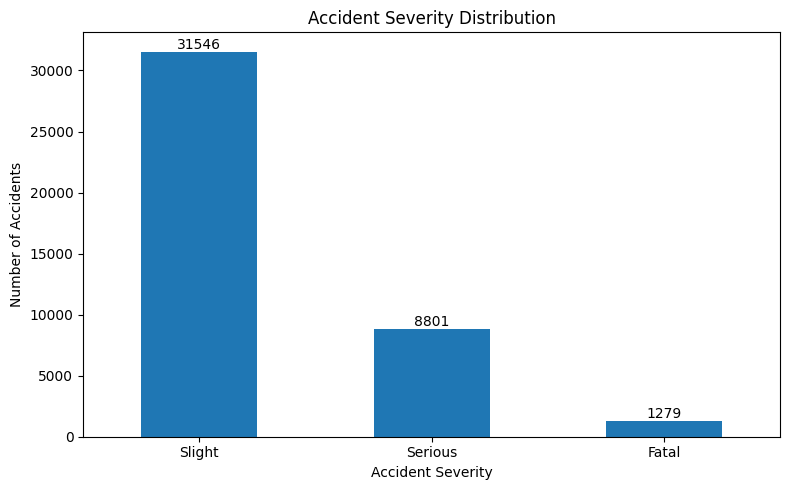

In [8]:
severity_counts = (
    train_df["HUMRAT_TEUNA"]
    .map(VALUE_LABELS["HUMRAT_TEUNA"])
    .value_counts()
)

ax = severity_counts.plot(
    kind="bar",
    figsize=(8, 5)
)

ax.set_title("Accident Severity Distribution")
ax.set_xlabel("Accident Severity")
ax.set_ylabel("Number of Accidents")
ax.tick_params(axis="x", rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%d")

plt.tight_layout()
plt.show()

In [9]:
severity_distribution = pd.DataFrame({
    "count": severity_counts,
    "percentage": severity_counts / severity_counts.sum() * 100
})

severity_distribution.round(2)

,count,percentage
HUMRAT_TEUNA,,
Slight,31546,75.78
Serious,8801,21.14
Fatal,1279,3.07


The target is imbalanced, with slight accidents representing the majority of cases.
Fatal accidents account for only 3.07% of the dataset, so accuracy alone will not be
a sufficient evaluation metric. Macro F1 and per-class precision/recall will be used.

### SUG_TEUNA (Accident Type)


The distribution of accident types is examined first.

In [10]:
feature_summary(train_df, "SUG_TEUNA")

,count,subset_percentage,fatal_rate,serious_rate,slight_rate,severe_rate
feature,,,,,,
Fall from moving vehicle,183,0.44,4.92,68.31,26.78,73.22
Collision with animal,26,0.06,11.54,61.54,26.92,73.08
Injury to passenger inside vehicle,347,0.83,1.15,59.94,38.90,61.10
Skidding,1073,2.58,5.13,54.80,40.07,59.93
Fire,2,0.00,0.00,50.00,50.00,50.00
"Collision with stopped vehicle, not parked",44,0.11,0.00,47.73,52.27,47.73
Leaving roadway or mounting sidewalk,227,0.55,10.57,35.68,53.74,46.26
Rollover,1053,2.53,7.12,36.18,56.70,43.30
Other,533,1.28,2.25,36.02,61.73,38.27


Front-to-side collisions and collisions with pedestrians together account for approximately 61% of accidents.

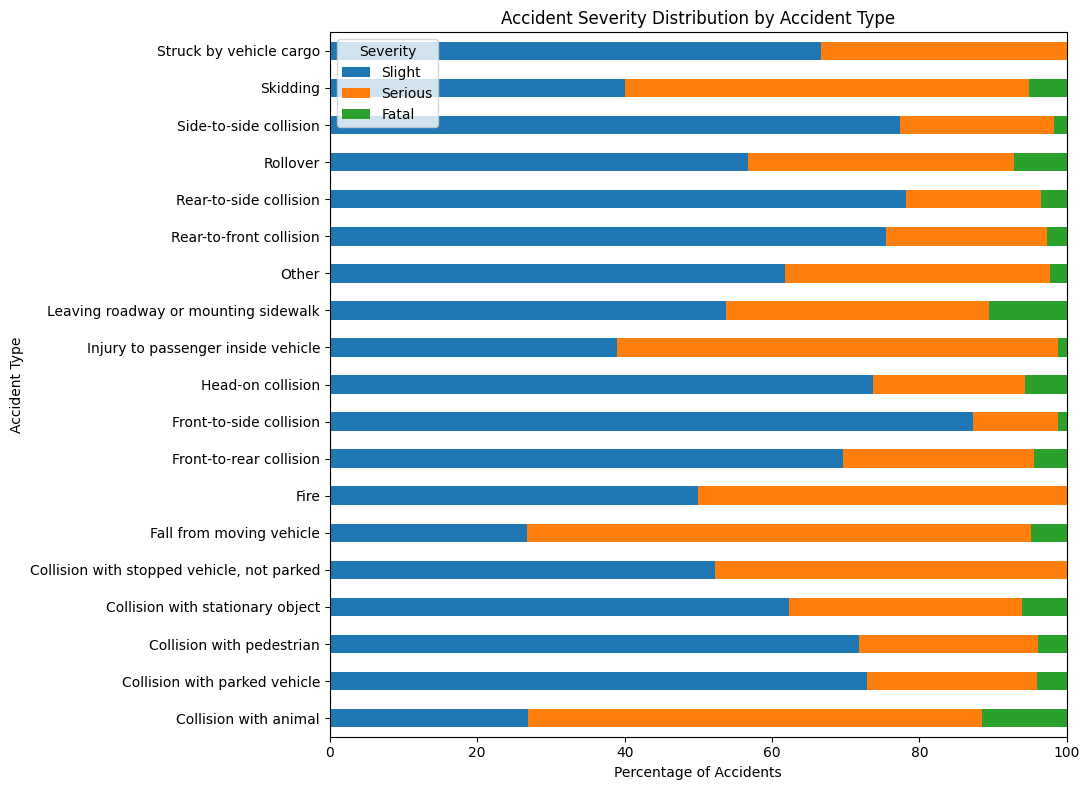

In [11]:
analysis_df = train_df.assign(
    accident_type=train_df["SUG_TEUNA"].map(VALUE_LABELS["SUG_TEUNA"]),
    severity=train_df["HUMRAT_TEUNA"].map(VALUE_LABELS["HUMRAT_TEUNA"])
)

severity_by_type = (
    pd.crosstab(
        analysis_df["accident_type"],
        analysis_df["severity"],
        normalize="index"
    ) * 100
)

severity_by_type = severity_by_type[
    ["Slight", "Serious", "Fatal"]
]

severity_by_type.plot(
    kind="barh",
    stacked=True,
    figsize=(11, 8)
)

plt.title("Accident Severity Distribution by Accident Type")
plt.xlabel("Percentage of Accidents")
plt.ylabel("Accident Type")
plt.legend(title="Severity")

plt.tight_layout()
plt.show()

The following table summarizes the relationship between accident type and accident severity.

For each accident type, the table reports:
- accident_type
- count: number of accidents in the category
- fatal_rate: percentage classified as Fatal
- serious_rate: percentage classified as Serious
- slight_rate: percentage classified as Slight
- severe_rate: combined percentage of Fatal and Serious accidents

In [12]:
type_counts = pd.crosstab(
    analysis_df["accident_type"],
    analysis_df["severity"]
).reindex(columns=["Slight", "Serious", "Fatal"], fill_value=0)

type_summary = type_counts.copy()
type_summary["count"] = type_counts.sum(axis=1)

# Percentage of all dataset rows belonging to each accident type
type_summary["type_percentage"] = (
    type_summary["count"] / len(analysis_df) * 100
)

for severity in ["fatal", "serious", "slight"]:
    type_summary[f"{severity}_rate"] = (
        type_counts[severity.capitalize()]
        / type_summary["count"]
        * 100
    )

type_summary["severe_rate"] = (
    type_summary["fatal_rate"]
    + type_summary["serious_rate"]
)

type_summary = type_summary[
    [
        "count",
        "type_percentage",
        "fatal_rate",
        "serious_rate",
        "slight_rate",
        "severe_rate",
    ]
]

type_summary.sort_values(
    "severe_rate",
    ascending=False
).round(2)

severity,count,type_percentage,fatal_rate,serious_rate,slight_rate,severe_rate
accident_type,,,,,,
Fall from moving vehicle,183,0.44,4.92,68.31,26.78,73.22
Collision with animal,26,0.06,11.54,61.54,26.92,73.08
Injury to passenger inside vehicle,347,0.83,1.15,59.94,38.90,61.10
Skidding,1073,2.58,5.13,54.80,40.07,59.93
Fire,2,0.00,0.00,50.00,50.00,50.00
"Collision with stopped vehicle, not parked",44,0.11,0.00,47.73,52.27,47.73
Leaving roadway or mounting sidewalk,227,0.55,10.57,35.68,53.74,46.26
Rollover,1053,2.53,7.12,36.18,56.70,43.30
Other,533,1.28,2.25,36.02,61.73,38.27


Accident type shows a strong association with accident severity.

Some insights from this table:
- Collisions with animals have a high observed severe accident rate, but they represent only approximately 0.06% of the dataset, so the estimate is based on a very small sample.
- Falls from moving vehicles also show a relatively high severe accident rate, based on 183 observations.
- Front-to-side collision, Rear-to-side collision, Side-to-side collision and Rear-to-front collision are associated with relatively high proportions of Slight accidents

### MEHIRUT_MUTERET (Permitted Speed)


In [13]:
feature_summary(train_df, "MEHIRUT_MUTERET")

,count,subset_percentage,fatal_rate,serious_rate,slight_rate,severe_rate
feature,,,,,,
Unknown,4257,10.23,0.52,61.03,38.45,61.55
110 km/h,243,0.58,10.70,31.28,58.02,41.98
120 km/h,116,0.28,12.07,27.59,60.34,39.66
100 km/h,320,0.77,9.06,27.81,63.12,36.88
90 km/h,3831,9.20,6.37,20.26,73.38,26.62
80 km/h,4340,10.43,6.22,18.96,74.82,25.18
70 km/h,2314,5.56,4.41,17.50,78.09,21.91
60 km/h,1670,4.01,3.65,15.93,80.42,19.58
Up to 50 km/h,24535,58.94,2.08,15.23,82.69,17.31


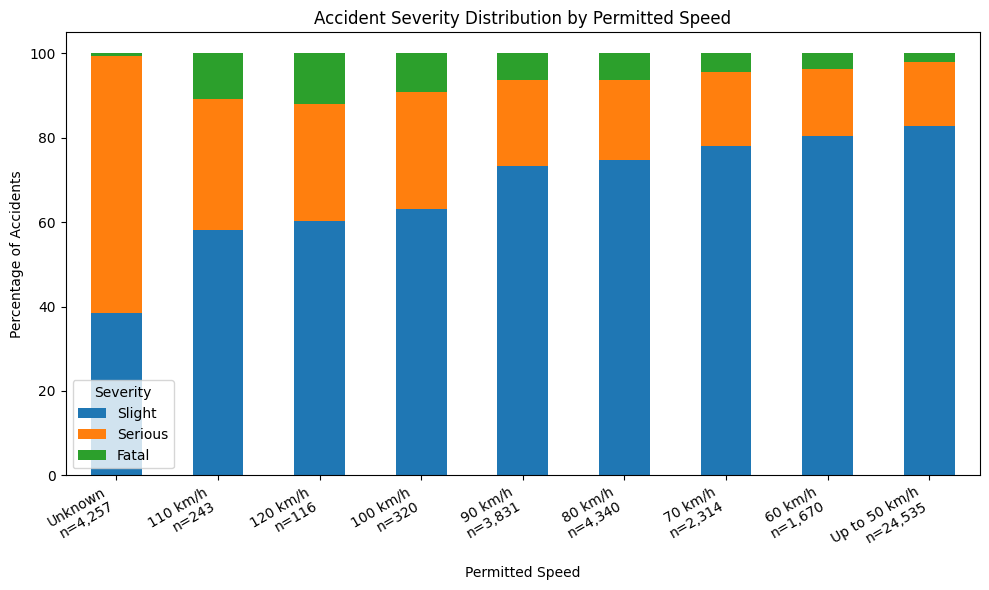

In [14]:
plot_severity_by_feature(
    train_df,
    "MEHIRUT_MUTERET",
    "Permitted Speed"
)

#### Observations

Permitted speed appears to have a clear relationship with accident severity.

In general, higher permitted speeds are associated with a higher proportion of serious and fatal accidents. For example, the severe accident rate increases from approximately 17% for roads with a permitted speed of up to 50 km/h to approximately 42% for roads with a permitted speed of 110 km/h.

The `Unknown` category behaves very differently from the other categories, with a particularly high serious accident rate. This may indicate that `Unknown` is not missing at random and should be investigated before preprocessing.

### SUG_DEREH (Road Type)


In [15]:
feature_summary(train_df, "SUG_DEREH")

,count,subset_percentage,fatal_rate,serious_rate,slight_rate,severe_rate
feature,,,,,,
"Non-urban, not at intersection",8341,20.04,7.36,28.11,64.52,35.48
"Urban, not at intersection",14544,34.94,2.42,27.00,70.58,29.42
"Non-urban, at intersection",5284,12.69,2.21,15.75,82.04,17.96
"Urban, at intersection",13457,32.33,1.46,12.61,85.93,14.07


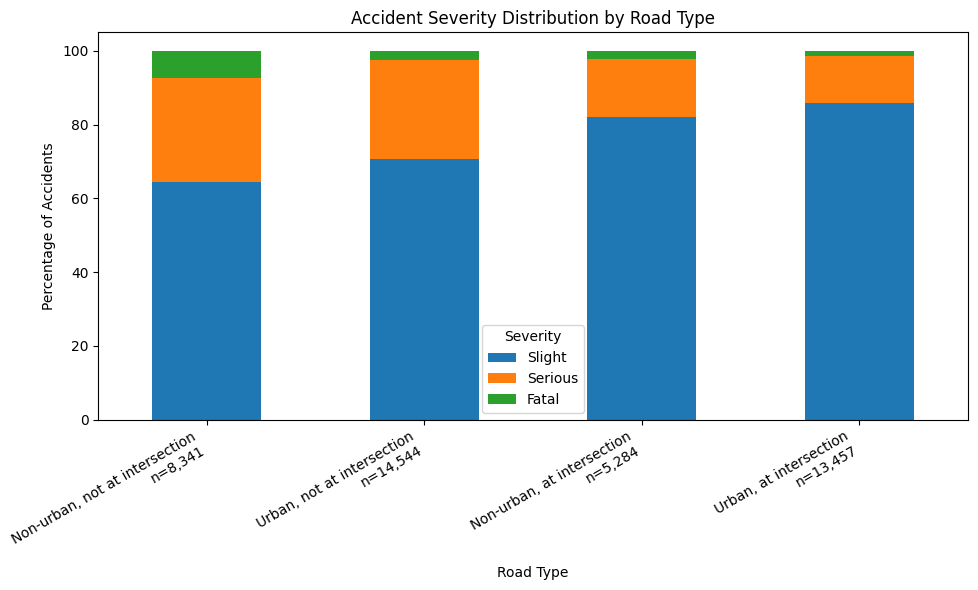

In [16]:
plot_severity_by_feature(
    train_df,
    "SUG_DEREH",
    "Road Type"
)

#### Observations

Road type shows a clear relationship with accident severity.

Non-urban roads have substantially higher serious and fatal accident rates than urban roads.

In addition, accidents that occur away from intersections tend to be more severe than accidents at intersections, both in urban and non-urban areas.

This suggests that `SUG_DEREH` may be an informative feature for severity prediction.

`SUG_DEREH` also combines two concepts, urban status and intersection status. Two derived representations, `ROAD_IS_URBAN` and `ROAD_IS_INTERSECTION`, are therefore evaluated separately.

In [17]:
road_type = train_df["SUG_DEREH"].map(
    VALUE_LABELS["SUG_DEREH"]
)

train_df["ROAD_IS_URBAN"] = road_type.isin([
    "Urban, at intersection",
    "Urban, not at intersection"
])

train_df["ROAD_IS_INTERSECTION"] = road_type.isin([
    "Urban, at intersection",
    "Non-urban, at intersection"
])

In [18]:
def summarize_boolean_feature(
    df,
    feature,
    true_label="True",
    false_label="False"
):
    display_values = df[feature].map({
        True: true_label,
        False: false_label
    })

    severity = df["HUMRAT_TEUNA"].map(
        VALUE_LABELS["HUMRAT_TEUNA"]
    )

    analysis_df = pd.DataFrame({
        feature: display_values,
        "severity": severity
    })

    summary = (
        analysis_df
        .groupby(feature)
        .agg(
            count=("severity", "size"),
            fatal_rate=("severity", lambda x: (x == "Fatal").mean() * 100),
            serious_rate=("severity", lambda x: (x == "Serious").mean() * 100),
            slight_rate=("severity", lambda x: (x == "Slight").mean() * 100),
        )
    )

    summary["severe_rate"] = (
        summary["fatal_rate"]
        + summary["serious_rate"]
    )

    return summary.round(2)

In [19]:
urban_summary = summarize_boolean_feature(
    train_df,
    "ROAD_IS_URBAN",
    true_label="Urban",
    false_label="Non-urban"
)

urban_summary

,count,fatal_rate,serious_rate,slight_rate,severe_rate
ROAD_IS_URBAN,,,,,
Non-urban,13625,5.37,23.32,71.32,28.68
Urban,28001,1.96,20.08,77.96,22.04


In [20]:
intersection_summary = summarize_boolean_feature(
    train_df,
    "ROAD_IS_INTERSECTION",
    true_label="At intersection",
    false_label="Not at intersection"
)

intersection_summary

,count,fatal_rate,serious_rate,slight_rate,severe_rate
ROAD_IS_INTERSECTION,,,,,
At intersection,18741,1.67,13.49,84.84,15.16
Not at intersection,22885,4.22,27.41,68.37,31.63


In [21]:
def plot_boolean_feature_severity(
    df,
    feature,
    true_label="True",
    false_label="False",
    title=None
):
    display_values = df[feature].map({
        True: true_label,
        False: false_label
    })

    severity = df["HUMRAT_TEUNA"].map(
        VALUE_LABELS["HUMRAT_TEUNA"]
    )

    severity_distribution = (
        pd.crosstab(
            display_values,
            severity,
            normalize="index"
        ) * 100
    )

    severity_distribution = severity_distribution[
        ["Slight", "Serious", "Fatal"]
    ]

    severity_distribution.plot(
        kind="bar",
        stacked=True,
        figsize=(8, 5)
    )

    plt.title(title or feature)
    plt.xlabel("")
    plt.ylabel("Percentage of Accidents")
    plt.xticks(rotation=0)

    plt.tight_layout()
    plt.show()

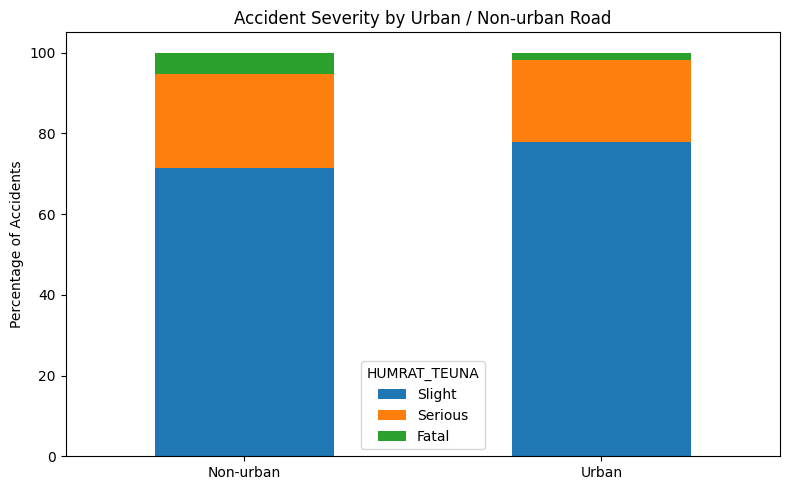

In [22]:
plot_boolean_feature_severity(
    train_df,
    "ROAD_IS_URBAN",
    true_label="Urban",
    false_label="Non-urban",
    title="Accident Severity by Urban / Non-urban Road"
)

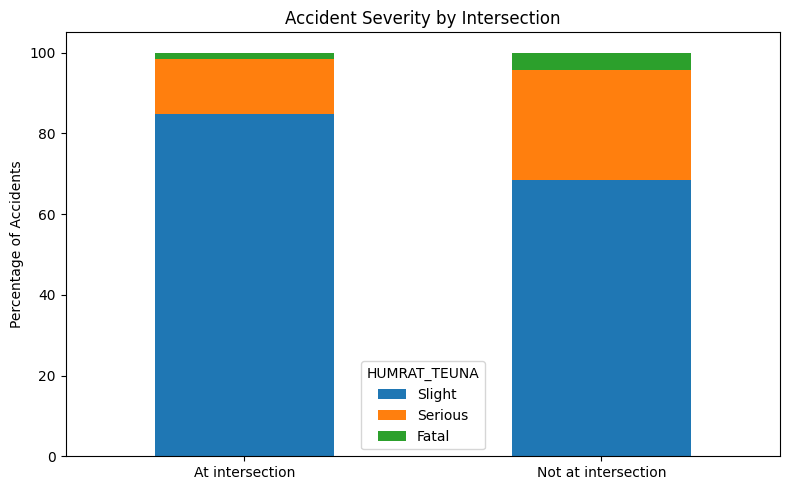

In [23]:
plot_boolean_feature_severity(
    train_df,
    "ROAD_IS_INTERSECTION",
    true_label="At intersection",
    false_label="Not at intersection",
    title="Accident Severity by Intersection"
)

#### Split to new features Observations

Splitting `SUG_DEREH` into two binary features reveals two separate relationships with accident severity.

- Non-urban roads have a substantially higher proportion of serious and fatal accidents than urban roads.
- Accidents occurring outside intersections also tend to be much more severe than accidents at intersections.

The urban/non-urban distinction appears to have a stronger relationship with severity than the intersection distinction.

Both derived features will be kept for modeling.

### HAD_MASLUL (Single-Carriageway Configuration)
Value `0` is excluded from the category comparison because it represents `Not applicable, see RAV_MASLUL`, rather than a carriageway category.

In [24]:
feature_summary(
    train_df,
    "HAD_MASLUL",
    exclude_values=[0]
)

,count,subset_percentage,fatal_rate,serious_rate,slight_rate,severe_rate
feature,,,,,,
Number of carriageways unknown,4224,15.69,0.47,61.25,38.28,61.72
Two-way with continuous dividing line,3117,11.58,5.65,20.08,74.27,25.73
Two-way without continuous dividing line,12977,48.21,3.06,16.65,80.29,19.71
One-way,6597,24.51,2.43,16.54,81.04,18.96


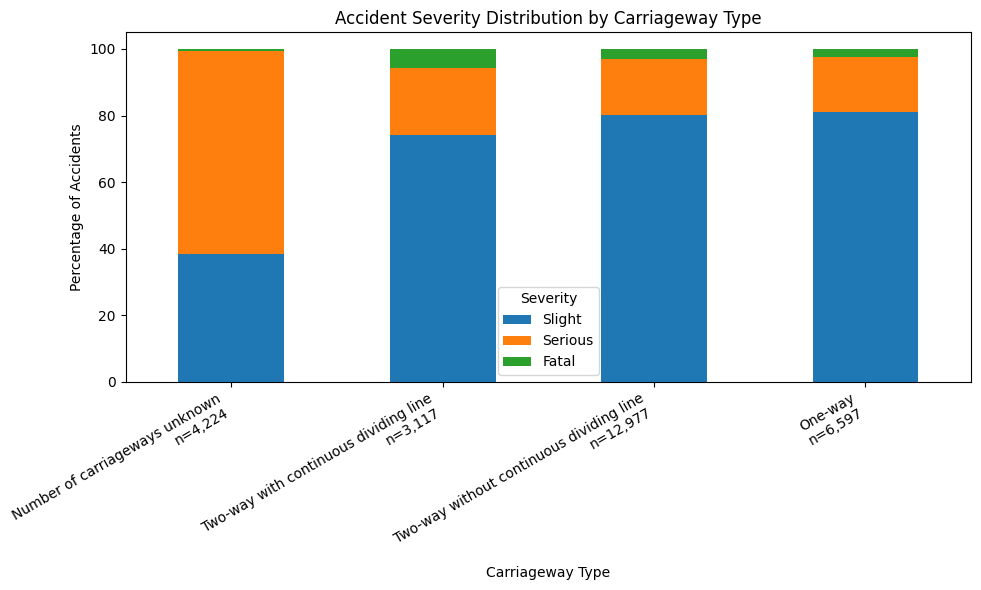

In [25]:
plot_severity_by_feature(
    train_df,
    "HAD_MASLUL",
    "Carriageway Type",
    exclude_values=[0]
)

#### `HAD_MASLUL` - Observations

According to the CBS codebook, `HAD_MASLUL` and `RAV_MASLUL` are complementary
fields describing the carriageway configuration.

When `HAD_MASLUL` contains the applicable road configuration, `RAV_MASLUL`
is set to `0`. When `RAV_MASLUL` contains the applicable configuration,
`HAD_MASLUL` is set to `0`.

Therefore, the 14,711 records with `HAD_MASLUL = 0` are not missing values
and should not be interpreted as a separate carriageway category. Their
road configuration is described by `RAV_MASLUL`.

Among the applicable `HAD_MASLUL` categories, two-way roads with a continuous
dividing line show a higher serious/fatal accident rate than one-way roads
and two-way roads without a continuous dividing line.

The `Unknown` category is substantially different, with approximately 62%
of accidents classified as serious or fatal. This category should be
preserved and investigated separately.

The next step is to analyze `RAV_MASLUL` and then determine whether the two
fields should be combined into a single carriageway feature.

### RAV_MASLUL

Value `0` is excluded because it represents `Not applicable, see HAD_MASLUL`.

In [26]:
feature_summary(
    train_df,
    "RAV_MASLUL",
    exclude_values=[0]
)

,count,subset_percentage,fatal_rate,serious_rate,slight_rate,severe_rate
feature,,,,,,
Median with safety barrier,4290,29.16,5.71,19.42,74.87,25.13
Unbuilt median,298,2.03,3.02,18.12,78.86,21.14
Other,720,4.89,2.64,15.28,82.08,17.92
Built median without safety barrier,8391,57.04,2.76,14.29,82.95,17.05
Median marked with paint,1012,6.88,2.08,13.83,84.09,15.91


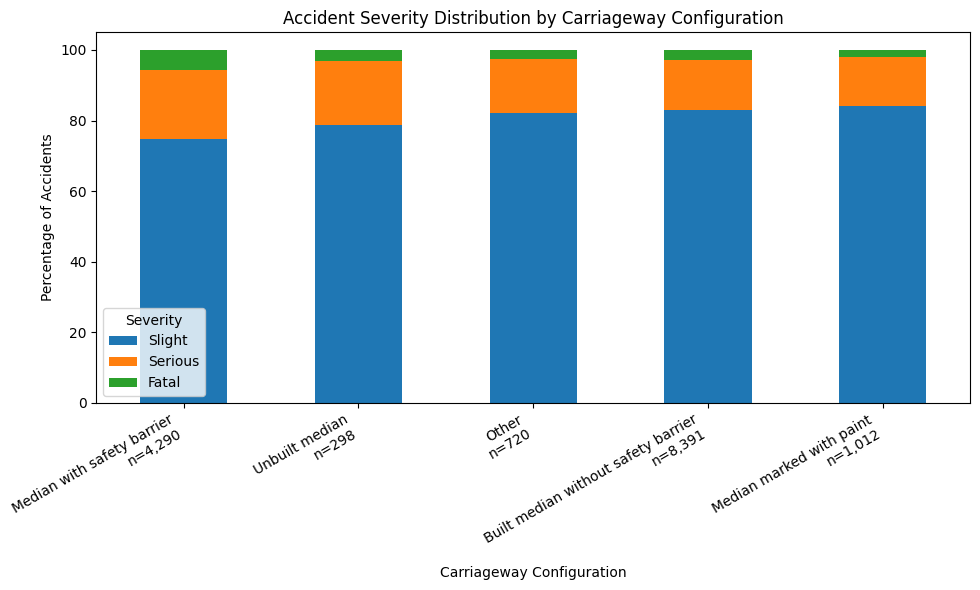

In [27]:
plot_severity_by_feature(
    train_df,
    "RAV_MASLUL",
    "Carriageway Configuration",
    exclude_values=[0]
)

#### `RAV_MASLUL` - Observations

The multi-carriageway configuration shows differences in accident severity.

Roads with a median safety barrier have the highest serious/fatal accident rate,
at approximately 25%, compared with approximately 17% for built medians without
a safety barrier and 16% for medians marked with paint.

This should not be interpreted as evidence that safety barriers increase accident
severity. The result may be influenced by other road characteristics, such as
permitted speed and whether the road is urban or non-urban.

The `Unbuilt median` category also shows a relatively high severe accident rate,
but contains only 298 observations, so the result should be interpreted cautiously.

### `HAD_MASLUL` and `RAV_MASLUL` - Feature Engineering

`HAD_MASLUL` and `RAV_MASLUL` are complementary fields that together describe the road carriageway configuration.

During feature engineering, they will be combined into two derived features:

- `ROAD_CARRIAGEWAY`: Single / Multi / Unknown
- `ROAD_CARRIAGEWAY_TYPE`: Detailed carriageway configuration

The original fields are kept unchanged during EDA.

During the feature engineering and modeling stages, the derived representation will be evaluated and a decision will be made whether the original `HAD_MASLUL` and `RAV_MASLUL` fields should also be included in the model.

In [28]:
def get_carriageway_type(row):
    if row["HAD_MASLUL"] != 0:
        label = VALUE_LABELS["HAD_MASLUL"].get(row["HAD_MASLUL"])

        if label == "Number of carriageways unknown":
            return "Unknown"

        return f"Single: {label}"

    if row["RAV_MASLUL"] != 0:
        label = VALUE_LABELS["RAV_MASLUL"].get(row["RAV_MASLUL"])
        return f"Multi: {label}"

    return "Unknown"


train_df["ROAD_CARRIAGEWAY_TYPE"] = train_df.apply(
    get_carriageway_type,
    axis=1
)

train_df["ROAD_CARRIAGEWAY_TYPE"].value_counts(dropna=False)

ROAD_CARRIAGEWAY_TYPE
Single: Two-way without continuous dividing line    12977
Multi: Built median without safety barrier           8391
Single: One-way                                      6597
Multi: Median with safety barrier                    4290
Unknown                                              4224
Single: Two-way with continuous dividing line        3117
Multi: Median marked with paint                      1012
Multi: Other                                          720
Multi: Unbuilt median                                 298
Name: count, dtype: int64

In [29]:
def get_road_carriageway(row):
    if row["HAD_MASLUL"] in [1, 2, 3, 4]:
        return "Single"

    if row["RAV_MASLUL"] in [1, 2, 3, 4, 5]:
        return "Multi"

    return "Unknown"

train_df["ROAD_CARRIAGEWAY"] = train_df.apply(
    get_road_carriageway,
    axis=1
)

train_df["ROAD_CARRIAGEWAY"].value_counts()

ROAD_CARRIAGEWAY
Single     22691
Multi      14711
Unknown     4224
Name: count, dtype: int64

### ROHAV (Road Width)


In [30]:
feature_summary(
    train_df,
    "ROHAV"
)

,count,subset_percentage,fatal_rate,serious_rate,slight_rate,severe_rate
feature,,,,,,
Unknown,5610,13.48,0.78,50.27,48.95,51.05
Over 14 m,2399,5.76,5.50,18.13,76.37,23.63
10.5 to 14 m,4756,11.43,4.48,17.01,78.51,21.49
7 to 10.5 m,14060,33.78,3.78,16.71,79.51,20.49
Up to 5 m,2936,7.05,2.21,16.86,80.93,19.07
5 to 7 m,11865,28.50,2.47,15.95,81.58,18.42


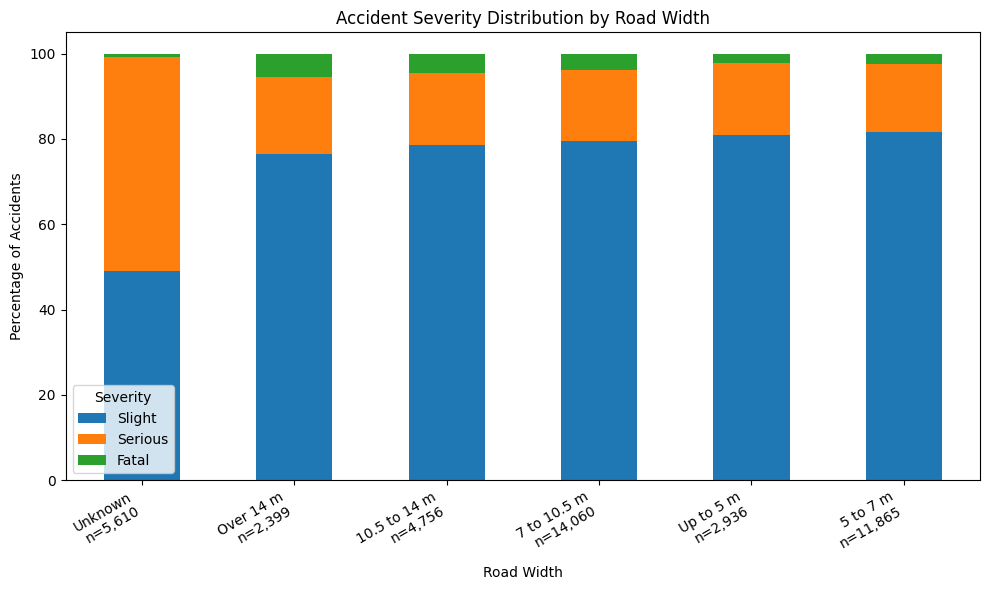

In [31]:
plot_severity_by_feature(
    train_df,
    "ROHAV",
    "Road Width"
)

#### Observations

Road width shows a moderate relationship with accident severity.

In general, wider roads tend to have a somewhat higher proportion of serious and fatal accidents. The severe accident rate increases from approximately 18-19% for narrower roads to approximately 24% for roads wider than 14 meters.

The relationship is present, but it is weaker than the patterns observed for road type and permitted speed.

Wider roads appear to be associated with higher accident severity. One possible explanation is that wider roads may also be associated with higher permitted speeds, which could contribute to more severe outcomes. 
This hypothesis is examined by comparing road width with permitted speed.

The `Unknown` category is substantially different, with approximately 51% of accidents classified as serious or fatal. This is consistent with the broader pattern previously observed in other road-related fields, where unknown values tend to occur together and are associated with a distinct subset of accidents.

In [32]:
road_width_speed = pd.crosstab(
    train_df["ROHAV"].map(VALUE_LABELS["ROHAV"]),
    train_df["MEHIRUT_MUTERET"].map(VALUE_LABELS["MEHIRUT_MUTERET"]),
    normalize="index"
) * 100

road_width_speed.round(2)

MEHIRUT_MUTERET,100 km/h,110 km/h,120 km/h,60 km/h,70 km/h,80 km/h,90 km/h,Unknown,Up to 50 km/h
ROHAV,,,,,,,,,
10.5 to 14 m,2.48,1.16,0.76,5.11,11.23,15.39,22.25,0.02,41.61
5 to 7 m,0.30,0.18,0.08,3.31,3.26,6.33,3.08,0.13,83.33
7 to 10.5 m,0.63,0.63,0.14,5.77,7.16,16.74,11.47,0.11,57.35
Over 14 m,2.83,2.88,1.83,4.38,11.17,13.42,25.89,0.08,37.52
Unknown,0.14,0.12,0.12,0.78,1.07,1.76,2.09,75.20,18.70
Up to 5 m,0.07,0.07,0.03,2.52,1.98,2.79,1.98,0.10,90.46


In [33]:
analysis_df = train_df.assign(
    road_width=train_df["ROHAV"].map(VALUE_LABELS["ROHAV"]),
    permitted_speed=train_df["MEHIRUT_MUTERET"].map(
        VALUE_LABELS["MEHIRUT_MUTERET"]
    ),
    severity=train_df["HUMRAT_TEUNA"].map(
        VALUE_LABELS["HUMRAT_TEUNA"]
    )
)

severity_by_width_and_speed = (
    analysis_df
    .groupby(["permitted_speed", "road_width"])
    .agg(
        count=("severity", "size"),
        severe_rate=(
            "severity",
            lambda x: x.isin(["Serious", "Fatal"]).mean() * 100
        )
    )
    .reset_index()
)

severity_by_width_and_speed

,permitted_speed,road_width,count,severe_rate
0,100 km/h,10.5 to 14 m,118,34.745763
1,100 km/h,5 to 7 m,36,19.444444
2,100 km/h,7 to 10.5 m,88,31.818182
3,100 km/h,Over 14 m,68,58.823529
4,100 km/h,Unknown,8,25.000000
5,100 km/h,Up to 5 m,2,0.000000
6,110 km/h,10.5 to 14 m,55,41.818182
7,110 km/h,5 to 7 m,21,14.285714
8,110 km/h,7 to 10.5 m,89,39.325843
9,110 km/h,Over 14 m,69,49.275362


#### Additional Observation

Road width is strongly associated with permitted speed.

Narrower roads are predominantly associated with speed limits of up to 50 km/h, while wider roads have a much larger proportion of 80, 90, 100 and 110 km/h speed limits.

This supports the hypothesis that part of the relationship previously observed between road width and accident severity may be explained by the association between wider roads and higher permitted speeds.

When road width was compared within the same permitted-speed category, the relationship with severity became considerably less consistent.

### TKINUT

In [34]:
feature_summary(train_df, "TKINUT")

,count,subset_percentage,fatal_rate,serious_rate,slight_rate,severe_rate
feature,,,,,,
Poor shoulders and damaged road surface,51,0.12,7.84,45.10,47.06,52.94
Unknown,6268,15.06,1.26,46.12,52.62,47.38
Poor shoulders,111,0.27,9.91,27.03,63.06,36.94
Damaged road surface,402,0.97,6.72,26.62,66.67,33.33
No defect,34794,83.59,3.33,16.53,80.15,19.85


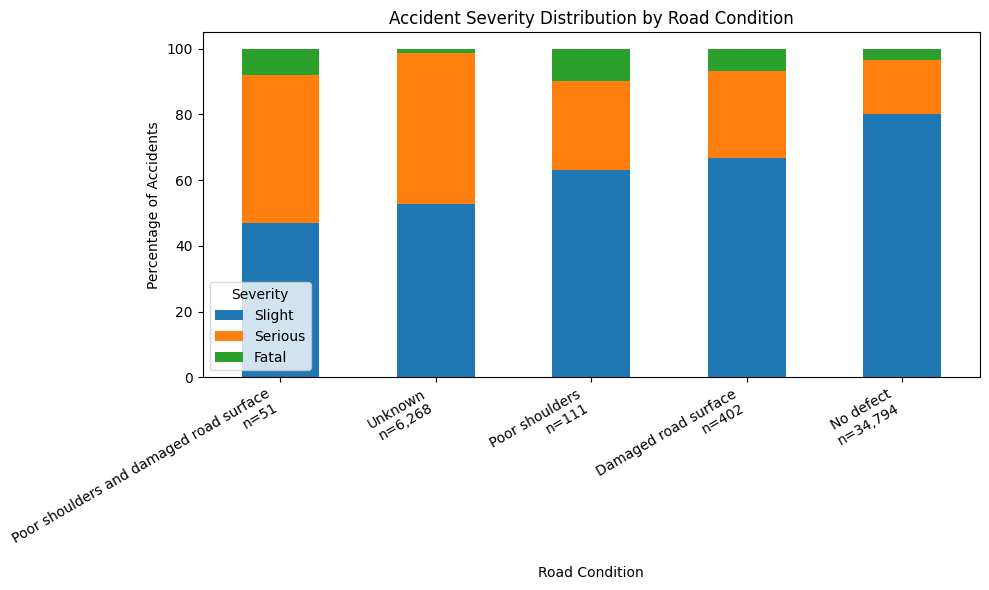

In [35]:
plot_severity_by_feature(
    train_df,
    "TKINUT",
    "Road Condition"
)

#### Observations

Road condition appears to be associated with accident severity.

Accidents recorded on roads with no reported defects have a severe accident rate of approximately 20%, while categories representing road defects show higher severe accident rates.

However, the defect categories contain relatively few observations, especially `Poor shoulders` and `Poor shoulders and damaged road surface`, so their severity rates should be interpreted cautiously.

The `Unknown` category again shows a substantially higher severe accident rate.
This is consistent with the pattern observed in other road-related features, where unknown values appear to represent a distinct subset of accidents rather than random missing information.

Because the individual defect categories are sparse, a lower-cardinality derived feature, `ROAD_DEFECT`, will be evaluated. It combines all defect categories into a single `Defect` category, while keeping `No defect` and `Unknown` as separate categories.

In [36]:
train_df["ROAD_DEFECT"] = (
    train_df["TKINUT"]
    .map(VALUE_LABELS["TKINUT"])
    .map(lambda x:
        "Unknown" if x == "Unknown"
        else "No defect" if x == "No defect"
        else "Defect"
    )
)

train_df["ROAD_DEFECT"].value_counts(dropna=False)

ROAD_DEFECT
No defect    34794
Unknown       6268
Defect         564
Name: count, dtype: int64

In [37]:
road_defect_summary = (
    train_df.assign(
        severity=train_df["HUMRAT_TEUNA"].map(
            VALUE_LABELS["HUMRAT_TEUNA"]
        )
    )
    .groupby("ROAD_DEFECT")
    .agg(
        count=("severity", "size"),
        fatal_rate=("severity", lambda x: (x == "Fatal").mean() * 100),
        serious_rate=("severity", lambda x: (x == "Serious").mean() * 100),
        slight_rate=("severity", lambda x: (x == "Slight").mean() * 100),
    )
)

road_defect_summary["severe_rate"] = (
    road_defect_summary["fatal_rate"]
    + road_defect_summary["serious_rate"]
)

road_defect_summary.round(2)

,count,fatal_rate,serious_rate,slight_rate,severe_rate
ROAD_DEFECT,,,,,
Defect,564,7.45,28.37,64.18,35.82
No defect,34794,3.33,16.53,80.15,19.85
Unknown,6268,1.26,46.12,52.62,47.38


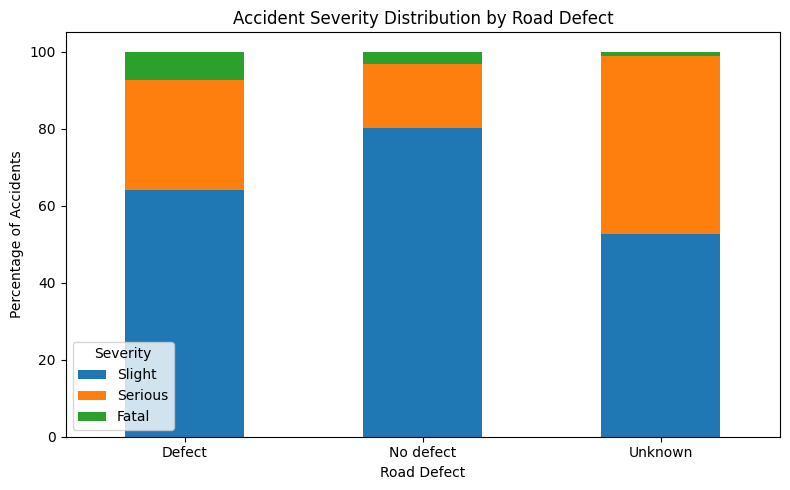

In [38]:
severity_by_road_defect = (
    pd.crosstab(
        train_df["ROAD_DEFECT"],
        train_df["HUMRAT_TEUNA"].map(
            VALUE_LABELS["HUMRAT_TEUNA"]
        ),
        normalize="index"
    ) * 100
)

severity_by_road_defect = severity_by_road_defect[
    ["Slight", "Serious", "Fatal"]
]

severity_by_road_defect.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)

plt.title("Accident Severity Distribution by Road Defect")
plt.xlabel("Road Defect")
plt.ylabel("Percentage of Accidents")
plt.xticks(rotation=0)
plt.legend(title="Severity")
plt.tight_layout()
plt.show()

The derived `ROAD_DEFECT` feature shows a clear difference in accident severity.

Accidents associated with a road defect have a severe accident rate of approximately 36%, compared with approximately 20% for roads with no reported defects.

This suggests that the presence of a road defect is associated with higher accident severity.

The `Unknown` category remains substantially different, with a severe accident rate of approximately 47%, consistent with the pattern observed in other road-related features.

### SIMUN_TIMRUR (Road Markings / Traffic Signs Condition)

In [39]:
feature_summary(
    train_df,
    "SIMUN_TIMRUR"
)

,count,subset_percentage,fatal_rate,serious_rate,slight_rate,severe_rate
feature,,,,,,
Unknown,5230,12.56,0.80,53.96,45.24,54.76
Traffic sign not required,2409,5.79,6.48,23.25,70.28,29.72
Road markings defective or missing,815,1.96,4.05,18.65,77.30,22.70
No defect,32739,78.65,3.19,15.89,80.92,19.08
Traffic signs defective or missing,433,1.04,1.15,15.01,83.83,16.17


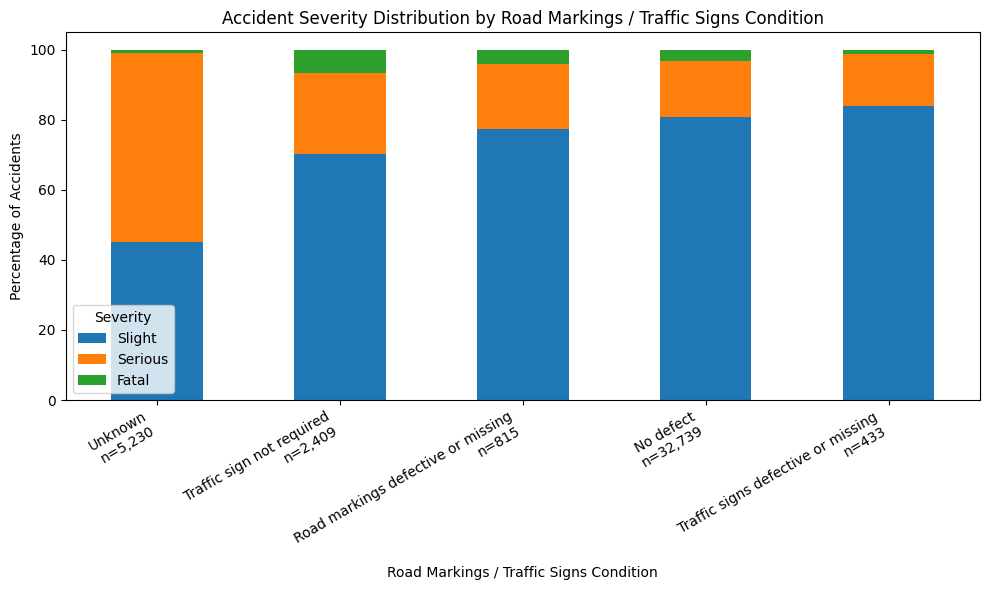

In [40]:
plot_severity_by_feature(
    train_df,
    "SIMUN_TIMRUR",
    "Road Markings / Traffic Signs Condition"
)

#### Observations

There is no substantial difference in accident severity between `No defect` and the categories representing defective or missing road markings and traffic signs.

When the two defect categories are considered together, their severe accident rate is close to that of the `No defect` category.

However, `Traffic sign not required` shows a higher severe accident rate, while the `Unknown` category again represents a substantially different group.

Therefore, there is currently no strong evidence that marking or traffic-sign defects themselves provide a meaningful severity signal.

`SIMUN_TIMRUR` will be kept for now and evaluated during modeling, where its additional predictive value can be assessed before deciding whether to remove it.

### TEURA (Lighting Conditions)

In [41]:
feature_summary(
    train_df,
    "TEURA"
)

,count,subset_percentage,fatal_rate,serious_rate,slight_rate,severe_rate
feature,,,,,,
"Night, defective lighting with limited visibility",22,0.05,22.73,40.91,36.36,63.64
"Day, unknown",3383,8.13,0.68,56.10,43.22,56.78
"Night, no lighting",617,1.48,13.13,31.60,55.27,44.73
Lighting exists but defective or not operating,321,0.77,11.21,24.61,64.17,35.83
"Night, unknown",3736,8.98,1.77,33.00,65.23,34.77
"Night, no lighting with limited visibility",16,0.04,12.50,12.50,75.00,25.00
Twilight,241,0.58,7.05,17.84,75.10,24.90
"Night, proper lighting with limited visibility",36,0.09,2.78,19.44,77.78,22.22
"Night, lighting operational",9282,22.30,4.22,17.09,78.69,21.31


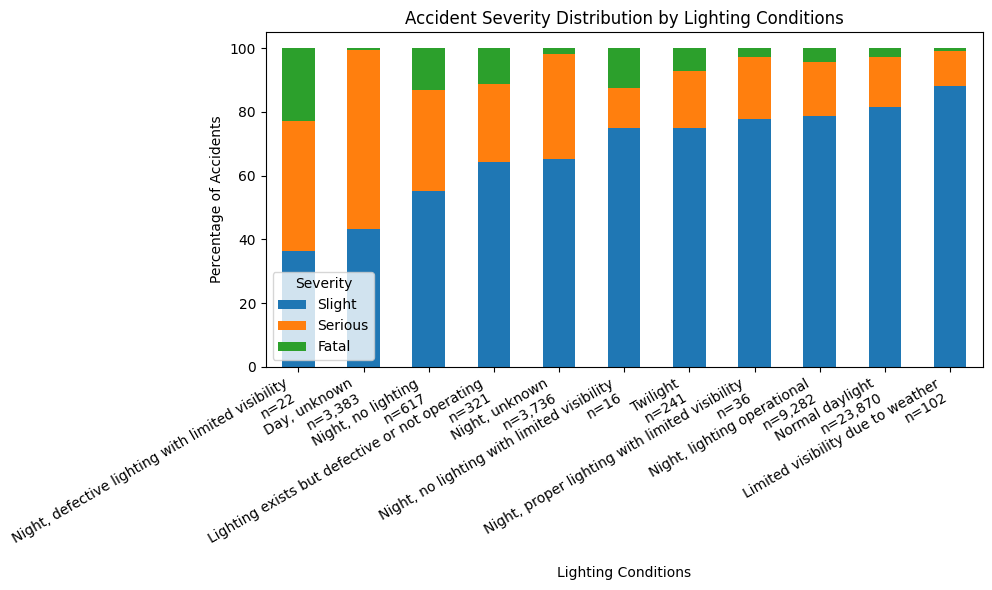

In [42]:
plot_severity_by_feature(
    train_df,
    "TEURA",
    "Lighting Conditions"
)

#### Observations

Lighting conditions appear to be associated with accident severity.

Accidents under normal lighting conditions show relatively lower severe accident rates:
- `Normal daylight`: approximately 18%
- `Night, lighting operational`: approximately 21%

Several categories representing problematic lighting or limited visibility show higher severe accident rates. However, some of these categories contain very few observations, so they should be interpreted cautiously.

The `Day, unknown` and `Night, unknown` categories again show substantially higher severe accident rates, consistent with the pattern observed in other road-related features.

Day/night information is already represented by `YOM_LAYLA`, so `TEURA` is instead evaluated as a representation of problematic lighting or visibility conditions.

In [43]:
def map_lighting_issue(value):
    label = VALUE_LABELS["TEURA"].get(value)

    if label in [
        "Day, unknown",
        "Night, unknown"
    ]:
        return "Unknown"

    if label in [
        "Lighting exists but defective or not operating",
        "Night, defective lighting with limited visibility",
        "Night, no lighting",
        "Night, no lighting with limited visibility",
        "Night, proper lighting with limited visibility",
        "Limited visibility due to weather",
    ]:
        return "Issue"

    return "No issue"


train_df["VISIBILITY_OR_LIGHTING_ISSUE"] = train_df["TEURA"].map(
    map_lighting_issue
)

In [44]:
feature_summary(
    train_df,
    "VISIBILITY_OR_LIGHTING_ISSUE"
)

,count,subset_percentage,fatal_rate,serious_rate,slight_rate,severe_rate
feature,,,,,,
Unknown,7119,17.10,1.25,43.98,54.77,45.23
Issue,1114,2.68,11.31,27.20,61.49,38.51
No issue,33393,80.22,3.19,16.07,80.74,19.26


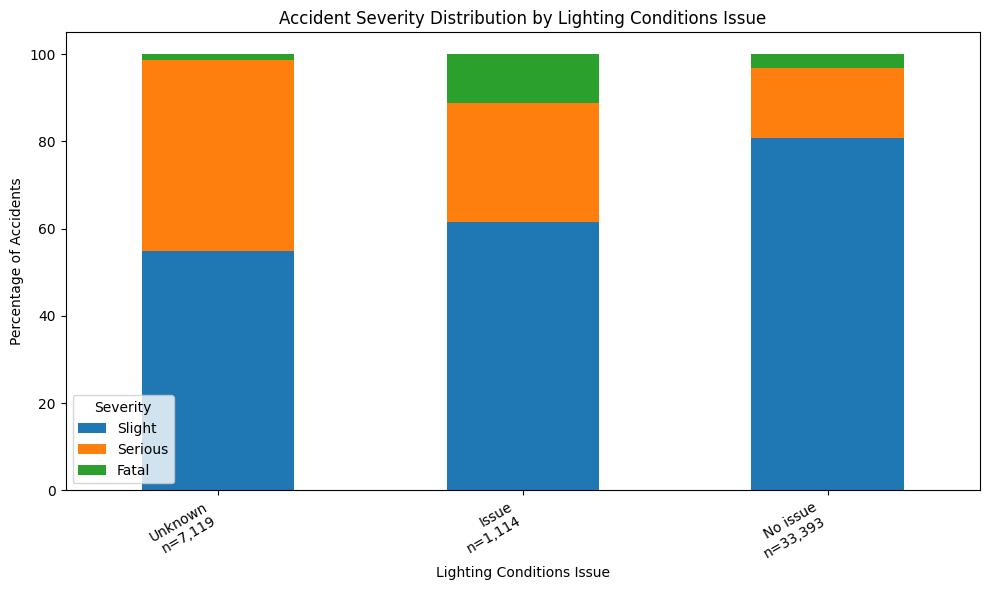

In [45]:
plot_severity_by_feature(
    train_df,
    "VISIBILITY_OR_LIGHTING_ISSUE",
    "Lighting Conditions Issue"
)

#### Feature Engineering Observations

The derived `VISIBILITY_OR_LIGHTING_ISSUE` feature shows a clear relationship with accident severity.

Accidents with a lighting or visibility issue have a severe accident rate of approximately 39%, compared with approximately 19% when no issue is reported.

The `Unknown` category remains substantially different, with a severe accident rate of approximately 45%.

This suggests that `VISIBILITY_OR_LIGHTING_ISSUE` may provide a useful predictive signal and will be considered as a candidate feature for the model.

### MEZEG_AVIR (Weather Conditions)

In [46]:
feature_summary(
    train_df,
    "MEZEG_AVIR"
)

,count,subset_percentage,fatal_rate,serious_rate,slight_rate,severe_rate
feature,,,,,,
Unknown,5215,12.53,0.94,53.37,45.70,54.30
Other,79,0.19,7.59,24.05,68.35,31.65
Foggy,38,0.09,5.26,21.05,73.68,26.32
Clear,34603,83.13,3.36,16.64,80.00,20.00
Hot and dry,148,0.36,2.70,16.89,80.41,19.59
Rainy,1543,3.71,3.69,13.42,82.89,17.11


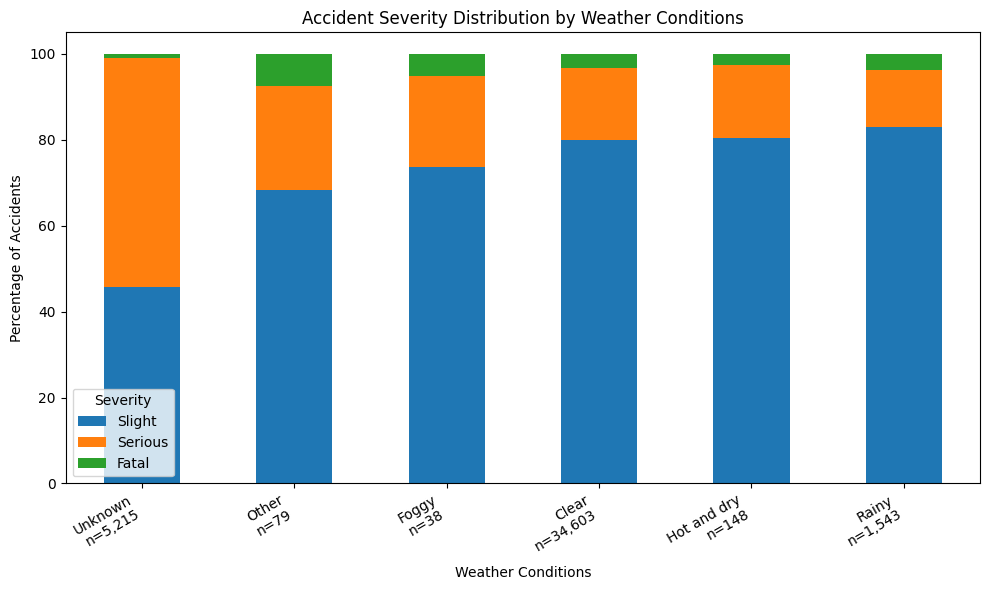

In [47]:
plot_severity_by_feature(
    train_df,
    "MEZEG_AVIR",
    "Weather Conditions"
)

#### Observations

After excluding `Unknown` and `Other`, weather conditions do not appear to have a strong relationship with accident severity.

`Clear`, `Hot and dry`, and `Rainy` conditions show relatively similar severe accident rates. `Foggy` conditions show a somewhat higher severe accident rate, but this category contains only 38 observations, so the result should be interpreted cautiously.

Most accidents, approximately 83%, occurred under clear weather conditions. `Unknown` and `Other` account for approximately 13% of the data, while adverse weather conditions such as rain and fog represent only a small proportion of the dataset.

The `Unknown` category again shows a substantially different severity distribution, consistent with the pattern observed in several other features.

Overall, `MEZEG_AVIR` appears to provide limited direct information about accident severity and will be kept for now, but considered a candidate for removal during modeling.

### PNE_KVISH (Road Surface Condition)

In [48]:
feature_summary(
    train_df,
    "PNE_KVISH"
)

,count,subset_percentage,fatal_rate,serious_rate,slight_rate,severe_rate
feature,,,,,,
Unknown,4519,10.86,0.53,58.93,40.54,59.46
Other,123,0.30,8.13,34.15,57.72,42.28
Covered with mud,23,0.06,13.04,26.09,60.87,39.13
Sand or gravel on road,180,0.43,4.44,22.78,72.78,27.22
Covered with fuel,19,0.05,5.26,21.05,73.68,26.32
Dry,34634,83.20,3.33,16.58,80.09,19.91
Wet,2128,5.11,3.76,14.29,81.95,18.05


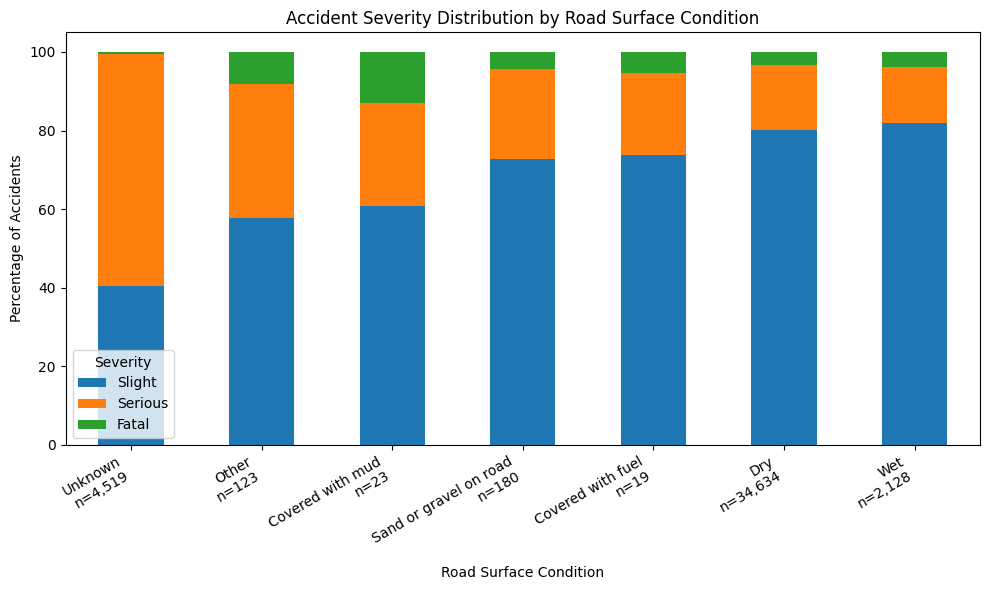

In [49]:
plot_severity_by_feature(
    train_df,
    "PNE_KVISH",
    "Road Surface Condition"
)

#### Observations

As in several other features, `Unknown` shows a substantially different severity distribution and will be treated separately.

Most accidents occurred on a dry road surface, approximately 83%, followed by wet road surfaces at approximately 5%. The remaining specific surface conditions are relatively rare.

There is little difference in accident severity between `Dry` and `Wet` road conditions, with severe accident rates of approximately 20% and 18%, respectively.

Some less common road-surface conditions, such as mud, sand or gravel, and fuel on the road, show higher severe accident rates. However, these categories contain relatively few observations when considered individually.

To reduce sparsity, a grouped road-surface representation will be evaluated, with the following categories:
- `Dry`
- `Wet`
- `Surface issue`
- `Other`
- `Unknown`

The `Surface issue` category will combine mud, sand or gravel, and fuel on the road.

In [50]:
def map_road_surface_condition(value):
    label = VALUE_LABELS["PNE_KVISH"].get(value)

    if label == "Unknown":
        return "Unknown"

    if label == "Dry":
        return "Dry"

    if label == "Wet":
        return "Wet"

    if label in [
        "Covered with mud",
        "Sand or gravel on road",
        "Covered with fuel",
    ]:
        return "Surface issue"

    return "Other"


train_df["ROAD_SURFACE_CONDITION"] = (
    train_df["PNE_KVISH"]
    .map(map_road_surface_condition)
)

In [51]:
train_df["ROAD_SURFACE_CONDITION"].value_counts(dropna=False)

ROAD_SURFACE_CONDITION
Dry              34634
Unknown           4519
Wet               2128
Surface issue      222
Other              123
Name: count, dtype: int64

In [52]:
feature_summary(
    train_df,
    "ROAD_SURFACE_CONDITION"
)

,count,subset_percentage,fatal_rate,serious_rate,slight_rate,severe_rate
feature,,,,,,
Unknown,4519,10.86,0.53,58.93,40.54,59.46
Other,123,0.30,8.13,34.15,57.72,42.28
Surface issue,222,0.53,5.41,22.97,71.62,28.38
Dry,34634,83.20,3.33,16.58,80.09,19.91
Wet,2128,5.11,3.76,14.29,81.95,18.05


#### Feature Engineering Observations

The derived `ROAD_SURFACE_CONDITION` feature provides a more compact and interpretable representation than the original `PNE_KVISH` feature.

The grouped `Surface issue` category has a severe accident rate of approximately 28%, compared with approximately 20% for `Dry` and 18% for `Wet`.

The `Unknown` and `Other` categories remain substantially different and are kept separate.

Overall, `ROAD_SURFACE_CONDITION` appears to preserve the meaningful signal in `PNE_KVISH` while reducing sparsity in the rare surface-condition categories.

This feature is therefore a good candidate to replace `PNE_KVISH` during the feature engineering and modeling stages.

### SUG_EZEM (Type of Stationary Object Struck)

In [53]:
stationary_object_df = train_df[
    train_df["SUG_TEUNA"] == 8
].copy()

feature_summary(stationary_object_df, "SUG_TEUNA")

,count,subset_percentage,fatal_rate,serious_rate,slight_rate,severe_rate
feature,,,,,,
Collision with stationary object,1795,100.0,6.07,31.59,62.34,37.66


In [54]:
feature_summary(
    train_df,
    "SUG_EZEM"
)

,count,subset_percentage,fatal_rate,serious_rate,slight_rate,severe_rate
feature,,,,,,
Other,436,1.05,11.24,28.67,60.09,39.91
Vehicle safety barrier,834,2.00,9.59,26.62,63.79,36.21
Tree,220,0.53,6.36,25.91,67.73,32.27
Structure,196,0.47,9.69,21.94,68.37,31.63
Utility pole,398,0.96,6.03,23.87,70.10,29.90
Traffic sign / signboard,241,0.58,4.15,19.92,75.93,24.07
Unknown,39286,94.38,2.75,20.90,76.35,23.65
Bridge and protective structures,9,0.02,11.11,0.00,88.89,11.11
Barrel,6,0.01,0.00,0.00,100.00,0.00


`SUG_EZEM` is documented as being relevant to accidents classified as `Collision with stationary object` (`SUG_TEUNA = 8`).

However, the dataset contains non-unknown `SUG_EZEM` values for several other accident types as well.

Approximately two thirds of the accidents with a recorded stationary object are classified as `Collision with stationary object`, while the remaining records are distributed across other accident types such as front-to-side collisions, rollovers, and head-on collisions.

Therefore, `SUG_EZEM` is analyzed wherever a recorded object type is available rather than being restricted to `SUG_TEUNA = 8`, while taking into account that the large `Unknown` group may include cases where this field is not applicable rather than truly unknown.

In [55]:
known_object_df = train_df[
    train_df["SUG_EZEM"].map(VALUE_LABELS["SUG_EZEM"]) != "Unknown"
].copy()

In [56]:
feature_summary(
    known_object_df,
    "SUG_EZEM"
)

,count,subset_percentage,fatal_rate,serious_rate,slight_rate,severe_rate
feature,,,,,,
Other,436,18.63,11.24,28.67,60.09,39.91
Vehicle safety barrier,834,35.64,9.59,26.62,63.79,36.21
Tree,220,9.40,6.36,25.91,67.73,32.27
Structure,196,8.38,9.69,21.94,68.37,31.63
Utility pole,398,17.01,6.03,23.87,70.10,29.90
Traffic sign / signboard,241,10.30,4.15,19.92,75.93,24.07
Bridge and protective structures,9,0.38,11.11,0.00,88.89,11.11
Barrel,6,0.26,0.00,0.00,100.00,0.00


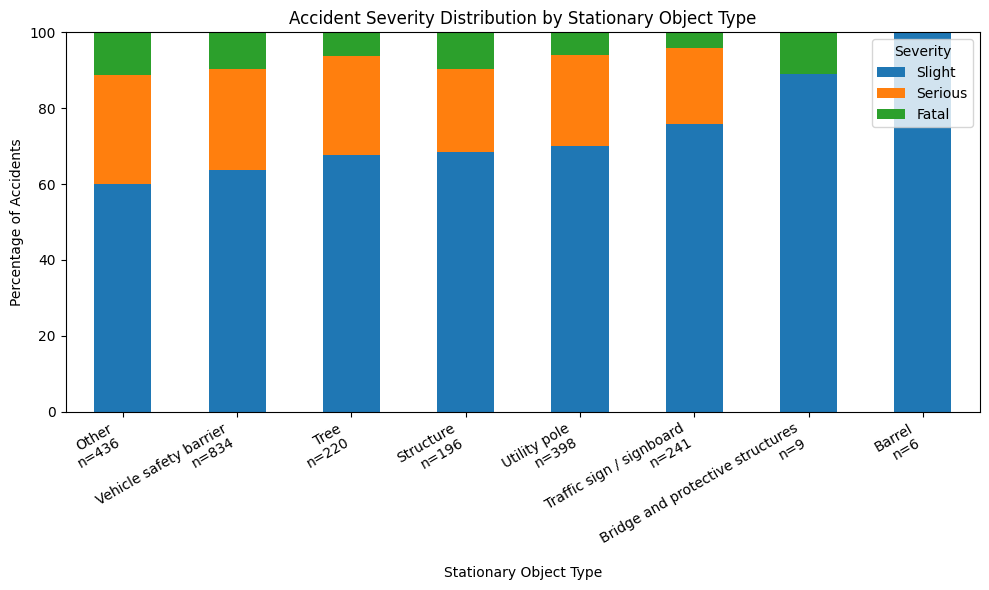

In [57]:
plot_severity_by_feature(
    known_object_df,
    "SUG_EZEM",
    "Stationary Object Type"
)

#### Observations

Among accidents where a stationary object is recorded, the type of object appears to be associated with accident severity.

`Other` and `Vehicle safety barrier` have the highest severe accident rates, at approximately 40% and 36%, respectively. `Tree`, `Structure`, and `Utility pole` also show relatively high severe accident rates.

`Traffic sign / signboard` has a lower severe accident rate of approximately 24%.

The `Bridge and protective structures` and `Barrel` categories contain very few observations, so their severity rates should not be interpreted as reliable patterns.

Overall, `SUG_EZEM` appears to contain useful information when an object is recorded.
However, since an object type is available for only a small fraction of all accidents, its final representation should be evaluated during feature engineering.

### MERHAK_EZEM (Distance of the stationary object from the road)

In [58]:
feature_summary(
    train_df,
    "MERHAK_EZEM"
)

,count,subset_percentage,fatal_rate,serious_rate,slight_rate,severe_rate
feature,,,,,,
On the road,46,0.11,10.87,30.43,58.70,41.30
Other,99,0.24,11.11,29.29,59.60,40.40
1 to 3 m,717,1.72,11.30,22.87,65.83,34.17
On the median,139,0.33,9.35,24.46,66.19,33.81
Up to 1 m,543,1.30,6.63,22.65,70.72,29.28
Unknown,40082,96.29,2.83,21.05,76.12,23.88


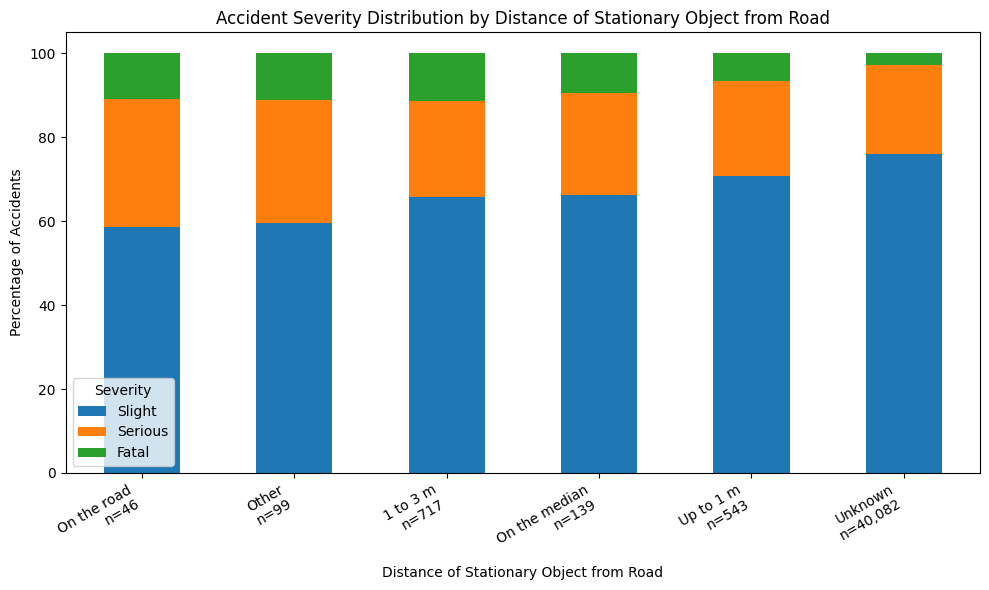

In [59]:
plot_severity_by_feature(
    train_df,
    "MERHAK_EZEM",
    "Distance of Stationary Object from Road"
)

Because only a small proportion of records contain a specific non-Unknown value, a grouped representation is evaluated to reduce sparsity.

In [60]:
def map_object_location(value):
    label = VALUE_LABELS["MERHAK_EZEM"].get(value)

    if label == "Unknown":
        return "Unknown"

    if label in [
        "Up to 1 m",
        "1 to 3 m",
    ]:
        return "Near road"

    if label in [
        "On the road",
        "On the median",
    ]:
        return "On road/median"

    return "Other"


train_df["OBJECT_LOCATION"] = (
    train_df["MERHAK_EZEM"]
    .map(map_object_location)
)

In [61]:
feature_summary(
    train_df,
    "OBJECT_LOCATION"
)

,count,subset_percentage,fatal_rate,serious_rate,slight_rate,severe_rate
feature,,,,,,
Other,99,0.24,11.11,29.29,59.60,40.40
On road/median,185,0.44,9.73,25.95,64.32,35.68
Near road,1260,3.03,9.29,22.78,67.94,32.06
Unknown,40082,96.29,2.83,21.05,76.12,23.88


In [62]:
known_object_df = train_df[
    train_df["SUG_EZEM"].map(
        VALUE_LABELS["SUG_EZEM"]
    ) != "Unknown"
].copy()

feature_summary(
    known_object_df,
    "OBJECT_LOCATION"
)

,count,subset_percentage,fatal_rate,serious_rate,slight_rate,severe_rate
feature,,,,,,
Other,97,4.15,11.34,28.87,59.79,40.21
On road/median,185,7.91,9.73,25.95,64.32,35.68
Unknown,800,34.19,6.38,28.50,65.12,34.88
Near road,1258,53.76,9.30,22.73,67.97,32.03


#### Observations

`MERHAK_EZEM` contains very limited information across the full dataset, with approximately 96% of the observations labeled as `Unknown`.

A grouped `OBJECT_LOCATION` feature was evaluated to reduce sparsity. However, when the analysis was restricted to accidents where a stationary object is already recorded in `SUG_EZEM`, the main object-location categories showed relatively similar severe accident rates, approximately 32% to 36%.

This suggests that much of the predictive signal is associated with the presence and type of the stationary object itself, which is already represented by `SUG_EZEM`, rather than its recorded distance from the road.

Therefore, `MERHAK_EZEM` provides limited additional information beyond `SUG_EZEM`.

`MERHAK_EZEM` is a candidate for removal, and the derived `OBJECT_LOCATION` feature will not be retained.

### LO_HAZA (Pedestrian Activity When Not Crossing)

In [63]:
feature_summary(
    train_df,
    "LO_HAZA"
)

,count,subset_percentage,fatal_rate,serious_rate,slight_rate,severe_rate
feature,,,,,,
Playing on the road,9,0.02,11.11,66.67,22.22,77.78
On a traffic island / median,33,0.08,0.00,51.52,48.48,51.52
On the shoulder / sidewalk,364,0.87,7.97,30.77,61.26,38.74
Walking in direction of traffic,40,0.10,12.50,22.50,65.00,35.00
Standing on the road,152,0.37,10.53,23.03,66.45,33.55
Walking against traffic,12,0.03,8.33,25.00,66.67,33.33
Other,365,0.88,6.85,21.10,72.05,27.95
Unknown,40651,97.66,2.96,21.01,76.03,23.97


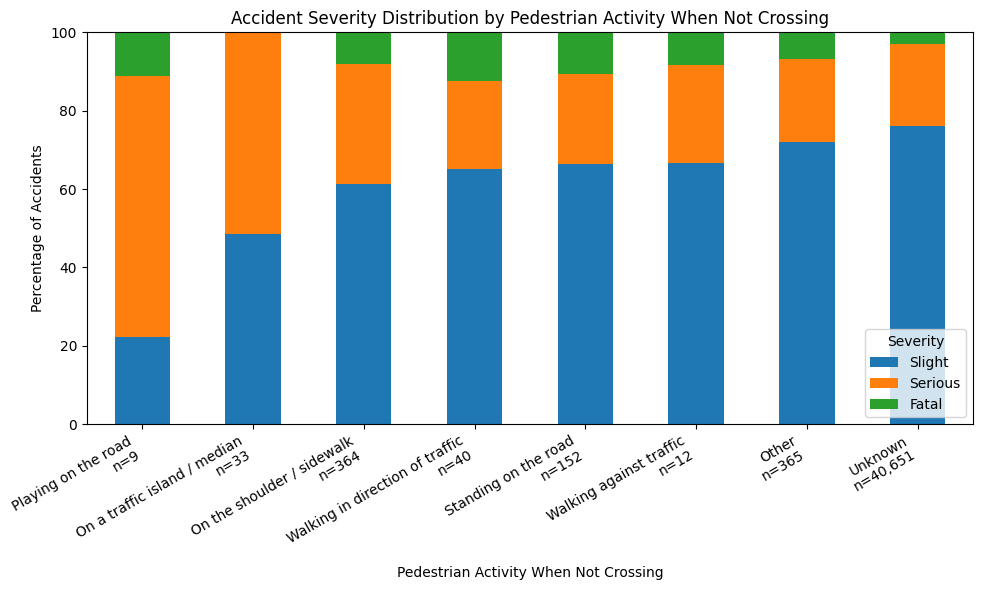

In [64]:
plot_severity_by_feature(
    train_df,
    "LO_HAZA",
    "Pedestrian Activity When Not Crossing"
)

In [65]:
def map_pedestrian_activity(value):
    label = VALUE_LABELS["LO_HAZA"].get(value)

    if label == "Unknown":
        return "Unknown"

    if label == "Playing on the road":
        return "Playing on the road"

    if label in [
        "Standing on the road",
        "Walking in direction of traffic",
        "Walking against traffic",
    ]:
        return "On / along roadway"

    if label in [
        "On a traffic island / median",
        "On the shoulder / sidewalk",
    ]:
        return "Roadside / protected area"

    return "Other"


train_df["PEDESTRIAN_ACTIVITY"] = (
    train_df["LO_HAZA"]
    .map(map_pedestrian_activity)
)

In [66]:
feature_summary(
    train_df,
    "PEDESTRIAN_ACTIVITY"
)

,count,subset_percentage,fatal_rate,serious_rate,slight_rate,severe_rate
feature,,,,,,
Playing on the road,9,0.02,11.11,66.67,22.22,77.78
Roadside / protected area,397,0.95,7.30,32.49,60.20,39.80
On / along roadway,204,0.49,10.78,23.04,66.18,33.82
Other,365,0.88,6.85,21.10,72.05,27.95
Unknown,40651,97.66,2.96,21.01,76.03,23.97


#### Observations

`LO_HAZA` appears to have a strong relationship with accident severity.

When the value is `Unknown`, the severe accident rate is approximately 24%.  
For the categories where pedestrian activity is recorded, the severe accident rate increases to approximately 33% to 78%, depending on the specific activity.

Because several of the original categories contain very few observations, semantically similar pedestrian activities are grouped to reduce sparsity.

The grouped feature will contain:

- `Roadside / protected area`
- `On / along roadway`
- `Playing on the road`
- `Other`
- `Unknown`

`Playing on the road` will remain as a standalone category because it shows a substantially higher severe accident rate, approximately 78%.

However, this category contains only 9 observations, so the result should be interpreted cautiously and its usefulness will need to be validated during modeling.

### OFEN_HAZIYA (Pedestrian Crossing Behavior)

In [67]:
feature_summary(
    train_df,
    "OFEN_HAZIYA"
)

,count,subset_percentage,fatal_rate,serious_rate,slight_rate,severe_rate
feature,,,,,,
Unknown whether crossed,145,0.35,8.97,44.83,46.21,53.79
Crossed while obscured,246,0.59,9.76,36.99,53.25,46.75
Darted into the road,1067,2.56,6.84,39.08,54.08,45.92
Did not cross,534,1.28,8.80,32.58,58.61,41.39
[Not applicable],33295,79.99,2.83,20.97,76.20,23.80
Other,767,1.84,3.13,17.21,79.66,20.34
Crossed normally,5572,13.39,2.80,16.89,80.31,19.69


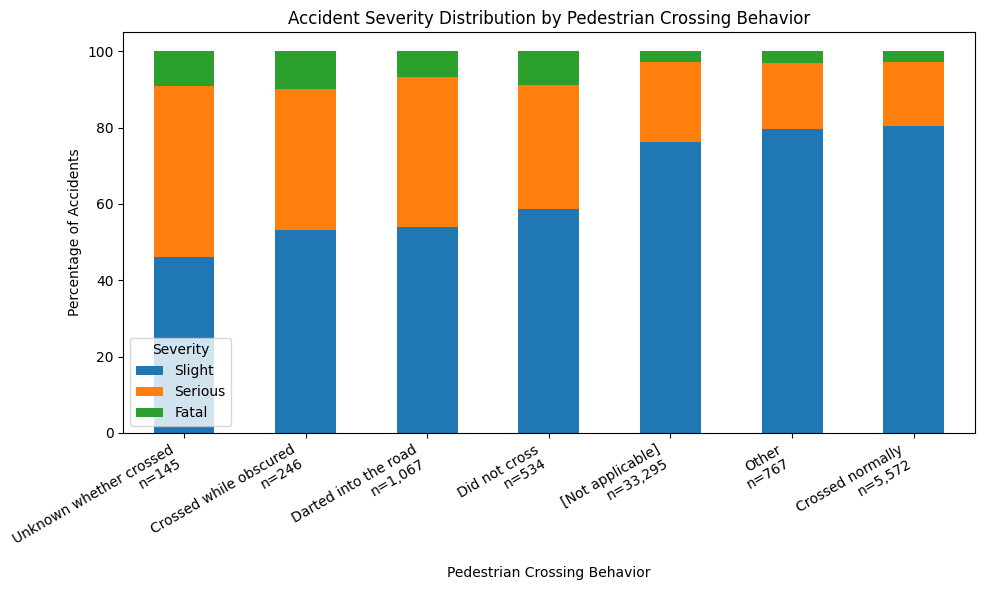

In [68]:
plot_severity_by_feature(
    train_df,
    "OFEN_HAZIYA",
    "Pedestrian Crossing Behavior"
)

#### Analysis within Pedestrian Accidents

Most non-zero values of `OFEN_HAZIYA` occur in pedestrian accidents, while `[Not applicable]` mainly represents other accident types.

Therefore, the severity differences observed in the full dataset may partly reflect the fact that pedestrian accidents are generally different from other accident types, rather than the effect of the pedestrian crossing behavior itself.

To reduce this confounding effect, `OFEN_HAZIYA` is analyzed separately within pedestrian accidents, excluding the structurally non-applicable category.

The goal is to check whether different crossing behaviors are still associated with accident severity when comparing only pedestrian accidents.

In [69]:
pedestrian_df = train_df[
    train_df["SUG_TEUNA"] == 1
].copy()

feature_summary(
    pedestrian_df,
    "OFEN_HAZIYA",
    exclude_values=[0]
)

,count,subset_percentage,fatal_rate,serious_rate,slight_rate,severe_rate
feature,,,,,,
Unknown whether crossed,145,1.75,8.97,44.83,46.21,53.79
Crossed while obscured,244,2.95,9.84,36.89,53.28,46.72
Darted into the road,1060,12.83,6.79,39.15,54.06,45.94
Did not cross,528,6.39,8.90,32.01,59.09,40.91
Other,758,9.17,2.90,16.89,80.21,19.79
Crossed normally,5528,66.90,2.80,16.82,80.37,19.63


#### Observations

`OFEN_HAZIYA` shows a meaningful relationship with accident severity even when the analysis is restricted to pedestrian accidents.

`Crossed normally` is the most common behavior and has a relatively low severe accident rate of approximately 20%.

In contrast, `Darted into the road`, `Crossed while obscured`, and `Did not cross` show substantially higher severe accident rates, approximately 41% to 47%.

`Unknown whether crossed` has the highest severe accident rate, approximately 54%, although this category contains relatively few observations.

This suggests that `OFEN_HAZIYA` provides additional predictive information beyond simply identifying pedestrian accidents.

The relationship should not be interpreted causally, since accident severity may also depend on road type, vehicle speed, lighting conditions, pedestrian location, and other factors.

The original categories will be retained for modeling. Grouping may be evaluated later if needed.

### MEKOM_HAZIYA


In [70]:
feature_summary(
    train_df,
    "MEKOM_HAZIYA"
)

,count,subset_percentage,fatal_rate,serious_rate,slight_rate,severe_rate
feature,,,,,,
"Not at crosswalk, not near intersection",1229,2.95,9.52,43.69,46.79,53.21
"Not at crosswalk, near intersection",286,0.69,9.44,40.21,50.35,49.65
Crossing location unknown,208,0.50,5.29,29.81,64.90,35.10
At crosswalk with traffic light,1050,2.52,5.71,24.10,70.19,29.81
[Not applicable],33999,81.68,2.95,21.31,75.75,24.25
At crosswalk without traffic light,4854,11.66,1.28,12.15,86.57,13.43


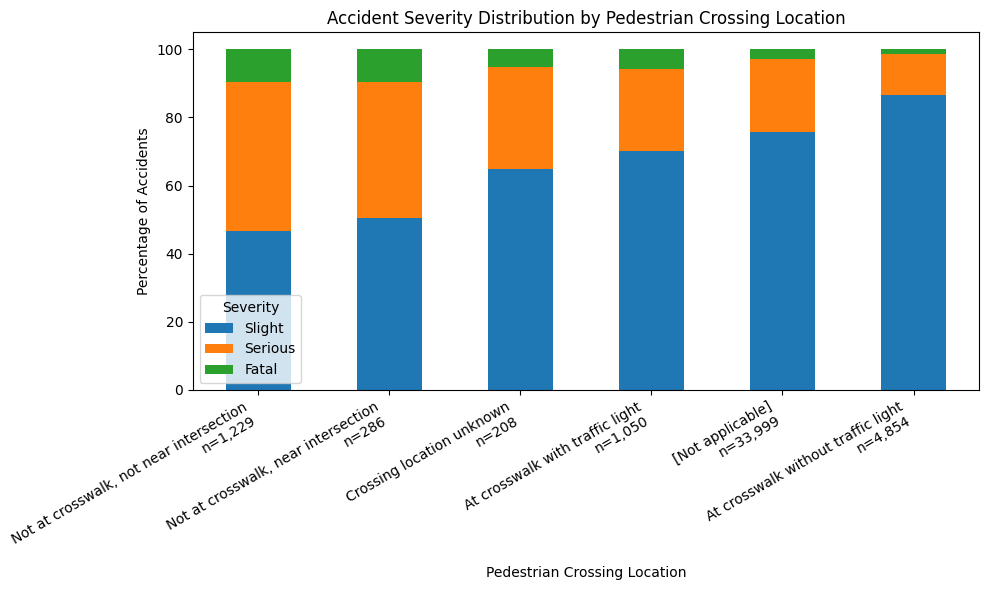

In [71]:
plot_severity_by_feature(
    train_df,
    "MEKOM_HAZIYA",
    "Pedestrian Crossing Location"
)

#### Derived Feature: Crosswalk Usage

The original `MEKOM_HAZIYA` categories show a strong distinction between accidents occurring at a crosswalk and those occurring outside a crosswalk.

To capture this broader pattern, I created an additional `CROSSWALK_USAGE` feature that groups crossing locations into:

- `At crosswalk`
- `Not at crosswalk`
- `Unknown`
- `[Not applicable]`

The original `MEKOM_HAZIYA` feature will also be retained because meaningful differences remain within both the crosswalk and non-crosswalk categories.

This allows the model to use both the broader crosswalk signal and the more detailed crossing-location information.

In [72]:
def map_crosswalk_usage(value):
    label = VALUE_LABELS["MEKOM_HAZIYA"].get(value)

    if label in [
        "At crosswalk with traffic light",
        "At crosswalk without traffic light",
    ]:
        return "At crosswalk"

    if label in [
        "Not at crosswalk, near intersection",
        "Not at crosswalk, not near intersection",
    ]:
        return "Not at crosswalk"

    if label == "Crossing location unknown":
        return "Unknown"

    return "[Not applicable]"


train_df["CROSSWALK_USAGE"] = (
    train_df["MEKOM_HAZIYA"]
    .map(map_crosswalk_usage)
)

feature_summary(
    train_df,
    "CROSSWALK_USAGE"
)

,count,subset_percentage,fatal_rate,serious_rate,slight_rate,severe_rate
feature,,,,,,
Not at crosswalk,1515,3.64,9.50,43.04,47.46,52.54
Unknown,208,0.50,5.29,29.81,64.90,35.10
[Not applicable],33999,81.68,2.95,21.31,75.75,24.25
At crosswalk,5904,14.18,2.07,14.28,83.66,16.34


#### Observations

`MEKOM_HAZIYA` shows a strong relationship with accident severity.

Crossing at a crosswalk is associated with substantially lower severe accident rates compared with crossing outside a crosswalk.

- `At crosswalk without traffic light` has the lowest severe accident rate, approximately 13%.
- `At crosswalk with traffic light` has a higher severe accident rate, approximately 30%.
- `Not at crosswalk, near intersection` has a severe accident rate of approximately 50%.
- `Not at crosswalk, not near intersection` has the highest severe accident rate, approximately 53%.

This suggests that whether the pedestrian crossed at a crosswalk is an important signal. However, meaningful differences also exist within the crosswalk and non-crosswalk categories.

Therefore, the original `MEKOM_HAZIYA` feature will be retained, and an additional derived `CROSSWALK_USAGE` feature will be created to capture the broader distinction between `At crosswalk` and `Not at crosswalk`.

`[Not applicable]` is treated as a structural value rather than an unknown crossing location, since it mainly represents cases where a crossing location is not relevant.

These relationships should be interpreted as associations rather than causal effects, since other factors such as road type, traffic conditions, and vehicle speed may also influence accident severity.

### KIVUN_HAZIYA (Pedestrian Crossing Direction)

In [73]:
feature_summary(
    train_df,
    "KIVUN_HAZIYA"
)

,count,subset_percentage,fatal_rate,serious_rate,slight_rate,severe_rate
feature,,,,,,
Left to right,2231,5.36,3.85,22.10,74.05,25.95
Right to left,3612,8.68,3.82,20.49,75.69,24.31
Unknown,35783,85.96,2.95,21.15,75.90,24.10


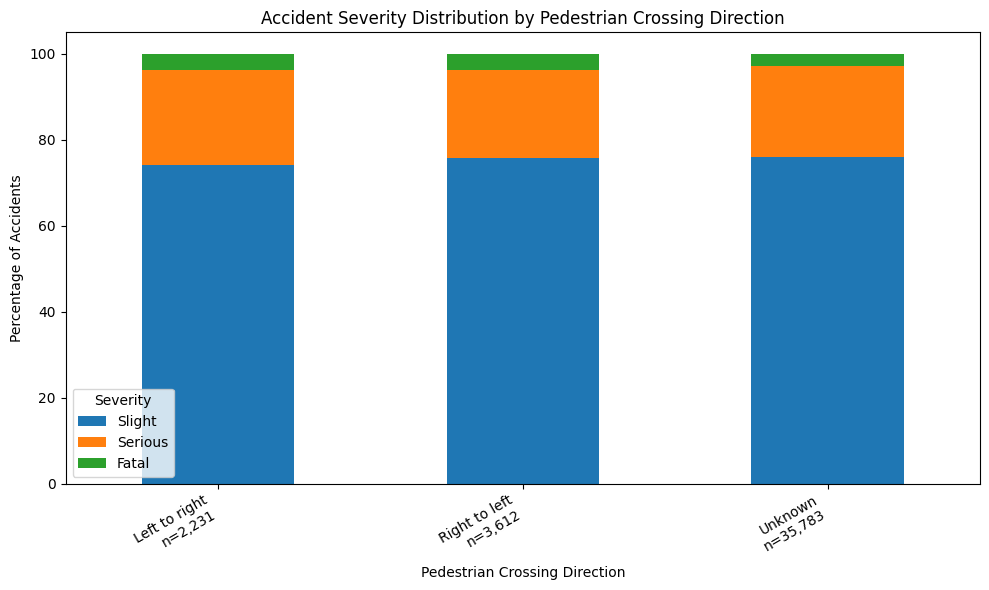

In [74]:
plot_severity_by_feature(
    train_df,
    "KIVUN_HAZIYA",
    "Pedestrian Crossing Direction"
)

#### Observations

`KIVUN_HAZIYA` shows very little relationship with accident severity.

The severe accident rate is approximately 24% to 26% across all categories:

- `Left to right`: approximately 26%
- `Right to left`: approximately 24%
- `Unknown`: approximately 24%

The small differences between the categories suggest that pedestrian crossing direction provides limited predictive value for accident severity.

Therefore, `KIVUN_HAZIYA` is a strong candidate for removal during feature selection.

### MAHOZ (District)

In [75]:
feature_summary(
    train_df,
    "MAHOZ"
)

,count,subset_percentage,fatal_rate,serious_rate,slight_rate,severe_rate
feature,,,,,,
Unknown District,83,0.20,13.25,54.22,32.53,67.47
Southern District,4679,11.24,5.49,27.72,66.79,33.21
Judea and Samaria Area,1681,4.04,7.14,23.91,68.95,31.05
Central District,8964,21.53,3.20,22.36,74.44,25.56
Jerusalem District,3975,9.55,2.19,22.52,75.30,24.70
Northern District,6399,15.37,3.41,19.85,76.75,23.25
Haifa District,5802,13.94,2.36,19.03,78.61,21.39
Tel Aviv District,10043,24.13,1.61,17.76,80.62,19.38


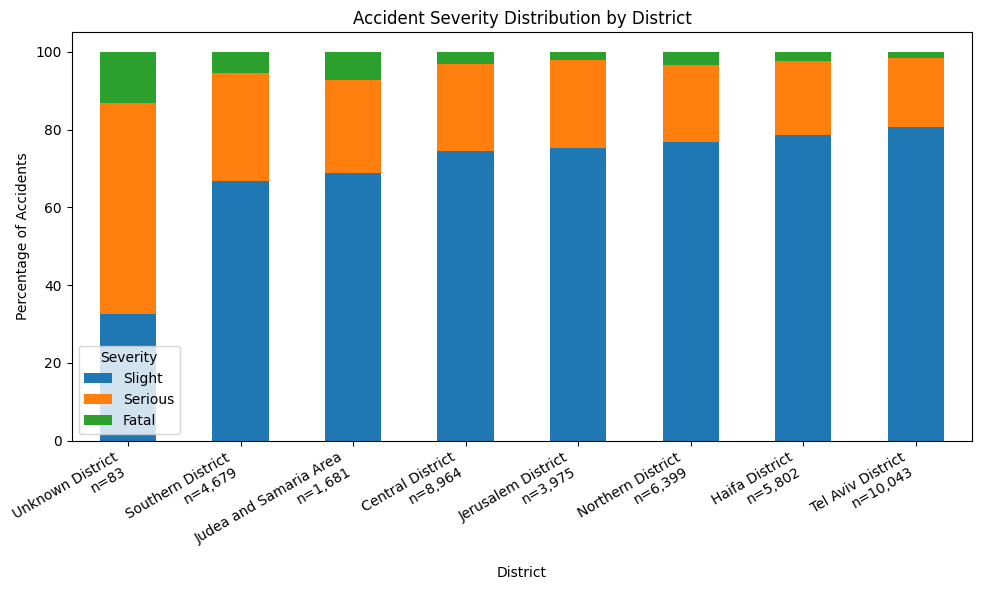

In [76]:
plot_severity_by_feature(
    train_df,
    "MAHOZ",
    "District"
)

#### Observations

`MAHOZ` shows a strong association with accident severity.

There are substantial differences in severe accident rates between districts. For example:

- `Southern District`: approximately 33% severe
- `Judea and Samaria Area`: approximately 31% severe
- `Central District`: approximately 26% severe
- `Tel Aviv District`: approximately 19% severe

The difference between the `Southern District` and the `Tel Aviv District` is particularly large, suggesting that district may provide useful predictive information.

`Unknown District` has a very high severe accident rate of approximately 67%, but it contains only 83 observations, so this result should be interpreted cautiously.

These differences should not be interpreted as a causal effect of the district itself. District may also capture differences in road types, permitted speeds, urbanization, traffic patterns, and other regional characteristics.

`MAHOZ` will be retained as a candidate feature for modeling.

### NAFA (Subdistrict)

In [77]:
feature_summary(
    train_df,
    "NAFA"
)

,count,subset_percentage,fatal_rate,serious_rate,slight_rate,severe_rate
feature,,,,,,
Unknown Subdistrict,83,0.20,13.25,54.22,32.53,67.47
Be'er Sheva,2339,5.62,7.35,33.30,59.34,40.66
Ramla,1231,2.96,3.74,31.52,64.74,35.26
Golan,257,0.62,4.28,28.02,67.70,32.30
Judea and Samaria Area,1681,4.04,7.14,23.91,68.95,31.05
Rehovot,2041,4.90,3.72,26.56,69.72,30.28
Yizre'el,1760,4.23,4.77,22.67,72.56,27.44
Ashkelon,2340,5.62,3.63,22.14,74.23,25.77
Kinneret,617,1.48,2.11,23.50,74.39,25.61


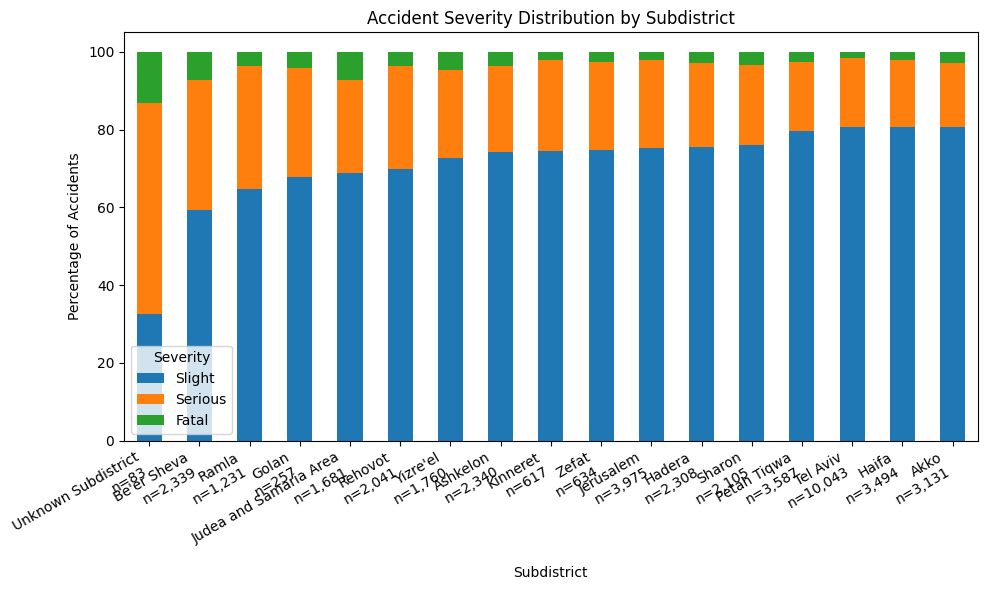

In [78]:
plot_severity_by_feature(
    train_df,
    "NAFA",
    "Subdistrict"
)

#### Subdistrict vs District

`NAFA` is geographically nested within `MAHOZ`, so some of the severity differences between subdistricts may simply reflect differences between their parent districts.

To evaluate whether `NAFA` provides additional information beyond `MAHOZ`, the severe accident rate of each subdistrict is compared with the overall rate of its parent district.

If subdistricts within the same district show meaningful differences in severity, this would suggest that `NAFA` captures additional geographic information beyond `MAHOZ`.

In [79]:
district_severity = (
    train_df
    .groupby("MAHOZ")
    .agg(
        district_count=("HUMRAT_TEUNA", "size"),
        district_fatal_rate=(
            "HUMRAT_TEUNA",
            lambda x: (x == 1).mean() * 100
        ),
        district_serious_rate=(
            "HUMRAT_TEUNA",
            lambda x: (x == 2).mean() * 100
        )
    )
    .reset_index()
)

district_severity["district_severe_rate"] = (
    district_severity["district_fatal_rate"]
    + district_severity["district_serious_rate"]
)

district_subdistrict_severity = (
    train_df
    .groupby(["MAHOZ", "NAFA"])
    .agg(
        count=("HUMRAT_TEUNA", "size"),
        fatal_rate=(
            "HUMRAT_TEUNA",
            lambda x: (x == 1).mean() * 100
        ),
        serious_rate=(
            "HUMRAT_TEUNA",
            lambda x: (x == 2).mean() * 100
        )
    )
    .reset_index()
)

district_subdistrict_severity["severe_rate"] = (
    district_subdistrict_severity["fatal_rate"]
    + district_subdistrict_severity["serious_rate"]
)

subdistrict_comparison = (
    district_subdistrict_severity
    .merge(
        district_severity[
            [
                "MAHOZ",
                "district_severe_rate"
            ]
        ],
        on="MAHOZ",
        how="left"
    )
)

subdistrict_comparison["difference_pp"] = (
    subdistrict_comparison["severe_rate"]
    - subdistrict_comparison["district_severe_rate"]
)

subdistrict_comparison["District"] = (
    subdistrict_comparison["MAHOZ"]
    .map(VALUE_LABELS["MAHOZ"])
)

subdistrict_comparison["Subdistrict"] = (
    subdistrict_comparison["NAFA"]
    .map(VALUE_LABELS["NAFA"])
)

# Sort by absolute difference from the district severe rate
subdistrict_comparison = (
    subdistrict_comparison
    .assign(
        abs_difference_pp=lambda df: df["difference_pp"].abs()
    )
    .sort_values(
        "abs_difference_pp",
        ascending=False
    )
)

subdistrict_comparison[
    [
        "District",
        "Subdistrict",
        "count",
        "severe_rate",
        "district_severe_rate",
        "difference_pp"
    ]
].round(2)

,District,Subdistrict,count,severe_rate,district_severe_rate,difference_pp
10,Central District,Ramla,1231,35.26,25.56,9.70
5,Northern District,Golan,257,32.30,23.25,9.04
14,Southern District,Be'er Sheva,2339,40.66,33.21,7.45
13,Southern District,Ashkelon,2340,25.77,33.21,-7.44
9,Central District,Petah Tiqwa,3587,20.41,25.56,-5.15
11,Central District,Rehovot,2041,30.28,25.56,4.72
3,Northern District,Yizre'el,1760,27.44,23.25,4.19
4,Northern District,Akko,3131,19.29,23.25,-3.96
7,Haifa District,Hadera,2308,24.52,21.39,3.13
2,Northern District,Kinneret,617,25.61,23.25,2.35


#### Observations

Several subdistricts show meaningful differences in severe accident rates compared with their parent district.

For example:

- `NAFA 43` has a severe accident rate approximately 9.7 percentage points higher than the Central District average.
- `NAFA 62` is approximately 7.5 percentage points above the Southern District average.
- `NAFA 61` is approximately 7.4 percentage points below the Southern District average.

This suggests that `NAFA` captures more detailed geographic information than `MAHOZ`.

Since each `NAFA` belongs to a single district, the subdistrict feature already implicitly contains the district information.

Therefore, both features will initially be retained. Its incremental contribution beyond `NAFA` will be evaluated using temporal cross-validation.

### EZOR_TIVI (Natural Area)

In [80]:
feature_summary(
    train_df,
    "EZOR_TIVI"
)

,count,subset_percentage,fatal_rate,serious_rate,slight_rate,severe_rate
feature,,,,,,
Dead Sea Region,34,0.08,11.76,67.65,20.59,79.41
Unknown Natural Area,83,0.20,13.25,54.22,32.53,67.47
Southern Negev Mountain,7,0.02,14.29,42.86,42.86,57.14
Northern Negev Mountain,182,0.44,11.54,40.66,47.80,52.20
Menashe Plateau,37,0.09,8.11,43.24,48.65,51.35
Besor Region,165,0.40,6.06,43.64,50.30,49.70
Northern Golan,99,0.24,8.08,33.33,58.59,41.41
Be'er Sheva Region,1503,3.61,7.05,33.00,59.95,40.05
Southern Golan,30,0.07,6.67,33.33,60.00,40.00


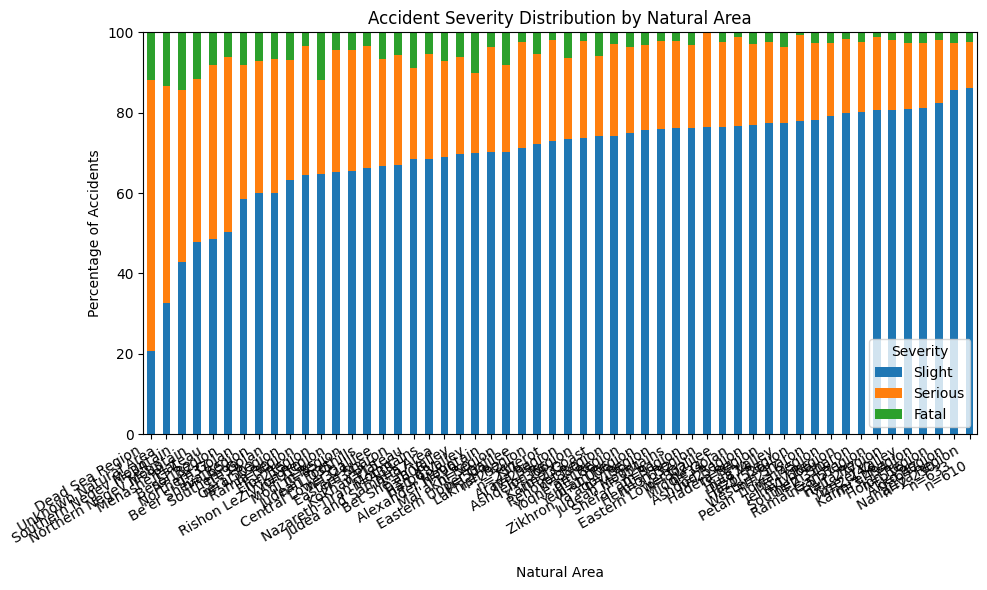

In [81]:
plot_severity_by_feature(
    train_df,
    "EZOR_TIVI",
    "Natural Area"
)

#### Natural Area vs Subdistrict

`EZOR_TIVI` is geographically nested within `NAFA`, with each natural area belonging to a single subdistrict.

The feature shows substantial variation in severe accident rates, but it also has relatively high cardinality, with 54 different values, and several categories contain very few observations.

To evaluate whether `EZOR_TIVI` adds information beyond `NAFA`, each natural area's severe accident rate is compared with that of its parent subdistrict.

Meaningful differences within the same subdistrict would suggest that `EZOR_TIVI` captures additional geographic information. However, differences based on very small sample sizes should be interpreted cautiously.

In [82]:
subdistrict_severity = (
    train_df
    .groupby("NAFA")
    .agg(
        subdistrict_count=("HUMRAT_TEUNA", "size"),
        subdistrict_fatal_rate=(
            "HUMRAT_TEUNA",
            lambda x: (x == 1).mean() * 100
        ),
        subdistrict_serious_rate=(
            "HUMRAT_TEUNA",
            lambda x: (x == 2).mean() * 100
        )
    )
    .reset_index()
)

subdistrict_severity["subdistrict_severe_rate"] = (
    subdistrict_severity["subdistrict_fatal_rate"]
    + subdistrict_severity["subdistrict_serious_rate"]
)


natural_area_severity = (
    train_df
    .groupby(["NAFA", "EZOR_TIVI"])
    .agg(
        count=("HUMRAT_TEUNA", "size"),
        fatal_rate=(
            "HUMRAT_TEUNA",
            lambda x: (x == 1).mean() * 100
        ),
        serious_rate=(
            "HUMRAT_TEUNA",
            lambda x: (x == 2).mean() * 100
        )
    )
    .reset_index()
)

natural_area_severity["severe_rate"] = (
    natural_area_severity["fatal_rate"]
    + natural_area_severity["serious_rate"]
)


natural_area_comparison = (
    natural_area_severity
    .merge(
        subdistrict_severity[
            [
                "NAFA",
                "subdistrict_severe_rate"
            ]
        ],
        on="NAFA",
        how="left"
    )
)

natural_area_comparison["difference_pp"] = (
    natural_area_comparison["severe_rate"]
    - natural_area_comparison["subdistrict_severe_rate"]
)

natural_area_comparison["Subdistrict"] = (
    natural_area_comparison["NAFA"]
    .map(VALUE_LABELS["NAFA"])
)

natural_area_comparison = (
    natural_area_comparison
    .assign(
        abs_difference_pp=lambda df:
            df["difference_pp"].abs()
    )
    .sort_values(
        "abs_difference_pp",
        ascending=False
    )
)

natural_area_comparison[
    [
        "Subdistrict",
        "EZOR_TIVI",
        "count",
        "severe_rate",
        "subdistrict_severe_rate",
        "difference_pp"
    ]
].round(2)

,Subdistrict,EZOR_TIVI,count,severe_rate,subdistrict_severe_rate,difference_pp
48,Be'er Sheva,624,34,79.41,40.66,38.75
13,Yizre'el,236,37,51.35,27.44,23.91
51,Be'er Sheva,627,7,57.14,40.66,16.48
18,Akko,244,85,35.29,19.29,16.00
49,Be'er Sheva,625,233,26.61,40.66,-14.05
50,Be'er Sheva,626,182,52.20,40.66,11.54
22,Golan,292,99,41.41,32.30,9.12
1,Jerusalem,112,343,33.82,24.70,9.11
46,Be'er Sheva,622,165,49.70,40.66,9.04
31,Sharon,412,439,33.03,24.09,8.94


#### Observations

`EZOR_TIVI` shows meaningful variation in severe accident rates within the same subdistrict, suggesting that it captures additional geographic information beyond `NAFA`.

Several natural areas differ substantially from the severe accident rate of their parent subdistrict.

Some of the largest differences are based on very small sample sizes and should therefore be interpreted cautiously. However, meaningful differences also appear in natural areas with hundreds or thousands of observations.

For example, within the same subdistrict:

- `Rehovot` contains natural areas with severe accident rates approximately 4.5 percentage points below and 4.4 percentage points above the subdistrict average, with more than 1,000 observations in each group.
- In `Sharon`, one natural area is approximately 8.9 percentage points above the subdistrict average with 439 observations.
- Several natural areas within `Akko`, `Yizre'el`, and `Be'er Sheva` also show noticeable differences from their parent subdistricts.

This suggests that `EZOR_TIVI` may provide additional predictive information beyond `NAFA`.

However, the feature has relatively high cardinality with 54 categories, and several natural areas contain very few observations.

Therefore, `EZOR_TIVI` will be retained as a candidate feature, but its contribution should be evaluated during modeling. Models using `NAFA`, `EZOR_TIVI`, and both representations will be compared during temporal cross-validation to determine whether the additional geographic granularity improves generalization.

### MAAMAD_MINIZIPALI

In [83]:
feature_summary(
    train_df,
    "MAAMAD_MINIZIPALI"
)

,count,subset_percentage,fatal_rate,serious_rate,slight_rate,severe_rate
feature,,,,,,
68.0,13,0.03,23.08,76.92,0.00,100.00
41.0,3,0.01,0.00,100.00,0.00,100.00
42.0,2,0.00,0.00,100.00,0.00,100.00
48.0,3,0.01,0.00,100.00,0.00,100.00
54.0,1,0.00,0.00,100.00,0.00,100.00
32.0,1,0.00,0.00,100.00,0.00,100.00
38.0,6,0.01,0.00,83.33,16.67,83.33
69.0,5,0.01,20.00,60.00,20.00,80.00
29.0,4,0.01,25.00,50.00,25.00,75.00


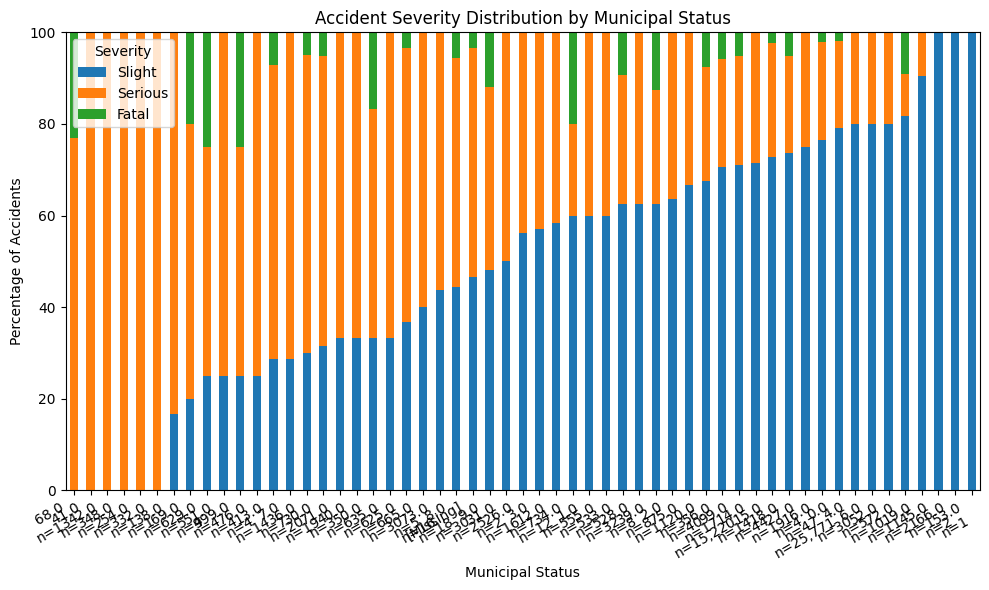

In [84]:
plot_severity_by_feature(
    train_df,
    "MAAMAD_MINIZIPALI",
    "Municipal Status"
)

In [85]:
train_df["MAAMAD_MINIZIPALI"].nunique(dropna=False)

55

In [86]:
train_df["MAAMAD_MINIZIPALI"].value_counts(
    dropna=False
)

MAAMAD_MINIZIPALI
0.0      25771
99.0     15220
16.0        47
15.0        44
20.0        40
33.0        32
25.0        30
4.0         30
NaN         30
9.0         25
19.0        21
36.0        20
18.0        19
30.0        19
8.0         18
56.0        17
73.0        16
26.0        16
13.0        14
14.0        14
68.0        13
12.0        12
2.0         11
72.0        11
52.0        10
28.0         8
39.0         8
7.0          7
3.0          7
38.0         6
35.0         6
40.0         6
50.0         6
34.0         5
65.0         5
1.0          5
6.0          5
69.0         5
55.0         5
27.0         4
999.0        4
51.0         4
76.0         4
29.0         4
48.0         3
41.0         3
71.0         3
75.0         3
66.0         2
31.0         2
42.0         2
54.0         1
53.0         1
45.0         1
32.0         1
Name: count, dtype: int64

#### Municipal Status Grouping

`MAAMAD_MINIZIPALI` contains 55 different values, but these values do not represent 55 different municipal status types.

The coding combines municipal status with the identifier of a specific regional council:

- `0` represents a municipality.
- `99` represents a local council.
- Values from `1` to `78` identify specific regional councils.

Most observations belong to either municipalities or local councils, while individual regional council codes are very sparse.

A lower-cardinality `MUNICIPAL_STATUS` feature is therefore derived from the original codes, grouping them into broader municipal status categories.

In [87]:
def map_municipal_status(value):
    if pd.isna(value):
        return "Missing"

    if value == 0:
        return "Municipality"

    if value == 99:
        return "Local Council"

    if 1 <= value <= 78:
        return "Regional Council"

    return "Unknown"


train_df["MUNICIPAL_STATUS"] = (
    train_df["MAAMAD_MINIZIPALI"]
    .map(map_municipal_status)
)

In [88]:
feature_summary(
    train_df,
    "MUNICIPAL_STATUS"
)

,count,subset_percentage,fatal_rate,serious_rate,slight_rate,severe_rate
feature,,,,,,
Unknown,4,0.01,25.00,50.00,25.00,75.00
Missing,30,0.07,3.33,50.00,46.67,53.33
Regional Council,601,1.44,4.49,38.77,56.74,43.26
Local Council,15220,36.56,5.14,23.78,71.08,28.92
Municipality,25771,61.91,1.82,19.14,79.05,20.95


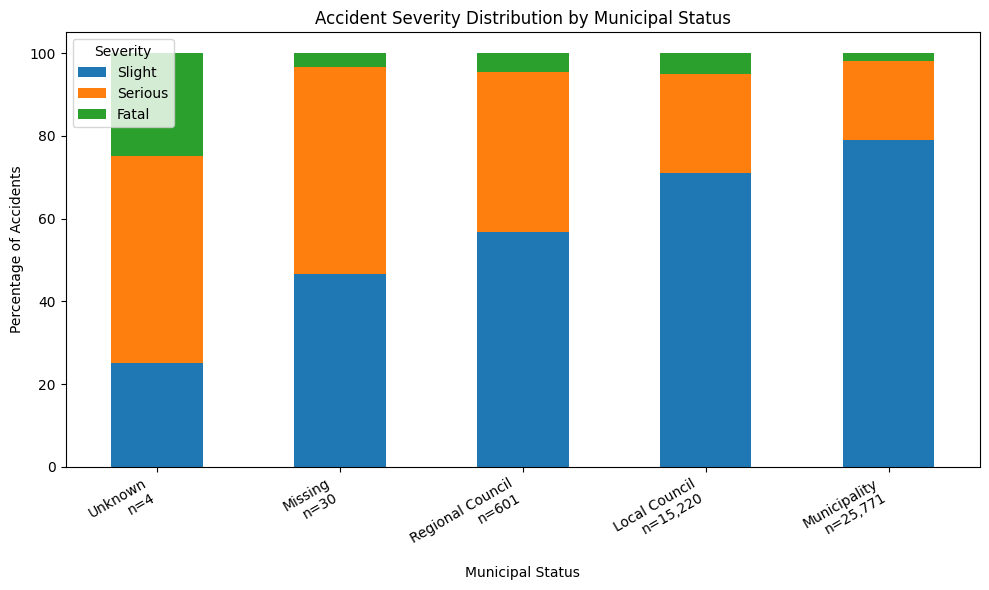

In [89]:
plot_severity_by_feature(
    train_df,
    "MUNICIPAL_STATUS",
    "Municipal Status"
)

#### Observations

The derived `MUNICIPAL_STATUS` feature provides a clearer and more stable representation than the original `MAAMAD_MINIZIPALI` feature.

The severe accident rate differs substantially between the main municipal status categories:

- `Municipality`: approximately 21%
- `Local Council`: approximately 29%
- `Regional Council`: approximately 43%

Accidents in municipalities have a considerably lower severe accident rate than accidents in local and regional councils.

The original `MAAMAD_MINIZIPALI` feature contains many sparse categories because individual regional councils are represented by separate codes.

Therefore, `MAAMAD_MINIZIPALI` will be considered for removal during modeling, while the derived `MUNICIPAL_STATUS` feature will be retained as a candidate feature.

The final decision will be based on model performance during cross-validation.

### ZURAT_ISHUV (Locality type)

`ZURAT_ISHUV` describes the type of locality and is applicable only to urban accidents.

The value `99` appears exclusively in non-urban accidents. All 13,625 non-urban accidents have this value, while no urban accident does.

Therefore, `99` is treated as a structural `[Not applicable]` value rather than as an unknown locality type.

The severity rate associated with this category mainly reflects the difference between urban and non-urban roads and should not be interpreted as an effect of locality type.

In [90]:
feature_summary(
    train_df,
    "ZURAT_ISHUV",
    exclude_values=[99]
)

,count,subset_percentage,fatal_rate,serious_rate,slight_rate,severe_rate
feature,,,,,,
Bedouin tribe,8,0.03,12.50,87.50,0.00,100.00
[Missing],4,0.01,25.00,50.00,25.00,75.00
Community locality,13,0.05,7.69,46.15,46.15,53.85
"Non-Jewish locality, 2,000-4,999 residents",62,0.22,8.06,41.94,50.00,50.00
Kibbutz,96,0.34,3.12,45.83,51.04,48.96
Moshav / cooperative village,253,0.90,4.74,43.87,51.38,48.62
"Non-Jewish locality, 50,000-99,999 residents",288,1.03,5.56,42.36,52.08,47.92
Other non-Jewish rural locality,23,0.08,8.70,39.13,52.17,47.83
Other rural locality,7,0.02,0.00,42.86,57.14,42.86


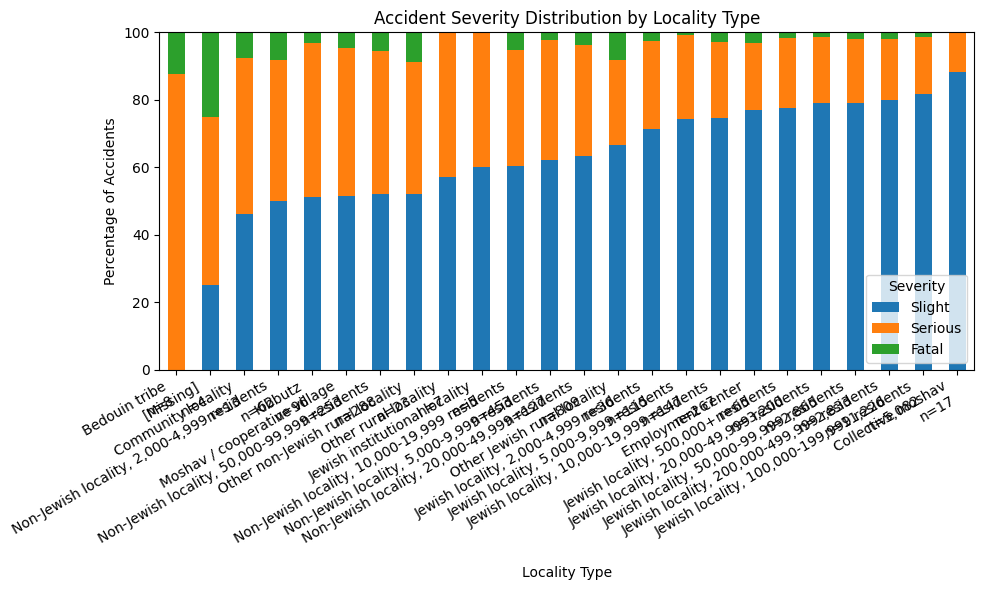

In [91]:
plot_severity_by_feature(
    train_df,
    "ZURAT_ISHUV",
    "Locality Type",
    exclude_values=[99]
)

In [92]:
train_df["ZURAT_ISHUV"].nunique(dropna=False)

25

In [93]:
train_df["ZURAT_ISHUV"].value_counts(
    dropna=False
)

ZURAT_ISHUV
99.0    13625
13.0    11226
14.0     5082
12.0     3200
16.0     2865
15.0     2833
26.0      809
27.0      453
25.0      288
17.0      267
31.0      253
18.0      147
28.0      127
19.0      115
33.0       96
52.0       65
29.0       62
35.0       36
45.0       23
32.0       17
37.0       13
46.0        8
49.0        7
34.0        5
NaN         4
Name: count, dtype: int64

#### Observations

`ZURAT_ISHUV` shows a meaningful relationship with accident severity among urban accidents.

Several patterns are visible:

- Large Jewish localities have relatively similar severe accident rates, generally around 18% to 22%.
- Smaller Jewish localities show somewhat higher severe accident rates, approximately 25% to 29%.
- Non-Jewish localities show substantially higher severe accident rates, generally around 37% to 50%.
- Several rural locality types also show high severe accident rates, although many of these categories contain relatively few observations and should therefore be interpreted cautiously.

The differences are not limited to very small categories. For example, `Non-Jewish locality, 20,000-49,999 residents` contains 809 observations and has a severe accident rate of approximately 37%, compared with approximately 21% for Jewish localities of the same population range.

This suggests that `ZURAT_ISHUV` contains useful predictive information beyond simply distinguishing urban from non-urban roads.

The original feature will be retained as a candidate for modeling. Broader grouped features may also be evaluated to reduce sparsity while preserving information about locality characteristics.

#### Locality Size Feature Engineering  

In [94]:
def map_locality_size(value):
    if pd.isna(value):
        return "Missing"

    if value == 99:
        return "[Not applicable]"

    size_mapping = {
        12: "500,000+",
        13: "200,000-499,999",
        14: "100,000-199,999",
        15: "50,000-99,999",
        16: "20,000-49,999",
        17: "10,000-19,999",
        18: "5,000-9,999",
        19: "2,000-4,999",

        25: "50,000-99,999",
        26: "20,000-49,999",
        27: "10,000-19,999",
        28: "5,000-9,999",
        29: "2,000-4,999",
    }

    return size_mapping.get(value, "Other")


def map_locality_form(value):
    if pd.isna(value):
        return "Missing"

    if value == 99:
        return "[Not applicable]"

    if value in range(12, 30):
        return "Urban locality"

    if value in [
        31, 32, 33, 34, 35, 37,
        44, 45, 46, 49
    ]:
        return "Rural locality"

    if value in [9, 51, 52, 53, 59]:
        return "Other / special"

    return "Other / special"


train_df["LOCALITY_SIZE"] = (
    train_df["ZURAT_ISHUV"]
    .map(map_locality_size)
)

train_df["LOCALITY_FORM"] = (
    train_df["ZURAT_ISHUV"]
    .map(map_locality_form)
)

In [95]:
feature_summary(
    train_df,
    "LOCALITY_SIZE"
)

,count,subset_percentage,fatal_rate,serious_rate,slight_rate,severe_rate
feature,,,,,,
Missing,4,0.01,25.00,50.00,25.00,75.00
Other,523,1.26,4.59,39.39,56.02,43.98
"2,000-4,999",177,0.43,4.52,31.64,63.84,36.16
"10,000-19,999",720,1.73,4.44,30.00,65.56,34.44
"5,000-9,999",274,0.66,1.46,29.93,68.61,31.39
[Not applicable],13625,32.73,5.37,23.32,71.32,28.68
"20,000-49,999",3674,8.83,1.93,22.51,75.56,24.44
"50,000-99,999",3121,7.50,2.27,21.05,76.67,23.33
"500,000+",3200,7.69,1.56,20.81,77.62,22.38


In [96]:
feature_summary(
    train_df,
    "LOCALITY_FORM"
)

,count,subset_percentage,fatal_rate,serious_rate,slight_rate,severe_rate
feature,,,,,,
Missing,4,0.01,25.00,50.00,25.00,75.00
Rural locality,458,1.10,4.80,42.14,53.06,46.94
[Not applicable],13625,32.73,5.37,23.32,71.32,28.68
Other / special,65,0.16,3.08,20.00,76.92,23.08
Urban locality,27474,66.00,1.90,19.71,78.38,21.62


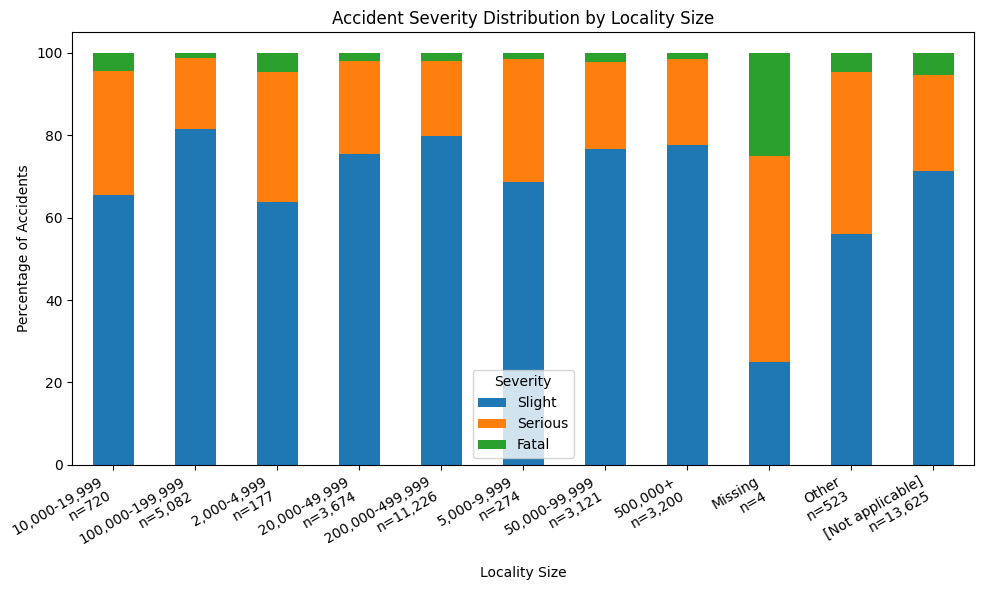

In [97]:
plot_severity_by_feature(
    train_df,
    "LOCALITY_SIZE",
    "Locality Size",
    sort_by_severe=False
)

#### Locality Sector - Feature Engineering  

In [98]:
def map_locality_sector(value):
    if pd.isna(value):
        return "Missing"

    label = VALUE_LABELS["ZURAT_ISHUV"].get(value)

    if label == "[Not applicable]":
        return "[Not applicable]"

    if label is None:
        return "Other / special"

    if (
        label.startswith("Jewish locality")
        or label in [
            "Moshav / cooperative village",
            "Collective moshav",
            "Kibbutz",
            "Jewish institutional locality",
            "Other Jewish rural locality",
            "Community locality",
        ]
    ):
        return "Jewish locality"

    if (
        label.startswith("Non-Jewish locality")
        or label in [
            "Non-Jewish institutional locality",
            "Other non-Jewish rural locality",
            "Bedouin tribe",
        ]
    ):
        return "Non-Jewish locality"

    return "Other / special"


train_df["LOCALITY_SECTOR"] = (
    train_df["ZURAT_ISHUV"]
    .map(map_locality_sector)
)

In [99]:
feature_summary(
    train_df,
    "LOCALITY_SECTOR"
)

,count,subset_percentage,fatal_rate,serious_rate,slight_rate,severe_rate
feature,,,,,,
Missing,4,0.01,25.00,50.00,25.00,75.00
Non-Jewish locality,1770,4.25,4.58,35.71,59.72,40.28
[Not applicable],13625,32.73,5.37,23.32,71.32,28.68
Other / special,72,0.17,2.78,22.22,75.00,25.00
Jewish locality,26155,62.83,1.77,19.02,79.21,20.79


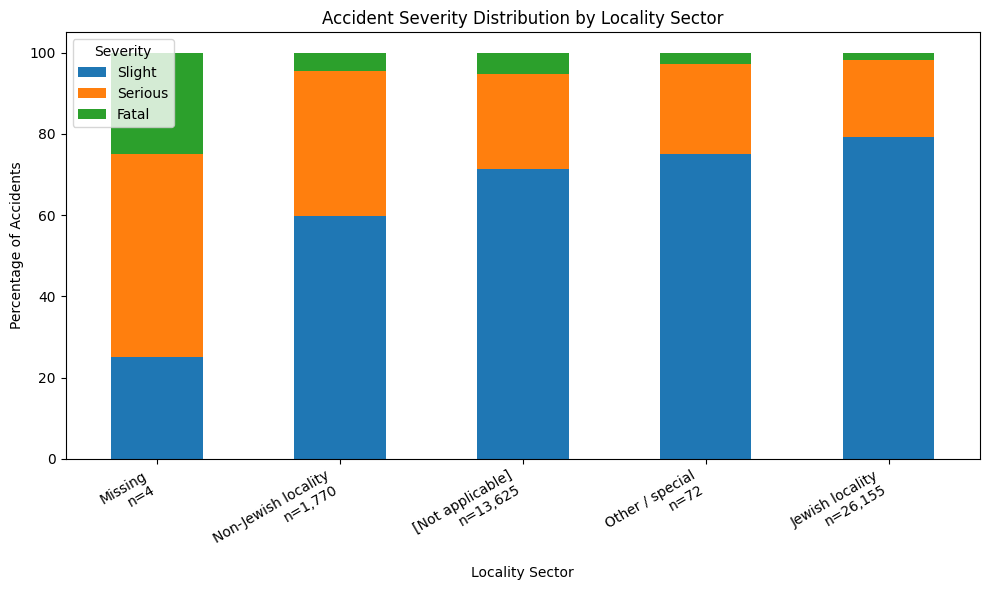

In [100]:
plot_severity_by_feature(
    train_df,
    "LOCALITY_SECTOR",
    "Locality Sector"
)

In [101]:
feature_summary(
    train_df[
        train_df["LOCALITY_SECTOR"].isin(
            [
                "Jewish locality",
                "Non-Jewish locality"
            ]
        )
    ],
    "LOCALITY_SECTOR"
)

,count,subset_percentage,fatal_rate,serious_rate,slight_rate,severe_rate
feature,,,,,,
Non-Jewish locality,1770,6.34,4.58,35.71,59.72,40.28
Jewish locality,26155,93.66,1.77,19.02,79.21,20.79


In [102]:
sector_size_summary = (
    train_df[
        train_df["LOCALITY_SECTOR"].isin(
            ["Jewish locality", "Non-Jewish locality"]
        )
    ]
    .groupby(
        ["LOCALITY_SECTOR", "LOCALITY_SIZE"]
    )
    .agg(
        count=("HUMRAT_TEUNA", "size"),
        fatal_rate=(
            "HUMRAT_TEUNA",
            lambda x: (x == 1).mean() * 100
        ),
        serious_rate=(
            "HUMRAT_TEUNA",
            lambda x: (x == 2).mean() * 100
        )
    )
    .reset_index()
)

sector_size_summary["severe_rate"] = (
    sector_size_summary["fatal_rate"]
    + sector_size_summary["serious_rate"]
)

sector_size_summary[
    [
        "LOCALITY_SECTOR",
        "LOCALITY_SIZE",
        "count",
        "fatal_rate",
        "serious_rate",
        "severe_rate"
    ]
].round(2)

,LOCALITY_SECTOR,LOCALITY_SIZE,count,fatal_rate,serious_rate,severe_rate
0,Jewish locality,"10,000-19,999",267,3.00,22.47,25.47
1,Jewish locality,"100,000-199,999",5082,1.30,17.10,18.40
2,Jewish locality,"2,000-4,999",115,2.61,26.09,28.70
3,Jewish locality,"20,000-49,999",2865,1.43,19.55,20.98
4,Jewish locality,"200,000-499,999",11226,1.97,18.20,20.17
5,Jewish locality,"5,000-9,999",147,0.68,25.17,25.85
6,Jewish locality,"50,000-99,999",2833,1.94,18.88,20.83
7,Jewish locality,"500,000+",3200,1.56,20.81,22.38
8,Jewish locality,Other,420,4.52,41.43,45.95
9,Non-Jewish locality,"10,000-19,999",453,5.30,34.44,39.74


#### Observations

`LOCALITY_SECTOR` shows a strong relationship with accident severity.

The severe accident rate is approximately:

- `Jewish locality`: 21%
- `Non-Jewish locality`: 40%

The difference remains substantial when comparing localities within similar population ranges.

For example:

- `20,000-49,999 residents`: approximately 21% vs. 37%
- `10,000-19,999 residents`: approximately 25% vs. 40%
- `5,000-9,999 residents`: approximately 26% vs. 38%

This suggests that the relationship is not explained by locality size alone.

Both `LOCALITY_SECTOR` and `LOCALITY_SIZE` appear to contain potentially useful predictive information and will be retained as candidate features for modeling.

The observed relationship should not be interpreted causally. `LOCALITY_SECTOR` may capture differences in road infrastructure, road types, permitted speeds, geographic location, traffic patterns, and other characteristics that also affect accident severity.

### STATUS_IGUN (Geocoding Status)

In [103]:
feature_summary(
    train_df,
    "STATUS_IGUN"
)

,count,subset_percentage,fatal_rate,serious_rate,slight_rate,severe_rate
feature,,,,,,
Not geocoded,92,0.22,13.04,57.61,29.35,70.65
Kilometer marker center,33,0.08,9.09,36.36,54.55,45.45
Locality center,2256,5.42,3.68,40.29,56.03,43.97
Road center,6770,16.26,2.26,26.37,71.37,28.63
Precise geocoding,32475,78.02,3.17,18.61,78.23,21.77


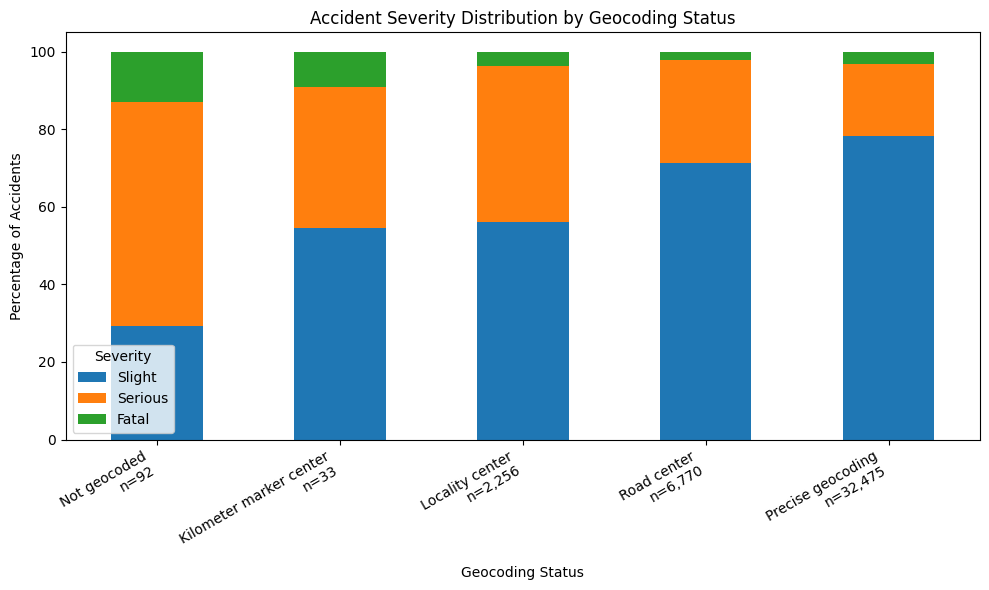

In [104]:
plot_severity_by_feature(
    train_df,
    "STATUS_IGUN",
    "Geocoding Status"
)

The relationship between `STATUS_IGUN` and `ROAD_IS_URBAN` is examined to determine whether geocoding status primarily reflects the recording process rather than an accident characteristic.

In [105]:
pd.crosstab(
    train_df["STATUS_IGUN"],
    train_df["ROAD_IS_URBAN"],
    normalize="index"
).round(3) * 100

ROAD_IS_URBAN,False,True
STATUS_IGUN,,
1,41.1,58.9
2,0.0,100.0
3,2.6,97.4
4,100.0,0.0
9,85.9,14.1


The results show a strong relationship between `STATUS_IGUN` and `ROAD_IS_URBAN`, which suggests that `STATUS_IGUN` may partly reflect geographic or data-recording characteristics rather than information about the accident itself.

#### Observations

`STATUS_IGUN` is strongly related to whether the accident occurred on an urban or non-urban road.

For example:

- `Locality center` occurs only in urban accidents.
- `Road center` occurs almost exclusively in urban accidents.
- `Kilometer marker center` occurs only in non-urban accidents.
- `Not geocoded` occurs mostly in non-urban accidents.

This suggests that part of the relationship between `STATUS_IGUN` and accident severity is likely explained by road location and data collection characteristics rather than by the accident itself.

Since `STATUS_IGUN` describes the geocoding process and overlaps substantially with geographic features such as `ROAD_IS_URBAN`, it will be considered a strong candidate for removal during modeling.

Model performance with and without this feature can be compared during cross-validation.

### THUM_GEOGRAFI

In [106]:
feature_summary(
    train_df,
    "THUM_GEOGRAFI"
)

,count,subset_percentage,fatal_rate,serious_rate,slight_rate,severe_rate
feature,,,,,,
Judea and Samaria,1615,3.88,7.31,24.09,68.61,31.39
"Israel, excluding Judea and Samaria",40011,96.12,2.90,21.02,76.07,23.93


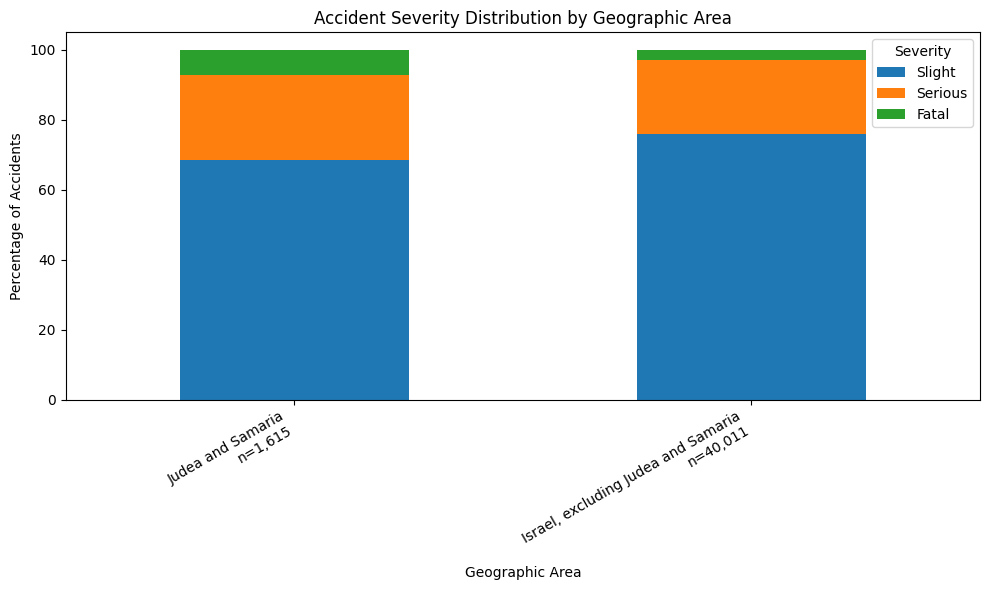

In [107]:
plot_severity_by_feature(
    train_df,
    "THUM_GEOGRAFI",
    "Geographic Area"
)

#### Relationship with District

`THUM_GEOGRAFI` distinguishes between Israel excluding Judea and Samaria and the Judea and Samaria Area.

Since `MAHOZ` already contains a separate `Judea and Samaria Area` category, `THUM_GEOGRAFI` may contain information that is already represented by the district feature.

The two features are compared to determine whether `THUM_GEOGRAFI` contains information beyond `MAHOZ`.

In [108]:
comparison = pd.crosstab(
    train_df["THUM_GEOGRAFI"].map(
        VALUE_LABELS["THUM_GEOGRAFI"]
    ),
    train_df["MAHOZ"].map(
        VALUE_LABELS["MAHOZ"]
    )
)

comparison

MAHOZ,Central District,Haifa District,Jerusalem District,Judea and Samaria Area,Northern District,Southern District,Tel Aviv District,Unknown District
THUM_GEOGRAFI,,,,,,,,
"Israel, excluding Judea and Samaria",8955,5793,3959,122,6381,4677,10043,81
Judea and Samaria,9,9,16,1559,18,2,0,2


#### Observations

`THUM_GEOGRAFI` shows a relationship with accident severity.

Accidents in the `Judea and Samaria` category have a severe accident rate of approximately 31%, compared with approximately 24% for the rest of Israel.

However, `THUM_GEOGRAFI` overlaps strongly with `MAHOZ`.

Approximately 97% of accidents classified as `Judea and Samaria` by `THUM_GEOGRAFI` are also classified as `Judea and Samaria Area` by `MAHOZ`.

The two features are not completely identical, but they contain largely overlapping geographic information.

Since more detailed geographic features such as `MAHOZ`, `NAFA`, and `EZOR_TIVI` are already available, `THUM_GEOGRAFI` is likely to provide limited additional information.

Therefore, `THUM_GEOGRAFI` will be considered a candidate for removal during modeling. Its contribution can be evaluated through cross-validation.

### SEMEL_YISHUV (Locality Code)

In [109]:
train_df["SEMEL_YISHUV"].nunique(dropna=False)

555

In [110]:
locality_counts = (
    train_df["SEMEL_YISHUV"]
    .value_counts()
)

pd.Series({
    "unique_localities": len(locality_counts),
    "1 accident": (locality_counts == 1).sum(),
    "< 5 accidents": (locality_counts < 5).sum(),
    "< 20 accidents": (locality_counts < 20).sum(),
    "< 50 accidents": (locality_counts < 50).sum(),
})

unique_localities    555
1 accident           223
< 5 accidents        372
< 20 accidents       446
< 50 accidents       486
dtype: int64

In [111]:
pd.crosstab(
    train_df["SEMEL_YISHUV"],
    train_df["ROAD_IS_URBAN"]
).loc[[0]]

ROAD_IS_URBAN,False,True
SEMEL_YISHUV,,
0,13625,4


#### Observations

`SEMEL_YISHUV` represents the specific locality in which the accident occurred.

The feature has high cardinality, with 555 distinct values, and its distribution is highly sparse:

- Approximately 40% of locality codes appear only once.
- Approximately 67% appear fewer than 5 times.
- Approximately 80% appear fewer than 20 times.
- Approximately 88% appear fewer than 50 times.

The value `0` appears almost exclusively in non-urban accidents and corresponds closely to cases where locality information is not applicable. However, a small number of urban records also use this value.

Although a specific locality may contain predictive geographic information, the high cardinality and sparsity create a substantial risk of overfitting and poor generalization to unseen or rarely observed localities.

More stable geographic representations are already available through `MAHOZ`, `NAFA`, `EZOR_TIVI`, `LOCALITY_SIZE`, `LOCALITY_SECTOR`, and other derived features.

Therefore, `SEMEL_YISHUV` will not be used as a standard one-hot encoded categorical feature. It will be retained as a candidate for models that can handle high-cardinality categorical variables directly, and its contribution will be evaluated through temporal cross-validation.

### REHOV1 (Street 1)

In [112]:
train_df["REHOV1"].nunique(dropna=False)

2053

In [113]:
train_df["REHOV1"].value_counts(
    dropna=False
).head(20)

REHOV1
NaN       15566
101.0       318
103.0       203
301.0       183
1011.0      159
304.0       157
221.0       146
1994.0      144
105.0       142
201.0       138
1714.0      138
108.0       137
210.0       137
102.0       133
112.0       133
107.0       125
205.0       125
180.0       122
1555.0      120
404.0       119
Name: count, dtype: int64

In [114]:
pd.crosstab(
    train_df["SUG_DEREH"],
    train_df["REHOV1"].isna(),
    margins=True
)

REHOV1,False,True,All
SUG_DEREH,,,
1,13385,72,13457
2,12675,1869,14544
3,0,5284,5284
4,0,8341,8341
All,26060,15566,41626


In [115]:
street_locality_counts = (
    train_df
    .dropna(subset=["REHOV1"])
    .groupby("REHOV1")["SEMEL_YISHUV"]
    .nunique()
)

pd.Series({
    "street_codes": len(street_locality_counts),
    "used_in_1_locality": (
        street_locality_counts == 1
    ).sum(),
    "used_in_multiple_localities": (
        street_locality_counts > 1
    ).sum(),
    "max_localities_per_code": (
        street_locality_counts.max()
    ),
})

street_codes                   2052
used_in_1_locality             1066
used_in_multiple_localities     986
max_localities_per_code          70
dtype: int64

#### Observations

`REHOV1` has high cardinality, with 2,052 distinct street codes.

Street codes are not globally unique. Almost half of the codes appear in more than one locality, and some codes are reused across as many as 70 different localities.

Therefore, `REHOV1` alone does not uniquely identify a street. A unique street representation would require combining it with `SEMEL_YISHUV`, which would further increase cardinality and sparsity.

Since more stable geographic features are already available, using the raw street identifier is likely to introduce substantial overfitting and poor generalization to future data.

`REHOV1` will therefore be considered a strong candidate for removal.

### REHOV2 (Secondary Street)

In [116]:
train_df["REHOV2"].nunique(dropna=False)

1750

In [117]:
train_df["REHOV2"].value_counts(
    dropna=False
).head(20)

REHOV2
NaN       28546
101.0        79
301.0        73
205.0        68
404.0        63
210.0        61
1011.0       60
309.0        59
103.0        53
202.0        53
108.0        52
508.0        50
201.0        50
116.0        49
180.0        49
701.0        48
503.0        47
302.0        47
609.0        46
1555.0       46
Name: count, dtype: int64

In [118]:
pd.crosstab(
    train_df["SUG_DEREH"],
    train_df["REHOV2"].isna(),
    margins=True
)

REHOV2,False,True,All
SUG_DEREH,,,
1,13080,377,13457
2,0,14544,14544
3,0,5284,5284
4,0,8341,8341
All,13080,28546,41626


In [119]:
street2_counts = (
    train_df["REHOV2"]
    .value_counts(dropna=True)
)

pd.Series({
    "unique_values": len(street2_counts),
    "1 accident": (street2_counts == 1).sum(),
    "< 5 accidents": (street2_counts < 5).sum(),
    "< 20 accidents": (street2_counts < 20).sum(),
    "< 50 accidents": (street2_counts < 50).sum(),
})

unique_values     1749
1 accident         437
< 5 accidents      955
< 20 accidents    1598
< 50 accidents    1737
dtype: int64

#### Observations

`REHOV2` represents the second street code and is relevant almost exclusively to urban intersection accidents.

Most missing values are structural, since the feature is not applicable to urban non-intersection and non-urban accidents.

The feature has very high cardinality, with 1,749 distinct values, and is highly sparse:

- 437 street codes appear only once.
- 955 appear fewer than 5 times.
- 1,598 appear fewer than 20 times.

As with `REHOV1`, street codes are identifiers rather than stable descriptive features. A unique street representation would require combining the street code with `SEMEL_YISHUV`, further increasing cardinality and sparsity.

Therefore, `REHOV2` is a strong candidate for removal due to the high risk of overfitting and poor generalization to future data.

### BAYIT (House Number)

In [120]:
train_df["BAYIT"].nunique(dropna=False)

267

In [121]:
train_df["BAYIT"].value_counts(
    dropna=False
).head(20)

BAYIT
NaN       27082
9999.0     7743
1.0         280
2.0         247
3.0         185
10.0        184
5.0         181
4.0         180
11.0        167
7.0         165
6.0         163
8.0         143
12.0        134
9.0         131
15.0        128
14.0        122
13.0        118
18.0        117
20.0        103
22.0        103
Name: count, dtype: int64

In [122]:
pd.crosstab(
    train_df["SUG_DEREH"],
    train_df["BAYIT"].isna(),
    margins=True
)

BAYIT,False,True,All
SUG_DEREH,,,
1,0,13457,13457
2,14544,0,14544
3,0,5284,5284
4,0,8341,8341
All,14544,27082,41626


In [123]:
train_df["BAYIT"].value_counts(
    dropna=False
).head(30)

BAYIT
NaN       27082
9999.0     7743
1.0         280
2.0         247
3.0         185
10.0        184
5.0         181
4.0         180
11.0        167
7.0         165
6.0         163
8.0         143
12.0        134
9.0         131
15.0        128
14.0        122
13.0        118
18.0        117
20.0        103
22.0        103
19.0        101
17.0         99
21.0         98
16.0         96
30.0         92
25.0         87
24.0         84
26.0         80
32.0         76
27.0         74
Name: count, dtype: int64

#### Observations

`BAYIT` represents the house number associated with the accident location.

The feature is applicable exclusively to `Urban, not at intersection` accidents. All other road types contain missing values, indicating that these missing values are structural rather than a data-quality issue.

Within applicable records, the value `9999` appears in approximately 53% of cases and appears to represent a special or unavailable house-number value rather than an actual address.

House numbers are location identifiers rather than meaningful numeric characteristics of an accident. Their numeric magnitude has no meaningful relationship with accident severity, and treating them as categorical identifiers would introduce unnecessary cardinality and location-specific overfitting.

Therefore, `BAYIT` is a strong candidate for removal.

### ZOMET_IRONI (Urban Intersection Identifier)

In [124]:
train_df["ZOMET_IRONI"].nunique(dropna=False)

5178

In [125]:
train_df["ZOMET_IRONI"].value_counts(
    dropna=False
).head(20)

ZOMET_IRONI
NaN           28546
26510545.0       48
67630011.0       38
14290714.0       33
12950556.0       30
50001.0          30
360712.0         29
60007.0          29
92872453.0       27
17730555.0       26
28040411.0       26
24530725.0       26
28440715.0       23
12240121.0       22
15680110.0       21
11400522.0       21
92870656.0       20
8670001.0        20
92871279.0       20
20700111.0       19
Name: count, dtype: int64

In [126]:
pd.crosstab(
    train_df["SUG_DEREH"],
    train_df["ZOMET_IRONI"].isna(),
    margins=True
)

ZOMET_IRONI,False,True,All
SUG_DEREH,,,
1,13080,377,13457
2,0,14544,14544
3,0,5284,5284
4,0,8341,8341
All,13080,28546,41626


#### Sparsity

In [127]:
intersection_counts = (
    train_df["ZOMET_IRONI"]
    .value_counts(dropna=True)
)

pd.Series({
    "unique_values": len(intersection_counts),
    "1 accident": (intersection_counts == 1).sum(),
    "< 5 accidents": (intersection_counts < 5).sum(),
    "< 20 accidents": (intersection_counts < 20).sum(),
    "< 50 accidents": (intersection_counts < 50).sum(),
})

unique_values     5177
1 accident        2696
< 5 accidents     4474
< 20 accidents    5159
< 50 accidents    5177
dtype: int64

#### Relationship with Locality

In [128]:
intersection_locality_counts = (
    train_df
    .dropna(subset=["ZOMET_IRONI"])
    .groupby("ZOMET_IRONI")["SEMEL_YISHUV"]
    .nunique()
)

pd.Series({
    "intersection_codes": len(intersection_locality_counts),
    "used_in_1_locality": (
        intersection_locality_counts == 1
    ).sum(),
    "used_in_multiple_localities": (
        intersection_locality_counts > 1
    ).sum(),
    "max_localities_per_code": (
        intersection_locality_counts.max()
    ),
})

intersection_codes             5177
used_in_1_locality             4828
used_in_multiple_localities     349
max_localities_per_code          15
dtype: int64

#### Observations

`ZOMET_IRONI` represents the urban intersection identifier and is applicable only to `Urban, at intersection` accidents.

Most missing values are structural, since the feature is not applicable to other road types.

The feature has extremely high cardinality, with 5,177 distinct intersection codes, and is highly sparse:

- Approximately 52% of intersection codes appear only once.
- Approximately 86% appear fewer than 5 times.
- Almost all intersection codes appear fewer than 20 times.

Most intersection codes are associated with a single locality, although some codes are reused across multiple localities.

Because the feature primarily acts as a highly specific location identifier and contains extremely sparse categories, it presents a substantial risk of overfitting and poor generalization to future data.

Therefore, `ZOMET_IRONI` is a strong candidate for removal.

### KVISH1

In [129]:
train_df["KVISH1"].nunique(dropna=False)

525

In [130]:
train_df["KVISH1"].value_counts(
    dropna=False
).head(30)

KVISH1
NaN      28075
4.0       1437
20.0       648
40.0       565
65.0       448
70.0       447
60.0       388
6.0        372
85.0       356
90.0       342
1.0        316
444.0      306
2.0        298
25.0       272
5.0        236
44.0       227
75.0       205
89.0       184
3.0        154
805.0      149
781.0      145
57.0       138
79.0       133
35.0       129
22.0       127
77.0       108
55.0       108
31.0       103
784.0       98
531.0       94
Name: count, dtype: int64

#### Applicability

In [131]:
pd.crosstab(
    train_df["SUG_DEREH"],
    train_df["KVISH1"].isna(),
    margins=True
)

KVISH1,False,True,All
SUG_DEREH,,,
1,0,13457,13457
2,0,14544,14544
3,5284,0,5284
4,8267,74,8341
All,13551,28075,41626


#### Sparsity

In [132]:
road_counts = (
    train_df["KVISH1"]
    .value_counts(dropna=True)
)

pd.Series({
    "unique_roads": len(road_counts),
    "1 accident": (road_counts == 1).sum(),
    "< 5 accidents": (road_counts < 5).sum(),
    "< 20 accidents": (road_counts < 20).sum(),
    "< 50 accidents": (road_counts < 50).sum(),
})

unique_roads      524
1 accident        146
< 5 accidents     287
< 20 accidents    417
< 50 accidents    473
dtype: int64

In [133]:
road_summary = feature_summary(
    train_df,
    "KVISH1"
)

road_summary[
    road_summary["count"] >= 50
].head(30)

,count,subset_percentage,fatal_rate,serious_rate,slight_rate,severe_rate
feature,,,,,,
431.0,93,0.22,8.60,46.24,45.16,54.84
31.0,103,0.25,7.77,44.66,47.57,52.43
899.0,60,0.14,11.67,35.00,53.33,46.67
1.0,316,0.76,10.76,35.76,53.48,46.52
6.0,372,0.89,11.29,34.41,54.30,45.70
471.0,87,0.21,10.34,34.48,55.17,44.83
443.0,89,0.21,4.49,34.83,60.67,39.33
232.0,79,0.19,6.33,32.91,60.76,39.24
38.0,52,0.12,3.85,34.62,61.54,38.46


In [134]:
frequent_roads = (
    train_df["KVISH1"]
    .value_counts(dropna=True)
    .loc[lambda counts: counts >= 50]
    .index
)

frequent_road_severity = (
    train_df[train_df["KVISH1"].isin(frequent_roads)]
    .groupby(["KVISH1", "SHNAT_TEUNA"])
    .agg(
        count=("HUMRAT_TEUNA", "size"),
        severe_rate=(
            "HUMRAT_TEUNA",
            lambda x: x.isin([1, 2]).mean() * 100
        )
    )
    .reset_index()
)

year_severity = (
    train_df
    .assign(
        severe=lambda df: df["HUMRAT_TEUNA"].isin([1, 2])
    )
    .groupby("SHNAT_TEUNA")["severe"]
    .mean()
    .mul(100)
)

frequent_road_severity["year_severe_rate"] = (
    frequent_road_severity["SHNAT_TEUNA"]
    .map(year_severity)
)

frequent_road_severity["vs_year_baseline"] = (
    frequent_road_severity["severe_rate"]
    - frequent_road_severity["year_severe_rate"]
)

(
    frequent_road_severity[
        frequent_road_severity["KVISH1"].isin(
            [1, 2, 4, 5, 6, 40, 90]
        )
    ]
    .pivot(
        index="KVISH1",
        columns="SHNAT_TEUNA",
        values="vs_year_baseline"
    )
    .round(2)
)

SHNAT_TEUNA,2020,2021,2022,2023
KVISH1,,,,
1.0,15.13,16.34,25.68,27.52
2.0,13.17,12.39,15.14,13.29
4.0,2.54,4.84,-0.23,-0.68
5.0,6.62,2.98,11.73,-1.08
6.0,16.62,19.65,23.09,24.73
40.0,2.77,8.70,3.74,6.48
90.0,8.04,12.07,6.32,21.29


#### Observations

`KVISH1` identifies the primary road in non-urban accidents.

The feature has moderately high cardinality, but several roads contain substantial numbers of observations and appear consistently across all training years.

When comparing each road's severe accident rate with the overall severe accident rate of the same year, several well-represented roads maintain a relatively stable difference from the yearly baseline.

For example, roads such as `1`, `2`, and `6` remain consistently above the annual severe accident baseline across 2020-2023, while road `4` remains much closer to the yearly average.

This suggests that `KVISH1` may capture persistent road-specific characteristics rather than only reflecting the overall temporal increase in accident severity.

The feature will therefore be retained as a modeling candidate. Sparse road categories may require appropriate categorical handling, and the final contribution of the feature will be evaluated using temporal cross-validation.

### KVISH2

In [135]:
train_df["KVISH2"].nunique(dropna=False)

480

In [136]:
train_df["KVISH2"].value_counts(
    dropna=False
).head(30)

KVISH2
NaN      28276
0.0       9863
40.0        97
5.0         96
6.0         86
4.0         85
85.0        75
75.0        69
79.0        60
44.0        57
531.0       54
22.0        51
471.0       49
57.0        48
77.0        46
412.0       45
60.0        45
2.0         45
65.0        45
781.0       42
70.0        40
461.0       35
232.0       33
431.0       31
20.0        31
444.0       30
805.0       27
1.0         27
722.0       26
482.0       25
Name: count, dtype: int64

In [137]:
pd.crosstab(
    train_df["SUG_DEREH"],
    train_df["KVISH2"].isna(),
    margins=True
)

KVISH2,False,True,All
SUG_DEREH,,,
1,0,13457,13457
2,0,14544,14544
3,5233,51,5284
4,8117,224,8341
All,13350,28276,41626


In [138]:
road2_counts = (
    train_df["KVISH2"]
    .value_counts(dropna=True)
)

pd.Series({
    "unique_roads": len(road2_counts),
    "1 accident": (road2_counts == 1).sum(),
    "< 5 accidents": (road2_counts < 5).sum(),
    "< 20 accidents": (road2_counts < 20).sum(),
    "< 50 accidents": (road2_counts < 50).sum(),
})

unique_roads      479
1 accident        135
< 5 accidents     287
< 20 accidents    444
< 50 accidents    468
dtype: int64

In [139]:
road2_summary = feature_summary(
    train_df,
    "KVISH2"
)

road2_summary[
    road2_summary["count"] >= 30
].head(30)

,count,subset_percentage,fatal_rate,serious_rate,slight_rate,severe_rate
feature,,,,,,
431.0,31,0.07,6.45,38.71,54.84,45.16
412.0,45,0.11,6.67,37.78,55.56,44.44
0.0,9863,23.69,6.32,25.36,68.33,31.67
20.0,31,0.07,0.00,29.03,70.97,29.03
4.0,85,0.20,1.18,25.88,72.94,27.06
471.0,49,0.12,0.00,26.53,73.47,26.53
65.0,45,0.11,6.67,17.78,75.56,24.44
444.0,30,0.07,3.33,20.00,76.67,23.33
44.0,57,0.14,1.75,21.05,77.19,22.81


In [140]:
pd.crosstab(
    train_df["SUG_DEREH"],
    train_df["KVISH2"].eq(0),
    margins=True
)

KVISH2,False,True,All
SUG_DEREH,,,
1,13457,0,13457
2,14544,0,14544
3,3538,1746,5284
4,224,8117,8341
All,31763,9863,41626


In [141]:
train_df.loc[
    train_df["SUG_DEREH"] == 3,
    "KVISH2"
].value_counts(dropna=False).head(30)

KVISH2
0.0      1746
40.0       97
5.0        96
6.0        86
4.0        85
85.0       75
75.0       69
79.0       60
44.0       57
531.0      54
NaN        51
22.0       51
471.0      49
57.0       48
77.0       46
412.0      45
60.0       45
2.0        45
65.0       45
781.0      42
70.0       40
461.0      35
232.0      33
431.0      31
20.0       31
444.0      30
805.0      27
1.0        27
722.0      26
482.0      25
Name: count, dtype: int64

In [142]:
kvish2_valid = train_df[
    (train_df["SUG_DEREH"] == 3) &
    train_df["KVISH2"].notna() &
    (train_df["KVISH2"] != 0)
]

road2_summary = feature_summary(
    kvish2_valid,
    "KVISH2"
)

road2_summary[
    road2_summary["count"] >= 30
].head(30)

,count,subset_percentage,fatal_rate,serious_rate,slight_rate,severe_rate
feature,,,,,,
431.0,31,0.89,6.45,38.71,54.84,45.16
412.0,45,1.29,6.67,37.78,55.56,44.44
20.0,31,0.89,0.00,29.03,70.97,29.03
4.0,85,2.44,1.18,25.88,72.94,27.06
471.0,49,1.41,0.00,26.53,73.47,26.53
65.0,45,1.29,6.67,17.78,75.56,24.44
444.0,30,0.86,3.33,20.00,76.67,23.33
44.0,57,1.63,1.75,21.05,77.19,22.81
60.0,45,1.29,6.67,15.56,77.78,22.22


In [143]:
pd.Series({
    "non_urban_intersection_accidents":
        (train_df["SUG_DEREH"] == 3).sum(),

    "with_valid_KVISH2":
        len(kvish2_valid),

    "unique_valid_roads":
        kvish2_valid["KVISH2"].nunique(),

    "coverage_pct":
        len(kvish2_valid)
        / (train_df["SUG_DEREH"] == 3).sum()
        * 100
}).round(2)

non_urban_intersection_accidents    5284.00
with_valid_KVISH2                   3487.00
unique_valid_roads                   478.00
coverage_pct                          65.99
dtype: float64

#### Observations

`KVISH2` represents the secondary road associated with non-urban intersections.

The value `0` appears frequently and does not represent an actual road identifier. It is especially common in non-intersection accidents, where the second road is structurally not applicable.

Among non-urban intersection accidents, approximately 66% contain a valid non-zero `KVISH2` value.

The feature has 478 valid road identifiers and is considerably sparser than `KVISH1`. Most individual roads contain relatively few observations, although several better-represented roads show noticeable differences in accident severity.

Therefore, `KVISH2` may provide additional road-specific information, but the evidence is weaker than for `KVISH1`.

`KVISH2` will be retained as a secondary modeling candidate, and its incremental contribution beyond `KVISH1` will be evaluated using temporal cross-validation.

### KM (Road Kilometer Position)

The distribution and range of the raw kilometer values are examined first.

In [144]:
train_df["KM"].nunique(dropna=False)

2037

In [145]:
train_df["KM"].value_counts(
    dropna=False
).head(30)

KM
NaN       28099
0.0         261
10.0        101
12.0         85
20.0         84
2.0          84
6.0          82
30.0         78
2205.0       78
85.0         78
40.0         77
32.0         75
144.0        74
1.0          73
4.0          72
60.0         70
9.0          68
3.0          65
5.0          64
35.0         63
170.0        62
16.0         61
140.0        58
14.0         58
99.0         55
8.0          54
34.0         54
50.0         54
11.0         53
15.0         53
Name: count, dtype: int64

In [146]:
pd.crosstab(
    train_df["SUG_DEREH"],
    train_df["KM"].isna(),
    margins=True
)

KM,False,True,All
SUG_DEREH,,,
1,0,13457,13457
2,0,14544,14544
3,5281,3,5284
4,8246,95,8341
All,13527,28099,41626


In [147]:
train_df["KM"].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
)

count    13527.000000
mean       652.408147
std        901.858663
min       -267.000000
1%           0.000000
5%           6.000000
25%         68.000000
50%        215.000000
75%        832.500000
95%       2535.400000
99%       4204.000000
max       4751.000000
Name: KM, dtype: float64

#### Road and Kilometer Location Cardinality

In [148]:
road_km = (
    train_df[
        train_df["KVISH1"].notna()
        & train_df["KM"].notna()
    ]
    .groupby(["KVISH1", "KM"])
    .size()
)

pd.Series({
    "unique_road_km_locations": len(road_km),
    "locations_with_1_accident": (road_km == 1).sum(),
    "locations_with_less_than_5": (road_km < 5).sum(),
    "locations_with_20_or_more": (road_km >= 20).sum(),
})

unique_road_km_locations      7188
locations_with_1_accident     5130
locations_with_less_than_5    6695
locations_with_20_or_more       25
dtype: int64

#### Observations

`KM` represents the location along a non-urban road and is almost exclusively available for non-urban accidents.

The feature is meaningful only together with `KVISH1`, since the same kilometer value on different roads represents different locations.

However, the combination of road and kilometer is extremely sparse:

- Approximately 71% of road-kilometer locations appear only once.
- Approximately 93% appear fewer than 5 times.
- Only 25 road-kilometer locations appear at least 20 times.

This indicates that the raw feature primarily acts as a highly specific location identifier rather than a stable generalizable characteristic.

Using `KM` as a global numeric feature is also problematic because its meaning depends on the road.

Therefore, the raw `KM` feature is a strong candidate for removal. A coarser road-segment representation may be explored later if the kilometer encoding and appropriate segment size can be established.

Because `KM` is meaningful only within a road, it is combined with `KVISH1` using road-specific kilometer bins.

In [149]:
def road_segment_stats(df, bin_sizes=(10, 25, 50, 100)):
    data = df[
        df["KVISH1"].notna()
        & df["KM"].notna()
    ].copy()

    results = []

    for bin_size in bin_sizes:
        segment = (
            np.floor(data["KM"] / bin_size)
            * bin_size
        )

        counts = (
            pd.DataFrame({
                "road": data["KVISH1"],
                "segment": segment
            })
            .groupby(["road", "segment"])
            .size()
        )

        results.append({
            "bin_size": bin_size,
            "segments": len(counts),
            "segments_with_1_accident":
                (counts == 1).sum(),
            "segments_with_less_than_5":
                (counts < 5).sum(),
            "segments_with_20_or_more":
                (counts >= 20).sum(),
        })

    return pd.DataFrame(results)

#### Road Segment Bin Size

In [150]:
road_segment_stats(
    train_df,
    bin_sizes=[10, 25, 50, 100, 200]
)

,bin_size,segments,segments_with_1_accident,segments_with_less_than_5,segments_with_20_or_more
0,10,3613,1417,2798,72
1,25,2125,551,1282,133
2,50,1380,287,696,190
3,100,944,202,442,203
4,200,718,172,341,172


In [151]:
KM_BIN_SIZE = 100

train_df["ROAD_SEGMENT"] = np.where(
    train_df["KVISH1"].notna()
    & train_df["KM"].notna(),
    (
        train_df["KVISH1"].astype("Int64").astype(str)
        + "_"
        + (
            np.floor(train_df["KM"] / KM_BIN_SIZE)
            * KM_BIN_SIZE
        )
        .astype("Int64")
        .astype(str)
    ),
    pd.NA
)

In [152]:
segment_counts = (
    train_df["ROAD_SEGMENT"]
    .value_counts(dropna=True)
)

frequent_segments = (
    segment_counts[segment_counts >= 20]
    .index
)

segment_analysis = (
    train_df[
        train_df["ROAD_SEGMENT"].isin(
            frequent_segments
        )
    ]
    .assign(
        severe=lambda x:
            x["HUMRAT_TEUNA"].isin([1, 2])
    )
    .groupby(
        ["KVISH1", "ROAD_SEGMENT"]
    )
    .agg(
        count=("HUMRAT_TEUNA", "size"),
        severe_rate=("severe", "mean")
    )
    .reset_index()
)

segment_analysis["severe_rate"] *= 100

In [153]:
roads_with_multiple_segments = (
    segment_analysis
    .groupby("KVISH1")
    .size()
    .loc[lambda x: x >= 2]
    .index
)

segment_analysis[
    segment_analysis["KVISH1"].isin(
        roads_with_multiple_segments
    )
].sort_values(
    ["KVISH1", "severe_rate"],
    ascending=[True, False]
).head(50)

,KVISH1,ROAD_SEGMENT,count,severe_rate
3,1.0,1_400,39,61.538462
4,1.0,1_500,32,53.125000
2,1.0,1_300,21,52.380952
1,1.0,1_100,43,46.511628
7,1.0,1_800,22,45.454545
6,1.0,1_700,27,44.444444
0,1.0,1_0,77,41.558442
5,1.0,1_600,29,34.482759
9,2.0,2_300,63,52.380952
11,2.0,2_500,40,37.500000


In [154]:
segment_year_counts = (
    train_df
    .dropna(subset=["ROAD_SEGMENT"])
    .groupby(["ROAD_SEGMENT", "SHNAT_TEUNA"])
    .size()
    .unstack(fill_value=0)
)

segment_counts = train_df["ROAD_SEGMENT"].value_counts()
frequent_segments = segment_counts[segment_counts >= 20].index

frequent_segment_years = segment_year_counts.loc[
    segment_year_counts.index.intersection(frequent_segments)
]

pd.Series({
    "frequent_segments": len(frequent_segment_years),
    "present_all_4_years":
        ((frequent_segment_years > 0).sum(axis=1) == 4).sum(),
    "present_3_plus_years":
        ((frequent_segment_years > 0).sum(axis=1) >= 3).sum(),
})

frequent_segments       203
present_all_4_years     200
present_3_plus_years    203
dtype: int64

#### Segment-Level Severity

The derived `ROAD_SEGMENT` feature shows substantial variation in accident severity within the same road.

For example, different segments of road `4` show severe accident rates ranging from approximately 10% to more than 60%. Importantly, several of these differences occur in segments with substantial sample sizes rather than only in very small groups.

Similar within-road variation is visible for other major roads such as roads `1` and `6`.

This suggests that the road identifier alone does not capture all of the geographic information related to accident severity. Different sections of the same road may have substantially different severity profiles.

Combined with the strong temporal coverage of frequently observed segments, this provides evidence that `ROAD_SEGMENT` may offer useful predictive information beyond `KVISH1`.

The raw `KM` feature will therefore be removed as a standalone feature, while `ROAD_SEGMENT` will be retained as a strong modeling candidate.

During modeling, the following alternatives will be compared using temporal cross-validation:

- `KVISH1` only
- `ROAD_SEGMENT` only
- `KVISH1` and `ROAD_SEGMENT` together

### ZOMET_LO_IRONI

In [155]:
train_df["ZOMET_LO_IRONI"].nunique(dropna=False)

1251

In [156]:
train_df["ZOMET_LO_IRONI"].value_counts(
    dropna=False
).head(30)

ZOMET_LO_IRONI
NaN        36345
433.0         78
8052.0        53
1203.0        51
323.0         50
4050.0        46
9756.0        41
311.0         40
1209.0        37
4021.0        36
481.0         28
3698.0        28
4203.0        27
4198.0        27
8075.0        27
4063.0        27
313.0         27
9736.0        26
4188.0        25
8063.0        25
9456.0        23
10297.0       23
8017.0        23
1227.0        22
10295.0       21
867.0         20
4197.0        20
2043.0        20
4072.0        20
4048.0        20
Name: count, dtype: int64

In [157]:
nonurban_intersection_counts = (
    train_df["ZOMET_LO_IRONI"]
    .value_counts(dropna=True)
)

pd.Series({
    "unique_values": len(nonurban_intersection_counts),
    "1 accident": (
        nonurban_intersection_counts == 1
    ).sum(),
    "< 5 accidents": (
        nonurban_intersection_counts < 5
    ).sum(),
    "< 20 accidents": (
        nonurban_intersection_counts < 20
    ).sum(),
    "< 50 accidents": (
        nonurban_intersection_counts < 50
    ).sum(),
})

unique_values     1250
1 accident         480
< 5 accidents      889
< 20 accidents    1221
< 50 accidents    1246
dtype: int64

In [158]:
nonurban_intersection_summary = feature_summary(
    train_df,
    "ZOMET_LO_IRONI"
)

nonurban_intersection_summary[
    nonurban_intersection_summary["count"] >= 20
].head(30)

,count,subset_percentage,fatal_rate,serious_rate,slight_rate,severe_rate
feature,,,,,,
867.0,20,0.05,5.00,40.00,55.00,45.00
8075.0,27,0.06,0.00,25.93,74.07,25.93
[Missing],36345,87.31,3.20,21.93,74.88,25.12
311.0,40,0.10,2.50,22.50,75.00,25.00
3698.0,28,0.07,0.00,25.00,75.00,25.00
10295.0,21,0.05,0.00,23.81,76.19,23.81
8017.0,23,0.06,4.35,17.39,78.26,21.74
1209.0,37,0.09,0.00,21.62,78.38,21.62
4197.0,20,0.05,0.00,20.00,80.00,20.00


#### Observations

`ZOMET_LO_IRONI` identifies the specific non-urban intersection where the accident occurred.

The feature is applicable almost exclusively to non-urban intersection accidents, so most missing values are structural rather than data-quality issues.

However, the feature is highly sparse. Among 1,250 distinct intersection identifiers:

- approximately 38% appear only once,
- approximately 71% appear fewer than 5 times,
- approximately 98% appear fewer than 20 times,
- only 4 intersections appear at least 50 times.

Although some intersections show substantial differences in accident severity, most of these estimates are based on relatively small samples.

Since more stable road-level and derived road-segment features are already available, the raw intersection identifier is likely to introduce location-specific overfitting and poor temporal generalization.

Therefore, `ZOMET_LO_IRONI` is a strong candidate for removal.

### YEHIDA

In [159]:
train_df["YEHIDA"].nunique(dropna=False)

12

In [160]:
train_df["YEHIDA"].value_counts(
    dropna=False
).sort_index()

YEHIDA
11     2348
12     8140
14     1752
20    10360
33      228
34     2117
38     2476
41      820
43      795
51     5503
52     3035
61     4052
Name: count, dtype: int64

In [161]:
feature_summary(
    train_df,
    "YEHIDA"
)

,count,subset_percentage,fatal_rate,serious_rate,slight_rate,severe_rate
feature,,,,,,
Negev Area,2117,5.09,7.84,34.48,57.68,42.32
Judea Area,795,1.91,7.42,29.43,63.14,36.86
Shfela Area,3035,7.29,3.79,28.80,67.41,32.59
Valleys Area,1752,4.21,4.51,23.12,72.37,27.63
Lachish Area,2476,5.95,3.55,22.86,73.59,26.41
Samaria Area,820,1.97,7.20,18.90,73.90,26.10
Eilat Area,228,0.55,5.26,20.61,74.12,25.88
Jerusalem District,4052,9.73,2.22,22.43,75.35,24.65
Galilee Area,8140,19.56,2.86,19.57,77.57,22.43


`YEHIDA` is compared with `MAHOZ` to determine whether it provides additional geographic granularity.

In [162]:
pd.crosstab(
    train_df["YEHIDA"],
    train_df["MAHOZ"],
    margins=True
)

MAHOZ,1,2,3,4,5,6,7,9,All
YEHIDA,,,,,,,,,
11,0,19,2326,0,0,0,0,3,2348
12,0,4635,3451,16,0,6,1,31,8140
14,0,1726,5,2,0,0,3,16,1752
20,2,0,1,330,10023,2,0,2,10360
33,1,0,0,0,0,227,0,0,228
34,0,0,1,0,0,2105,3,8,2117
38,1,0,1,151,0,2314,1,8,2476
41,0,0,9,7,0,0,804,0,820
43,16,18,0,2,0,2,755,2,795


In [163]:
(
    train_df
    .groupby("YEHIDA")["MAHOZ"]
    .nunique()
    .sort_values()
)

YEHIDA
33    2
11    3
41    3
34    4
14    5
61    5
20    6
12    6
38    6
43    6
52    6
51    7
Name: MAHOZ, dtype: int64

In [164]:
yehida_within_district = (
    train_df
    .assign(
        severe=lambda x:
            x["HUMRAT_TEUNA"].isin([1, 2])
    )
    .groupby(["MAHOZ", "YEHIDA"])
    .agg(
        count=("HUMRAT_TEUNA", "size"),
        severe_rate=("severe", "mean")
    )
    .reset_index()
)

yehida_within_district["severe_rate"] *= 100

yehida_within_district[
    yehida_within_district["count"] >= 100
].sort_values(
    ["MAHOZ", "severe_rate"],
    ascending=[True, False]
)

,MAHOZ,YEHIDA,count,severe_rate
5,1,61,3940,24.467005
8,2,14,1726,27.114716
7,2,12,4635,21.769148
12,3,12,3451,22.891915
11,3,11,2326,18.959587
22,4,38,151,33.774834
26,4,52,2983,32.282937
21,4,20,330,25.757576
25,4,51,5468,21.488661
28,5,20,10023,19.335528


#### Observations

`YEHIDA` represents the police administrative area associated with the accident.

The feature contains only 12 categories, all with substantial sample sizes, and shows meaningful differences in accident severity.

Although `YEHIDA` is strongly related to geographic district (`MAHOZ`), the severity differences do not disappear when comparing police areas within the same district.

For example, substantial within-district variation is observed in the Central, Southern, and Judea and Samaria districts, including differences between groups containing hundreds or thousands of accidents.

This suggests that `YEHIDA` provides geographic granularity beyond `MAHOZ`.

However, some of this information may overlap with other geographic features such as `NAFA` and `EZOR_TIVI`.

Therefore, `YEHIDA` will be retained as a modeling candidate, and its incremental contribution will be evaluated using temporal cross-validation.

### HODESH_TEUNA


In [165]:
feature_summary(
    train_df,
    "HODESH_TEUNA"
)

,count,subset_percentage,fatal_rate,serious_rate,slight_rate,severe_rate
feature,,,,,,
10,3191,7.67,3.54,23.00,73.46,26.54
9,3243,7.79,3.21,22.60,74.19,25.81
4,3180,7.64,3.93,21.86,74.21,25.79
5,3651,8.77,3.10,22.68,74.23,25.77
6,3763,9.04,3.06,22.19,74.75,25.25
11,3320,7.98,2.86,22.38,74.76,25.24
8,3688,8.86,3.01,21.75,75.24,24.76
7,3682,8.85,2.88,21.18,75.94,24.06
3,3514,8.44,2.65,20.32,77.03,22.97


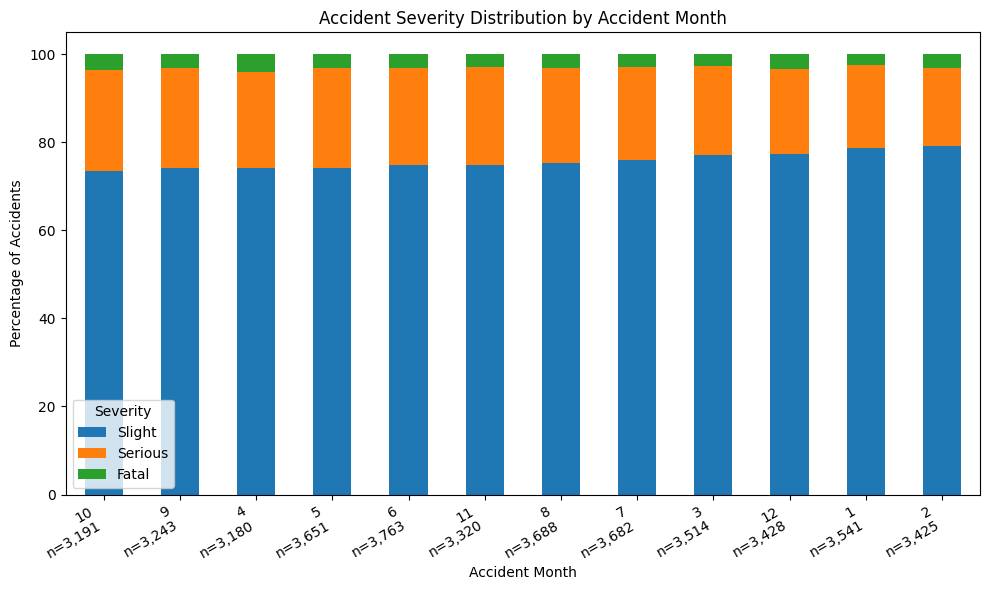

In [166]:
plot_severity_by_feature(
    train_df,
    "HODESH_TEUNA",
    "Accident Month"
)

#### Severity by Year and Month

In [167]:
monthly_yearly = (
    train_df
    .assign(
        severe=lambda df: df["HUMRAT_TEUNA"].isin([1, 2])
    )
    .groupby(["HODESH_TEUNA", "SHNAT_TEUNA"])
    .agg(
        count=("HUMRAT_TEUNA", "size"),
        severe_rate=("severe", "mean")
    )
    .reset_index()
)

monthly_yearly["severe_rate"] *= 100

monthly_severity_pivot = (
    monthly_yearly
    .pivot(
        index="HODESH_TEUNA",
        columns="SHNAT_TEUNA",
        values="severe_rate"
    )
)

monthly_severity_pivot

SHNAT_TEUNA,2020,2021,2022,2023
HODESH_TEUNA,,,,
1,17.647059,19.141531,20.771850,28.325123
2,17.967146,18.231441,21.549637,27.080395
3,21.902017,20.677036,22.257053,28.051948
4,20.833333,22.657744,26.213592,32.623169
5,22.707424,21.497326,29.543147,29.570552
6,21.119843,22.191272,26.345291,33.634021
7,19.483101,23.108384,25.027322,30.012771
8,20.790216,23.014257,25.443787,31.453634
9,23.266745,24.764151,25.485437,30.416667


In [168]:
year_baseline = (
    train_df
    .assign(
        severe=lambda x:
            x["HUMRAT_TEUNA"].isin([1, 2])
    )
    .groupby("SHNAT_TEUNA")["severe"]
    .mean()
    .mul(100)
)

monthly_yearly["year_baseline"] = (
    monthly_yearly["SHNAT_TEUNA"]
    .map(year_baseline)
)

monthly_yearly["vs_year_baseline"] = (
    monthly_yearly["severe_rate"]
    - monthly_yearly["year_baseline"]
)

monthly_deviation = (
    monthly_yearly
    .pivot(
        index="HODESH_TEUNA",
        columns="SHNAT_TEUNA",
        values="vs_year_baseline"
    )
)

monthly_deviation

SHNAT_TEUNA,2020,2021,2022,2023
HODESH_TEUNA,,,,
1,-2.517208,-2.876817,-4.593394,-2.381399
2,-2.197121,-3.786908,-3.815607,-3.626127
3,1.737750,-1.341313,-3.108191,-2.654574
4,0.669066,0.639395,0.848348,1.916647
5,2.543156,-0.521022,4.177903,-1.135970
6,0.955576,0.172923,0.980047,2.927499
7,-0.681166,1.090036,-0.337922,-0.693750
8,0.625949,0.995908,0.078543,0.747112
9,3.102478,2.745802,0.120193,-0.289855


#### Observations

`HODESH_TEUNA` shows a recurring seasonal relationship with accident severity.

Because the overall severe accident rate changes substantially across years, monthly severity was also compared against the baseline severity rate of each year.

Several patterns remain consistent across all four training years:

- January and February are consistently below the yearly severity baseline.
- April, June, August, and October are consistently above the yearly baseline.
- December is consistently below the yearly baseline.
- October shows the strongest positive deviation, particularly in 2022 and 2023.

This indicates that the monthly differences are not explained solely by the overall temporal trend in accident severity.

Therefore, `HODESH_TEUNA` will be retained as a modeling feature.

The month will initially be represented as a categorical feature. Cyclical sine/cosine encoding may also be evaluated during temporal cross-validation, although the observed pattern is not perfectly smooth across adjacent months.

### SHAA (Hour of accident)

In [169]:
train_df["SHAA"].nunique(dropna=False)

96

In [170]:
train_df["SHAA"].value_counts(
    dropna=False
).sort_index()

SHAA
1     244
2     208
3     242
4     149
5     214
     ... 
92    256
93    444
94    254
95    341
96    279
Name: count, Length: 96, dtype: int64

In [171]:
train_df["SHAA"].describe()

count    41626.000000
mean        56.871402
std         21.939303
min          1.000000
25%         41.000000
50%         59.000000
75%         73.000000
max         96.000000
Name: SHAA, dtype: float64

In [172]:
feature_summary(
    train_df,
    "SHAA"
)

,count,subset_percentage,fatal_rate,serious_rate,slight_rate,severe_rate
feature,,,,,,
17,88,0.21,11.36,31.82,56.82,43.18
19,72,0.17,15.28,26.39,58.33,41.67
16,65,0.16,12.31,29.23,58.46,41.54
10,76,0.18,5.26,35.53,59.21,40.79
22,92,0.22,6.52,33.70,59.78,40.22
...,...,...,...,...,...,...
88,269,0.65,3.35,15.99,80.67,19.33
70,545,1.31,3.30,15.96,80.73,19.27
36,350,0.84,1.71,17.43,80.86,19.14


`SHAA` contains 96 coded values, consistent with quarter-hour intervals across a 24-hour day. An `HOUR` representation is derived to evaluate a less granular and more interpretable time feature.

In [173]:
train_df["HOUR"] = (
    (train_df["SHAA"] - 1) // 4
).astype(int)

In [174]:
hour_summary = feature_summary(
    train_df,
    "HOUR"
)

hour_summary.sort_index()

,count,subset_percentage,fatal_rate,serious_rate,slight_rate,severe_rate
feature,,,,,,
0,843,2.03,5.22,23.01,71.77,28.23
1,576,1.38,5.56,23.26,71.18,28.82
2,415,1.00,6.51,26.75,66.75,33.25
3,311,0.75,7.40,29.58,63.02,36.98
4,247,0.59,12.55,27.94,59.51,40.49
5,511,1.23,6.46,29.55,63.99,36.01
6,992,2.38,4.13,24.09,71.77,28.23
7,1913,4.60,2.72,19.97,77.31,22.69
8,2063,4.96,1.89,18.32,79.79,20.21


#### Hourly Severity Across Years

In [175]:
hourly_yearly = (
    train_df
    .assign(
        severe=lambda x:
            x["HUMRAT_TEUNA"].isin([1, 2])
    )
    .groupby(["SHNAT_TEUNA", "HOUR"])
    .agg(
        count=("HUMRAT_TEUNA", "size"),
        severe_rate=("severe", "mean")
    )
    .reset_index()
)

hourly_yearly["severe_rate"] *= 100

hourly_severity_pivot = (
    hourly_yearly
    .pivot(
        index="HOUR",
        columns="SHNAT_TEUNA",
        values="severe_rate"
    )
)

hourly_severity_pivot

SHNAT_TEUNA,2020,2021,2022,2023
HOUR,,,,
0,23.428571,23.437500,32.126697,34.554974
1,25.477707,26.451613,27.333333,38.596491
2,29.213483,30.952381,30.392157,42.857143
3,33.333333,29.629630,39.784946,45.070423
4,31.372549,33.846154,48.684211,45.454545
5,26.016260,32.307692,37.903226,47.014925
6,23.214286,26.153846,32.217573,32.863850
7,18.201754,22.117202,23.770492,26.818182
8,18.518519,16.520211,20.833333,25.786164


<Axes: title={'center': 'Severe Accident Rate by Hour'}, xlabel='HOUR'>

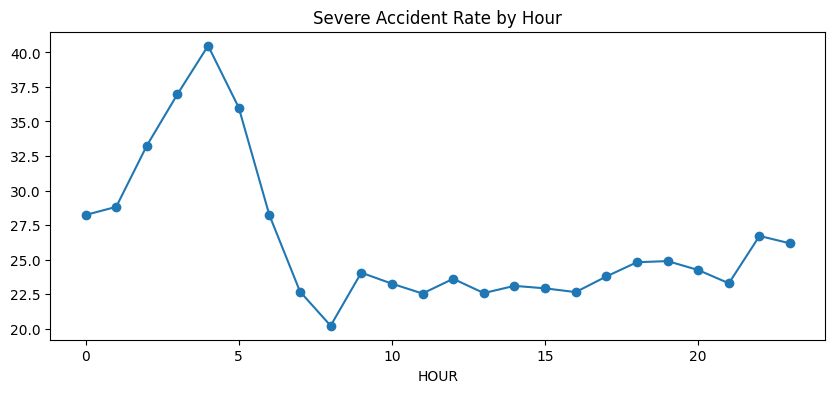

In [176]:
hour_plot = (
    train_df
    .assign(
        severe=lambda x:
            x["HUMRAT_TEUNA"].isin([1, 2])
    )
    .groupby("HOUR")
    .agg(
        count=("HUMRAT_TEUNA", "size"),
        severe_rate=("severe", "mean")
    )
)

hour_plot["severe_rate"] *= 100

hour_plot["severe_rate"].plot(
    marker="o",
    figsize=(10, 4),
    title="Severe Accident Rate by Hour"
)

#### Time-of-Day Representation

In [177]:
def derive_time_of_day(hour):
    if 0 <= hour <= 6:
        return "Night / Early Morning"
    if 7 <= hour <= 11:
        return "Morning"
    if 12 <= hour <= 17:
        return "Afternoon"
    if 18 <= hour <= 21:
        return "Evening"
    return "Late Evening"

train_df["TIME_OF_DAY"] = (
    train_df["HOUR"]
    .apply(derive_time_of_day)
)

In [178]:
feature_summary(
    train_df,
    "TIME_OF_DAY"
)

,count,subset_percentage,fatal_rate,serious_rate,slight_rate,severe_rate
feature,,,,,,
Night / Early Morning,3895,9.36,5.93,25.42,68.65,31.35
Late Evening,2763,6.64,4.13,22.33,73.54,26.46
Evening,8387,20.15,3.29,21.10,75.61,24.39
Afternoon,16426,39.46,2.50,20.60,76.90,23.10
Morning,10155,24.40,2.44,20.09,77.47,22.53


#### Time-of-Day Aggregation

To evaluate whether the hourly pattern can be represented more compactly, `HOUR` was grouped into broader time-of-day categories.

The resulting feature preserves a clear severity pattern:

- Night and early-morning accidents have the highest severe accident rate, above 31%.
- Late evening also shows an elevated rate.
- Morning and afternoon accidents have the lowest severe accident rates.

This confirms that time of day is meaningfully associated with accident severity.

However, the hourly analysis shows substantial variation within the broader groups, particularly during the night and early morning. Therefore, `HOUR` retains more detailed information.

`TIME_OF_DAY` will be retained as a derived modeling candidate, but `HOUR` remains the preferred time representation to evaluate first.

### SUG_YOM

In [179]:
feature_summary(
    train_df,
    "SUG_YOM"
)

,count,subset_percentage,fatal_rate,serious_rate,slight_rate,severe_rate
feature,,,,,,
Holiday,638,1.53,3.29,25.24,71.47,28.53
Holiday eve,889,2.14,3.26,24.63,72.10,27.90
Intermediate festival day,942,2.26,2.87,23.35,73.78,26.22
Other day,39157,94.07,3.07,20.94,75.99,24.01


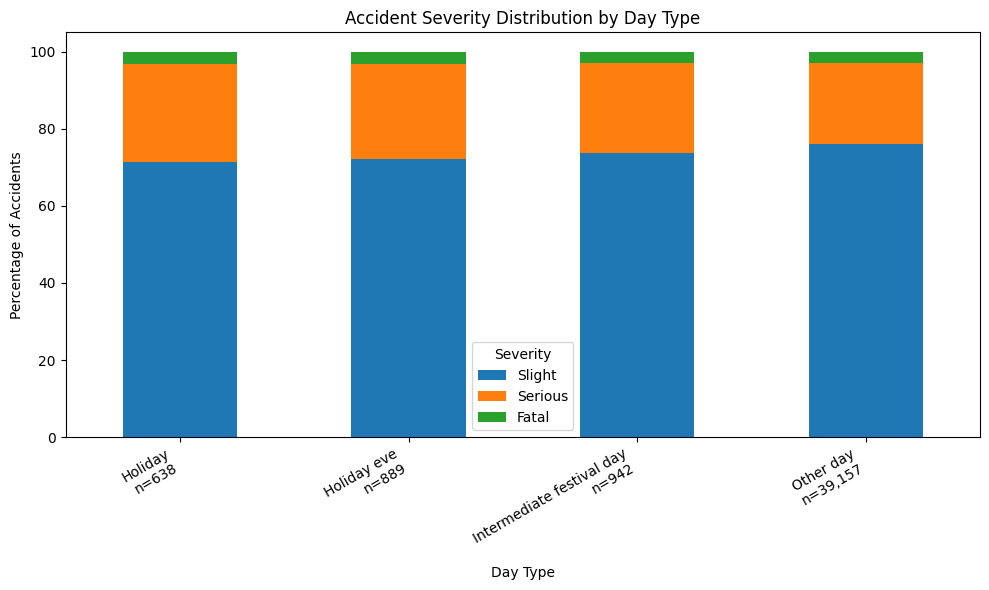

In [180]:
plot_severity_by_feature(
    train_df,
    "SUG_YOM",
    "Day Type"
)

In [181]:
sug_yom_labels = (
    train_df["SUG_YOM"]
    .map(VALUE_LABELS["SUG_YOM"])
)

pd.crosstab(
    sug_yom_labels,
    train_df["YOM_BASHAVUA"],
    margins=True
)

YOM_BASHAVUA,1,2,3,4,5,6,7,All
SUG_YOM,,,,,,,,
Holiday,55,78,98,87,126,86,108,638
Holiday eve,125,153,106,162,121,178,44,889
Intermediate festival day,142,171,152,202,143,88,44,942
Other day,6366,5823,5994,5854,6301,5256,3563,39157
All,6688,6225,6350,6305,6691,5608,3759,41626


In [182]:
sug_yom_yearly = (
    train_df
    .assign(
        severe=lambda x:
            x["HUMRAT_TEUNA"].isin([1, 2]),
        day_type=sug_yom_labels
    )
    .groupby(["SHNAT_TEUNA", "day_type"])
    .agg(
        count=("HUMRAT_TEUNA", "size"),
        severe_rate=("severe", "mean")
    )
    .reset_index()
)

sug_yom_yearly["severe_rate"] *= 100

sug_yom_yearly.pivot(
    index="day_type",
    columns="SHNAT_TEUNA",
    values="severe_rate"
)

SHNAT_TEUNA,2020,2021,2022,2023
day_type,,,,
Holiday,22.580645,25.641026,31.491713,34.057971
Holiday eve,24.056604,24.015748,29.047619,35.211268
Intermediate festival day,21.761658,23.778502,30.115830,29.508197
Other day,20.025226,21.855899,25.046135,30.561581


#### Observations

`SUG_YOM` distinguishes regular days from holidays, holiday eves, and intermediate festival days.

Special days show somewhat higher severe accident rates than regular days. The largest difference is observed for holidays, with a severe accident rate of approximately 28.5% compared with 24.0% on regular days.

Holiday and holiday-eve effects are reasonably consistent across the training years, suggesting that the difference is not explained entirely by the overall temporal severity trend.

However, the effect is moderate and special days represent only about 6% of the dataset.

`SUG_YOM` is also not redundant with `YOM_BASHAVUA`, since special days occur across different weekdays.

Therefore, `SUG_YOM` will be retained only as a secondary modeling candidate. Its incremental contribution will be evaluated using temporal cross-validation, and it may be removed if it does not improve model performance.

### YOM_LAYLA (Day / Night)

In [183]:
feature_summary(
    train_df,
    "YOM_LAYLA"
)

,count,subset_percentage,fatal_rate,serious_rate,slight_rate,severe_rate
feature,,,,,,
Night,14271,34.28,4.20,22.10,73.69,26.31
Day,27355,65.72,2.48,20.64,76.87,23.13


#### Relationship with Hour

In [184]:
yom_layla_labels = (
    train_df["YOM_LAYLA"]
    .map(VALUE_LABELS["YOM_LAYLA"])
    .fillna("[Missing]")
)

pd.crosstab(
    train_df["HOUR"],
    yom_layla_labels,
    normalize="index"
).mul(100).round(1)

YOM_LAYLA,Day,Night
HOUR,,
0,0.0,100.0
1,0.0,100.0
2,0.0,100.0
3,0.0,100.0
4,1.2,98.8
5,8.8,91.2
6,57.7,42.3
7,99.8,0.2
8,100.0,0.0


In [185]:
hour_daylight = (
    train_df
    .assign(
        daylight=yom_layla_labels,
        severe=lambda x:
            x["HUMRAT_TEUNA"].isin([1, 2])
    )
    .groupby(["HOUR", "daylight"])
    .agg(
        count=("HUMRAT_TEUNA", "size"),
        severe_rate=("severe", "mean")
    )
    .reset_index()
)

hour_daylight["severe_rate"] *= 100

hour_daylight[
    hour_daylight["count"] >= 100
].sort_values(
    ["HOUR", "daylight"]
)

,HOUR,daylight,count,severe_rate
0,0,Night,843,28.232503
1,1,Night,576,28.819444
2,2,Night,415,33.253012
3,3,Night,311,36.977492
5,4,Night,244,40.573770
7,5,Night,466,36.266094
8,6,Day,572,27.622378
9,6,Night,420,29.047619
10,7,Day,1910,22.670157
12,8,Day,2063,20.213282


#### Observations

`YOM_LAYLA` distinguishes accidents occurring during daylight and nighttime conditions.

Nighttime accidents have a somewhat higher severe accident rate than daytime accidents, approximately 26.3% compared with 23.1%.

However, the feature is strongly determined by `HOUR`. Most hours are almost exclusively classified as either day or night, with meaningful variation occurring only around sunrise and sunset.

Within these transition hours, the severity difference between day and night is small and inconsistent. In some hours nighttime accidents show higher severity, while in others the relationship is reversed or nearly absent.

Therefore, most of the information in `YOM_LAYLA` is already captured by the more detailed `HOUR` feature.

`YOM_LAYLA` is therefore a candidate for removal when `HOUR` is included in the model.

### YOM_BASHAVUA (Day of Week)

In [186]:
feature_summary(
    train_df,
    "YOM_BASHAVUA"
)

,count,subset_percentage,fatal_rate,serious_rate,slight_rate,severe_rate
feature,,,,,,
Friday,5608,13.47,3.57,23.48,72.95,27.05
Saturday,3759,9.03,3.91,23.04,73.05,26.95
Thursday,6691,16.07,3.29,20.89,75.82,24.18
Sunday,6688,16.07,2.60,20.90,76.50,23.50
Monday,6225,14.95,2.78,20.59,76.63,23.37
Wednesday,6305,15.15,2.90,20.22,76.88,23.12
Tuesday,6350,15.25,2.87,19.92,77.21,22.79


In [187]:
weekday_labels = (
    train_df["YOM_BASHAVUA"]
    .map(VALUE_LABELS["YOM_BASHAVUA"])
)

weekday_yearly = (
    train_df
    .assign(
        weekday=weekday_labels,
        severe=lambda x:
            x["HUMRAT_TEUNA"].isin([1, 2])
    )
    .groupby(["SHNAT_TEUNA", "weekday"])
    .agg(
        count=("HUMRAT_TEUNA", "size"),
        severe_rate=("severe", "mean")
    )
    .reset_index()
)

weekday_yearly["severe_rate"] *= 100

weekday_yearly.pivot(
    index="weekday",
    columns="SHNAT_TEUNA",
    values="severe_rate"
)

SHNAT_TEUNA,2020,2021,2022,2023
weekday,,,,
Friday,24.476534,24.131396,27.215632,33.637117
Monday,20.495356,20.995423,24.289406,28.995434
Saturday,22.198953,22.641509,28.800857,36.049383
Sunday,20.209668,21.405405,24.728589,28.639781
Thursday,18.501956,24.289544,24.804335,30.668605
Tuesday,18.757396,20.742487,24.560302,28.227571
Wednesday,18.278932,20.217019,24.778200,31.371030


#### Weekend Indicator

In [188]:
train_df["IS_WEEKEND"] = (
    train_df["YOM_BASHAVUA"]
    .map(VALUE_LABELS["YOM_BASHAVUA"])
    .isin(["Friday", "Saturday"])
)

In [189]:
feature_summary(
    train_df,
    "IS_WEEKEND"
)

,count,subset_percentage,fatal_rate,serious_rate,slight_rate,severe_rate
feature,,,,,,
True,9367,22.5,3.70,23.31,72.99,27.01
False,32259,77.5,2.89,20.52,76.60,23.40


#### Weekday Pattern Excluding Special Days

In [190]:
day_type_labels = (
    train_df["SUG_YOM"]
    .map(VALUE_LABELS["SUG_YOM"])
)

regular_days = train_df[
    day_type_labels == "Other day"
].copy()

feature_summary(
    regular_days,
    "YOM_BASHAVUA"
)

,count,subset_percentage,fatal_rate,serious_rate,slight_rate,severe_rate
feature,,,,,,
Friday,5256,13.42,3.60,23.36,73.04,26.96
Saturday,3563,9.10,3.90,22.79,73.31,26.69
Thursday,6301,16.09,3.33,20.71,75.96,24.04
Sunday,6366,16.26,2.56,20.72,76.72,23.28
Wednesday,5854,14.95,2.90,20.17,76.92,23.08
Monday,5823,14.87,2.70,20.26,77.04,22.96
Tuesday,5994,15.31,2.90,19.62,77.48,22.52


#### Observations

`YOM_BASHAVUA` shows a consistent relationship with accident severity.

Friday and Saturday have the highest severe accident rates, at approximately 27%, while the remaining weekdays generally range between approximately 22.5% and 24%.

The same pattern remains after excluding holidays, holiday eves, and intermediate festival days. This indicates that the weekend effect is not explained by `SUG_YOM`.

A derived `IS_WEEKEND` feature also provides a clear separation:

- Weekend: approximately 27.0% severe accidents
- Other weekdays: approximately 23.4%

Therefore, `YOM_BASHAVUA` will be retained as a modeling candidate.

`IS_WEEKEND` will also be retained as a derived candidate. During modeling, the full weekday representation will be compared with the simpler weekend indicator using temporal cross-validation.

### X and Y (Geographic Coordinates)

In [191]:
train_df[["X", "Y"]].describe()

,X,Y
count,41534.000000,41534.000000
mean,197276.846848,675310.631386
std,21009.991168,53856.340292
min,135850.000000,381927.000000
25%,181019.250000,644918.500000
50%,191251.000000,665235.000000
75%,212425.000000,713913.000000
max,280230.000000,799522.000000


In [192]:
train_df[["X", "Y"]].isna().sum()

X    92
Y    92
dtype: int64

In [193]:
train_df[["X", "Y"]].nunique()

X    18324
Y    19683
dtype: int64

In [194]:
coordinates = (
    train_df
    .dropna(subset=["X", "Y"])
    .groupby(["X", "Y"])
    .size()
)

pd.Series({
    "unique_locations": len(coordinates),
    "locations_with_1_accident": (coordinates == 1).sum(),
    "locations_with_less_than_5": (coordinates < 5).sum(),
    "locations_with_20_or_more": (coordinates >= 20).sum(),
})

unique_locations              22290
locations_with_1_accident     15930
locations_with_less_than_5    20847
locations_with_20_or_more        82
dtype: int64

#### Relationship with Geocoding Status

In [195]:
pd.crosstab(
    train_df["STATUS_IGUN"].map(
        VALUE_LABELS["STATUS_IGUN"]
    ),
    train_df["X"].isna(),
    margins=True
)

X,False,True,All
STATUS_IGUN,,,
Kilometer marker center,33,0,33
Locality center,2256,0,2256
Not geocoded,0,92,92
Precise geocoding,32475,0,32475
Road center,6770,0,6770
All,41534,92,41626


#### Geographic Grid Resolution

In [196]:
def geo_grid_stats(df, grid_sizes=(5000, 10000, 20000)):
    data = df.dropna(
        subset=["X", "Y"]
    ).copy()

    results = []

    for grid_size in grid_sizes:
        x_bin = (
            np.floor(data["X"] / grid_size)
            * grid_size
        )

        y_bin = (
            np.floor(data["Y"] / grid_size)
            * grid_size
        )

        counts = (
            pd.DataFrame({
                "x_bin": x_bin,
                "y_bin": y_bin
            })
            .groupby(["x_bin", "y_bin"])
            .size()
        )

        results.append({
            "grid_size": grid_size,
            "cells": len(counts),
            "cells_with_1_accident":
                (counts == 1).sum(),
            "cells_with_less_than_5":
                (counts < 5).sum(),
            "cells_with_20_or_more":
                (counts >= 20).sum(),
            "cells_with_100_or_more":
                (counts >= 100).sum(),
        })

    return pd.DataFrame(results)

geo_grid_stats(
    train_df,
    grid_sizes=[
        2500,
        5000,
        10000,
        20000
    ]
)

,grid_size,cells,cells_with_1_accident,cells_with_less_than_5,cells_with_20_or_more,cells_with_100_or_more
0,2500,1621,336,760,391,100
1,5000,659,92,224,255,89
2,10000,230,16,48,129,70
3,20000,81,6,12,55,38


In [197]:
GEO_GRID_SIZE = 10000

train_df["GEO_X_BIN"] = (
    np.floor(train_df["X"] / GEO_GRID_SIZE)
    * GEO_GRID_SIZE
)

train_df["GEO_Y_BIN"] = (
    np.floor(train_df["Y"] / GEO_GRID_SIZE)
    * GEO_GRID_SIZE
)

train_df["GEO_GRID"] = np.where(
    train_df["X"].notna() & train_df["Y"].notna(),
    (
        train_df["GEO_X_BIN"].astype("Int64").astype(str)
        + "_"
        + train_df["GEO_Y_BIN"].astype("Int64").astype(str)
    ),
    pd.NA
)

In [198]:
geo_grid_summary = feature_summary(
    train_df,
    "GEO_GRID"
)

geo_grid_summary[
    geo_grid_summary["count"] >= 20
].sort_values(
    "severe_rate",
    ascending=False
)

,count,subset_percentage,fatal_rate,serious_rate,slight_rate,severe_rate
feature,,,,,,
170000_580000,103,0.25,10.68,64.08,25.24,74.76
[Missing],92,0.22,13.04,57.61,29.35,70.65
200000_560000,25,0.06,16.00,52.00,32.00,68.00
210000_570000,48,0.12,8.33,56.25,35.42,64.58
190000_570000,50,0.12,14.00,46.00,40.00,60.00
...,...,...,...,...,...,...
170000_660000,3086,7.41,1.62,16.85,81.53,18.47
200000_750000,541,1.30,2.77,14.97,82.26,17.74
200000_740000,1858,4.46,2.31,14.75,82.94,17.06


#### Temporal Stability of Geographic Cells

In [199]:
grid_year_counts = (
    train_df
    .dropna(subset=["GEO_GRID"])
    .groupby(["GEO_GRID", "SHNAT_TEUNA"])
    .size()
    .unstack(fill_value=0)
)

pd.Series({
    "cells": len(grid_year_counts),
    "present_in_1_year":
        ((grid_year_counts > 0).sum(axis=1) == 1).sum(),
    "present_in_2_years":
        ((grid_year_counts > 0).sum(axis=1) == 2).sum(),
    "present_in_3_years":
        ((grid_year_counts > 0).sum(axis=1) == 3).sum(),
    "present_in_all_4_years":
        ((grid_year_counts > 0).sum(axis=1) == 4).sum(),
})

cells                     230
present_in_1_year          19
present_in_2_years         22
present_in_3_years         26
present_in_all_4_years    163
dtype: int64

In [200]:
grid_counts = train_df["GEO_GRID"].value_counts()

frequent_grids = grid_counts[
    grid_counts >= 20
].index

frequent_grid_years = (
    train_df[
        train_df["GEO_GRID"].isin(frequent_grids)
    ]
    .groupby(["GEO_GRID", "SHNAT_TEUNA"])
    .size()
    .unstack(fill_value=0)
)

pd.Series({
    "frequent_cells": len(frequent_grid_years),
    "present_in_all_4_years":
        (
            (frequent_grid_years > 0)
            .sum(axis=1) == 4
        ).sum(),
    "present_in_3_or_more_years":
        (
            (frequent_grid_years > 0)
            .sum(axis=1) >= 3
        ).sum(),
})

frequent_cells                129
present_in_all_4_years        129
present_in_3_or_more_years    129
dtype: int64

In [201]:
year_baseline = (
    train_df
    .assign(
        severe=lambda x:
            x["HUMRAT_TEUNA"].isin([1, 2])
    )
    .groupby("SHNAT_TEUNA")["severe"]
    .mean()
    .mul(100)
)

grid_yearly = (
    train_df
    .dropna(subset=["GEO_GRID"])
    .assign(
        severe=lambda x:
            x["HUMRAT_TEUNA"].isin([1, 2])
    )
    .groupby(["GEO_GRID", "SHNAT_TEUNA"])
    .agg(
        count=("HUMRAT_TEUNA", "size"),
        severe_rate=("severe", "mean")
    )
    .reset_index()
)

grid_yearly["severe_rate"] *= 100

grid_yearly["year_baseline"] = (
    grid_yearly["SHNAT_TEUNA"]
    .map(year_baseline)
)

grid_yearly["vs_year_baseline"] = (
    grid_yearly["severe_rate"]
    - grid_yearly["year_baseline"]
)

grid_consistency = (
    grid_yearly
    .pivot(
        index="GEO_GRID",
        columns="SHNAT_TEUNA",
        values="vs_year_baseline"
    )
)

grid_consistency

SHNAT_TEUNA,2020,2021,2022,2023
GEO_GRID,,,,
130000_560000,NaN,NaN,74.634756,69.293478
130000_570000,NaN,77.981651,NaN,-30.706522
140000_530000,NaN,77.981651,74.634756,69.293478
140000_570000,54.835733,11.314985,14.634756,35.960145
140000_580000,46.502399,27.981651,24.634756,NaN
...,...,...,...,...
270000_760000,-20.164267,27.981651,41.301423,19.293478
270000_770000,-20.164267,44.648318,-25.365244,NaN
270000_780000,25.290278,15.481651,-25.365244,35.960145


#### Comparison of 10,000 and 20,000 Unit Grids

In [202]:
grid_year_counts = (
    grid_yearly
    .pivot(
        index="GEO_GRID",
        columns="SHNAT_TEUNA",
        values="count"
    )
)

stable_sample_grids = grid_year_counts[
    grid_year_counts.min(axis=1) >= 20
].index

stable_grid_consistency = grid_consistency.loc[
    stable_sample_grids
]

positive_years = (
    stable_grid_consistency > 0
).sum(axis=1)

negative_years = (
    stable_grid_consistency < 0
).sum(axis=1)

pd.Series({
    "grids_with_20_plus_each_year":
        len(stable_grid_consistency),

    "same_side_all_4_years":
        (
            (positive_years == 4)
            | (negative_years == 4)
        ).sum(),

    "same_side_3_plus_years":
        (
            (positive_years >= 3)
            | (negative_years >= 3)
        ).sum(),
})

grids_with_20_plus_each_year    67
same_side_all_4_years           22
same_side_3_plus_years          52
dtype: int64

In [203]:
GEO_GRID_SIZE = 20000

train_df["GEO_GRID_20K"] = np.where(
    train_df["X"].notna() & train_df["Y"].notna(),
    (
        (np.floor(train_df["X"] / GEO_GRID_SIZE) * GEO_GRID_SIZE)
        .astype("Int64")
        .astype(str)
        + "_"
        + (np.floor(train_df["Y"] / GEO_GRID_SIZE) * GEO_GRID_SIZE)
        .astype("Int64")
        .astype(str)
    ),
    pd.NA
)

In [204]:
grid_20k_yearly = (
    train_df
    .dropna(subset=["GEO_GRID_20K"])
    .assign(
        severe=lambda x:
            x["HUMRAT_TEUNA"].isin([1, 2])
    )
    .groupby(["GEO_GRID_20K", "SHNAT_TEUNA"])
    .agg(
        count=("HUMRAT_TEUNA", "size"),
        severe_rate=("severe", "mean")
    )
    .reset_index()
)

grid_20k_yearly["severe_rate"] *= 100

grid_20k_yearly["year_baseline"] = (
    grid_20k_yearly["SHNAT_TEUNA"]
    .map(year_baseline)
)

grid_20k_yearly["vs_year_baseline"] = (
    grid_20k_yearly["severe_rate"]
    - grid_20k_yearly["year_baseline"]
)


grid_20k_year_counts = (
    grid_20k_yearly
    .pivot(
        index="GEO_GRID_20K",
        columns="SHNAT_TEUNA",
        values="count"
    )
    .fillna(0)
)

stable_20k_grids = grid_20k_year_counts[
    grid_20k_year_counts.min(axis=1) >= 20
].index

grid_20k_consistency = (
    grid_20k_yearly
    .pivot(
        index="GEO_GRID_20K",
        columns="SHNAT_TEUNA",
        values="vs_year_baseline"
    )
    .loc[stable_20k_grids]
)

positive_years = (
    grid_20k_consistency > 0
).sum(axis=1)

negative_years = (
    grid_20k_consistency < 0
).sum(axis=1)

pd.Series({
    "grids_with_20_plus_each_year":
        len(grid_20k_consistency),

    "same_side_all_4_years":
        (
            (positive_years == 4)
            | (negative_years == 4)
        ).sum(),

    "same_side_3_plus_years":
        (
            (positive_years >= 3)
            | (negative_years >= 3)
        ).sum(),

    "same_side_all_4_pct":
        (
            (
                (positive_years == 4)
                | (negative_years == 4)
            ).mean() * 100
        ),

    "same_side_3_plus_pct":
        (
            (
                (positive_years >= 3)
                | (negative_years >= 3)
            ).mean() * 100
        ),
})

grids_with_20_plus_each_year    35.000000
same_side_all_4_years           12.000000
same_side_3_plus_years          21.000000
same_side_all_4_pct             34.285714
same_side_3_plus_pct            60.000000
dtype: float64

#### Observations

`X` and `Y` provide geographic coordinates for almost all accidents in the training data.

Only 92 of 41,626 observations are missing coordinates, approximately 0.2% of the dataset. All 92 missing coordinate records correspond exactly to `STATUS_IGUN = Not geocoded`, indicating that coordinate missingness is structural rather than random.

The raw coordinates contain substantial geographic detail:

- `X` contains 18,324 unique values.
- `Y` contains 19,683 unique values.
- There are 22,290 unique `(X, Y)` coordinate pairs.

However, exact coordinate pairs are highly sparse:

- 15,930 locations, approximately 71% of all unique locations, appear only once.
- 20,847 locations, approximately 94%, contain fewer than five accidents.
- Only 82 exact locations contain at least 20 accidents.

Therefore, exact `(X, Y)` pairs are not suitable as categorical location identifiers.

The raw `X` and `Y` coordinates will still be retained as numeric modeling candidates, since tree-based models may be able to learn broader spatial patterns directly from continuous coordinates.

To create a more stable categorical geographic representation, several spatial grid resolutions were evaluated.

| Grid size | Cells | Singletons | Cells < 5 accidents | Cells >= 20 accidents | Cells >= 100 accidents |
| --- | ---: | ---: | ---: | ---: | ---: |
| 2,500 | 1,621 | 336 | 760 | 391 | 100 |
| 5,000 | 659 | 92 | 224 | 255 | 89 |
| 10,000 | 230 | 16 | 48 | 129 | 70 |
| 20,000 | 81 | 6 | 12 | 55 | 38 |

The 10,000-unit grid provides a useful balance between geographic granularity and sparsity. It reduces the location space from more than 22,000 exact coordinate pairs to 230 geographic cells, while still preserving meaningful local variation.

Severity rates differ substantially across geographic grid cells. Importantly, these differences are not limited to extremely small samples. Several cells containing hundreds or thousands of accidents show markedly different severe accident rates.

For example, some well represented grid cells show severe accident rates below 20%, while others show substantially higher rates. This indicates that geographic location contains potentially useful predictive information.

Very small grid cells can produce extreme severity rates of 0% or 100% because of their limited sample size. Therefore, raw severity rates for sparse cells are not interpreted as reliable evidence of geographic risk.

The `[Missing]` geographic category also shows a high severe accident rate, but this category consists entirely of records that were not geocoded. It is therefore interpreted as a data-recording characteristic rather than a geographic effect.

Temporal stability was evaluated to determine whether geographic patterns persist across training years rather than reflecting isolated yearly fluctuations.

For the 10,000-unit grid:

- 230 total grid cells are observed.
- 163 cells, approximately 71%, appear in all four training years.
- 129 cells contain at least 20 accidents across the training period.
- All 129 of these frequently observed cells appear in all four training years.

A stricter stability analysis was also performed using only grid cells containing at least 20 accidents in every individual training year.

For the 10,000-unit grid:

- 67 cells satisfy this minimum yearly sample requirement.
- 22 cells, approximately 33%, remain consistently above or below the yearly severity baseline in all four years.
- 52 cells, approximately 78%, remain on the same side of the yearly baseline in at least three of the four years.

This indicates that the geographic severity signal is reasonably stable over time, although local variation remains.

A coarser 20,000-unit grid was also evaluated.

For the 20,000-unit grid:

- 35 cells contain at least 20 accidents in every training year.
- Approximately 34% remain on the same side of the yearly severity baseline in all four years.
- Approximately 60% remain on the same side in at least three of four years.

The proportion of perfectly stable cells is similar between the two resolutions, but the 10,000-unit grid provides substantially higher three-out-of-four-year consistency while preserving more geographic detail.

Therefore, the 10,000-unit grid is preferred over the 20,000-unit alternative for further modeling experiments.

Final decisions:

- Raw `X` and `Y` coordinates will be retained as numeric modeling candidates.
- Exact `(X, Y)` coordinate pairs will not be used as categorical features because of their extreme sparsity.
- `GEO_GRID` with a grid size of 10,000 will be retained as a derived categorical modeling candidate.
- The 20,000-unit grid will not be included in the initial modeling experiments.
- The incremental value of geographic coordinates will be evaluated using temporal cross-validation.

The following geographic representations will be compared during modeling:

1. No coordinate-based features.
2. Raw `X` and `Y`.
3. `GEO_GRID`.
4. Raw `X`, `Y`, and `GEO_GRID`.

This comparison will determine whether the continuous coordinates, the derived geographic regions, or their combination provide useful predictive value beyond the other geographic features already present in the dataset.

### pk_teuna_fikt

In [205]:
pd.Series({
    "duplicate_rows": train_df.duplicated().sum(),
    "duplicate_ids": train_df["pk_teuna_fikt"].duplicated().sum(),
    "unique_ids": train_df["pk_teuna_fikt"].nunique(),
})

duplicate_rows        0
duplicate_ids         0
unique_ids        41626
dtype: int64

## Feature Decisions

The following table summarizes the feature decisions made during exploratory data analysis.

The decisions consider predictive signal, cardinality, structural missingness, redundancy, temporal stability, interpretability, and potential data-process artifacts.

| Feature | Decision | Replacement / Experiment | Reason |
| --- | --- | --- | --- |
| `pk_teuna_fikt` | DROP | | Accident-level identifier with no intended predictive meaning. |
| `sug_tik` | DROP | | Constant feature in the analyzed data. |
| `THUM_GEOGRAFI` | EXPERIMENT | Compare against `MAHOZ` and other geographic features | Contains broad geographic information but substantially overlaps with other geographic variables. |
| `SUG_DEREH` | KEEP | Also derive `ROAD_IS_URBAN` and `ROAD_IS_INTERSECTION` | Strong, interpretable relationship with severity and provides important road-context information. |
| `SEMEL_YISHUV` | EXPERIMENT | Native categorical handling only | High-cardinality locality identifier. Not suitable for naive one-hot encoding, but may provide useful information to models such as CatBoost. |
| `REHOV1` | DROP | | Very high-cardinality street identifier with limited expected generalization. |
| `REHOV2` | DROP | | Sparse, high-cardinality secondary street identifier. |
| `BAYIT` | DROP | | Address-level identifier with very limited generalization value. |
| `ZOMET_IRONI` | DROP | | Highly sparse, high-cardinality urban intersection identifier. |
| `KVISH1` | KEEP | Compare with `ROAD_SEGMENT` | Road number shows meaningful severity differences and good temporal coverage. |
| `KVISH2` | EXPERIMENT | Evaluate incremental value beyond `KVISH1` | Provides additional road information mainly for non-urban intersections, but applies to a narrower subset. |
| `KM` | REPLACE | `ROAD_SEGMENT` | Raw kilometer values are road-specific and are not meaningful as a global continuous feature. |
| `ZOMET_LO_IRONI` | DROP | | Highly sparse non-urban intersection identifier with limited repeated observations. |
| `YEHIDA` | KEEP | | Provides geographic granularity beyond district and shows meaningful within-district severity variation. |
| `SHNAT_TEUNA` | SPLIT_ONLY | Temporal train/validation/test split | Used to enforce temporal evaluation and should not be learned as a standard predictor. |
| `HODESH_TEUNA` | KEEP | | Shows recurring seasonal severity patterns across training years. |
| `SHAA` | REPLACE | `HOUR`, optionally `TIME_OF_DAY` | The raw 96-value quarter-hour code is unnecessarily granular and less interpretable. |
| `SUG_YOM` | EXPERIMENT | | Shows a modest severity relationship, but special days represent only a small portion of the data. |
| `YOM_LAYLA` | DROP | `HOUR` captures most of its information | Strongly redundant with hour, with limited consistent additional signal during sunrise and sunset periods. |
| `YOM_BASHAVUA` | KEEP | Also evaluate `IS_WEEKEND` | Friday and Saturday show a stable severity difference that remains after excluding special days. |
| `HUMRAT_TEUNA` | TARGET | | Three-class accident severity prediction target. |
| `SUG_TEUNA` | KEEP | | One of the strongest observed relationships with severity and valid under the selected prediction framing. |
| `HAD_MASLUL` | REPLACE | `ROAD_CARRIAGEWAY` / `ROAD_CARRIAGEWAY_TYPE` | Structurally complementary to `RAV_MASLUL`; a unified representation is more meaningful. |
| `RAV_MASLUL` | REPLACE | `ROAD_CARRIAGEWAY` / `ROAD_CARRIAGEWAY_TYPE` | Structurally complementary to `HAD_MASLUL`; a unified representation is more meaningful. |
| `MEHIRUT_MUTERET` | KEEP | | Shows a meaningful and interpretable relationship with severity. |
| `TKINUT` | REPLACE | `ROAD_DEFECT` | Individual defect categories are sparse; a grouped defect representation is more compact. |
| `ROHAV` | KEEP | | Moderate but potentially useful road-width information. |
| `SIMUN_TIMRUR` | DROP | | Weak observed severity relationship together with substantial unknown information. |
| `TEURA` | REPLACE | `VISIBILITY_OR_LIGHTING_ISSUE` | A grouped representation better captures problematic lighting and visibility conditions. |
| `MEZEG_AVIR` | DROP | | Weak observed association with severity and limited evidence of incremental value. |
| `PNE_KVISH` | REPLACE | `ROAD_SURFACE_CONDITION` | Grouping produces a more compact and interpretable road-surface representation. |
| `SUG_EZEM` | KEEP | | Object type shows meaningful severity differences where recorded. |
| `MERHAK_EZEM` | DROP | | Approximately 96% of observations are Unknown, leaving little usable information. |
| `LO_HAZA` | REPLACE | `PEDESTRIAN_ACTIVITY` | A grouped activity representation reduces sparsity and improves interpretability. |
| `OFEN_HAZIYA` | KEEP | | Shows meaningful severity differences within pedestrian accidents. |
| `MEKOM_HAZIYA` | KEEP | Also derive `CROSSWALK_USAGE` | Contains meaningful pedestrian-location information. |
| `KIVUN_HAZIYA` | DROP | | Little observed relationship with accident severity. |
| `MAHOZ` | KEEP | | Stable, low-cardinality broad geographic representation. |
| `NAFA` | KEEP | | Adds meaningful geographic detail beyond district. |
| `EZOR_TIVI` | EXPERIMENT | Evaluate incremental value beyond `NAFA` | Provides finer geographic detail but has higher cardinality and some redundancy. |
| `MAAMAD_MINIZIPALI` | REPLACE | `MUNICIPAL_STATUS` | Raw codes are complex and sparse; a grouped municipal-status representation is more useful. |
| `ZURAT_ISHUV` | KEEP | Also derive `LOCALITY_SIZE`, `LOCALITY_FORM`, `LOCALITY_SECTOR` | Contains meaningful information about locality characteristics and supports useful derived representations. |
| `STATUS_IGUN` | DROP | | Association with severity may reflect geocoding and data-recording processes rather than accident characteristics. |
| `X` | EXPERIMENT | Raw coordinates vs `GEO_GRID` | Continuous coordinate may capture spatial patterns, but its incremental value must be validated. |
| `Y` | EXPERIMENT | Raw coordinates vs `GEO_GRID` | Continuous coordinate may capture spatial patterns, but its incremental value must be validated. |
| `file` | DROP | | Source-file metadata with no intended predictive meaning. |

### Derived Feature Candidates

Several additional features were created or proposed during EDA to provide more meaningful and compact representations of the original data.

| Derived Feature | Source | Purpose |
| --- | --- | --- |
| `ROAD_IS_URBAN` | `SUG_DEREH` | Distinguishes urban from non-urban roads. |
| `ROAD_IS_INTERSECTION` | `SUG_DEREH` | Distinguishes intersection from non-intersection accidents. |
| `ROAD_CARRIAGEWAY` | `HAD_MASLUL`, `RAV_MASLUL` | Combines structurally complementary carriageway fields. |
| `ROAD_CARRIAGEWAY_TYPE` | `HAD_MASLUL`, `RAV_MASLUL` | Provides a unified representation of carriageway configuration. |
| `ROAD_SEGMENT` | `KVISH1`, `KM` | Represents road-specific location using 100-unit kilometer bins. |
| `HOUR` | `SHAA` | Converts quarter-hour codes into 24 interpretable hourly categories. |
| `TIME_OF_DAY` | `HOUR` | Provides a lower-cardinality representation of accident time. |
| `IS_WEEKEND` | `YOM_BASHAVUA` | Captures the consistent Friday/Saturday severity pattern. |
| `ROAD_DEFECT` | `TKINUT` | Simplifies road-condition information into a defect indicator. |
| `VISIBILITY_OR_LIGHTING_ISSUE` | `TEURA` | Captures problematic lighting or visibility conditions. |
| `ROAD_SURFACE_CONDITION` | `PNE_KVISH` | Simplifies road-surface conditions. |
| `PEDESTRIAN_ACTIVITY` | `LO_HAZA` | Represents whether pedestrian-related activity is present. |
| `CROSSWALK_USAGE` | `MEKOM_HAZIYA` | Captures whether the pedestrian accident occurred in relation to a crosswalk. |
| `MUNICIPAL_STATUS` | `MAAMAD_MINIZIPALI` | Groups municipality, local council, and regional council categories. |
| `LOCALITY_SIZE` | `ZURAT_ISHUV` | Represents locality population-size category. |
| `LOCALITY_FORM` | `ZURAT_ISHUV` | Represents locality settlement form. |
| `LOCALITY_SECTOR` | `ZURAT_ISHUV` | Groups locality categories by broader sector. |
| `GEO_GRID` | `X`, `Y` | Groups coordinates into 10,000-unit geographic cells. |

## Leakage Review

Before finalizing the feature set, the dataset was reviewed for potential target leakage and for variables that could encourage memorization rather than generalizable prediction.

The modeling objective is to predict accident severity after the main characteristics of the accident are known. Under this framing, variables describing the accident itself, such as `SUG_TEUNA`, road characteristics, environmental conditions, and pedestrian circumstances, are considered legitimate predictors rather than leakage.

Several groups of features require special treatment.

### Direct identifiers

`pk_teuna_fikt` is an accident-level identifier and will not be used as a predictive feature.

Other highly specific location identifiers, including street, address, and intersection codes, were also excluded where their cardinality and sparsity made them more likely to support location memorization than generalizable learning.

Examples include:

- `REHOV1`
- `REHOV2`
- `BAYIT`
- `ZOMET_IRONI`
- `ZOMET_LO_IRONI`

Exact `(X, Y)` coordinate pairs were treated similarly. More than 22,000 unique coordinate pairs exist and approximately 71% appear only once, making the exact coordinate pair unsuitable as a categorical location identifier.

### Temporal information

`SHNAT_TEUNA` is retained only for temporal splitting and evaluation.

It will not be used as a standard predictive feature because the model should generalize from earlier years to future accidents rather than directly learning year-specific target prevalence.

The year variable is used to construct the temporal validation strategy:

- Train 2020, validate 2021
- Train 2020-2021, validate 2022
- Train 2020-2022, validate 2023
- Final training 2020-2023, final evaluation 2024

### Data-processing features

`STATUS_IGUN` shows a relationship with severity, but it represents the geocoding process rather than a direct accident characteristic.

For example, all observations without `X` and `Y` coordinates are also marked as `Not geocoded`.

Because such variables may encode differences in data collection or processing rather than stable accident characteristics, `STATUS_IGUN` will not be included in the initial predictive feature set.

The `file` column is also excluded because it represents source-file metadata rather than accident information.

### High-cardinality categorical features

Some features contain potentially useful information but have too many categories for naive one-hot encoding.

Examples include:

- `SEMEL_YISHUV`
- `KVISH1`
- `KVISH2`
- `EZOR_TIVI`
- `GEO_GRID`
- `ROAD_SEGMENT`

These features are not considered leakage, but their treatment depends on the modeling approach.

Models with native categorical handling, such as CatBoost, may be able to use them directly. Their incremental contribution will therefore be evaluated through temporal cross-validation rather than decided solely from cardinality.

### Derived features

All derived features are constructed only from predictor variables and do not use `HUMRAT_TEUNA`.

Examples include:

- `ROAD_IS_URBAN`
- `ROAD_IS_INTERSECTION`
- `ROAD_SEGMENT`
- `HOUR`
- `TIME_OF_DAY`
- `IS_WEEKEND`
- `ROAD_DEFECT`
- `VISIBILITY_OR_LIGHTING_ISSUE`
- `ROAD_SURFACE_CONDITION`
- `PEDESTRIAN_ACTIVITY`
- `CROSSWALK_USAGE`
- `MUNICIPAL_STATUS`
- `LOCALITY_SIZE`
- `LOCALITY_FORM`
- `LOCALITY_SECTOR`
- `GEO_GRID`

Any statistics used for grouping rare categories or selecting category thresholds during modeling must be learned from the training portion of each temporal fold only.

## EDA Conclusions

The exploratory analysis identified several important characteristics of the road accident severity prediction problem.

### Target imbalance

The target is substantially imbalanced.

Within the 2020-2023 development dataset:

- Slight accidents represent approximately 75.8% of observations.
- Serious accidents represent approximately 21.1%.
- Fatal accidents represent approximately 3.1%.

Accuracy alone would therefore provide a misleading evaluation of model quality.

Macro F1 will be used as the primary evaluation metric so that performance on all three severity classes contributes equally.

Additional metrics will include:

- Per-class precision
- Per-class recall
- Per-class F1
- Weighted F1
- Confusion matrix

Fatal-accident recall will also be monitored because the fatal class is both rare and important.

### Temporal distribution shift

Accident severity changes meaningfully across years.

The severe accident rate, defined as Fatal or Serious, increased during the training period:

| Year | Severe accident rate |
| --- | ---: |
| 2020 | 20.16% |
| 2021 | 22.02% |
| 2022 | 25.37% |
| 2023 | 30.71% |

This trend makes a random train-test split inappropriate for the primary evaluation.

A temporal validation strategy will therefore be used so that every validation period occurs after its corresponding training period.

This more closely represents the intended real-world use case of predicting future accidents from historical data.

### Strong accident-context features

Several accident and road characteristics show substantial associations with severity.

`SUG_TEUNA` is one of the strongest categorical predictors observed during EDA and will be retained under the selected prediction framing.

`SUG_DEREH` also provides substantial information. Non-urban roads show considerably higher severe accident rates than urban roads, and intersection status provides additional structure.

`MEHIRUT_MUTERET` shows a meaningful relationship with severity, particularly at higher permitted speeds.

Pedestrian-related features such as `OFEN_HAZIYA` and `MEKOM_HAZIYA` also show meaningful severity differences within the subset where they apply.

### Road representation

Several raw road-location fields are too specific or sparse to use directly.

Street, address, and intersection identifiers were therefore excluded.

`KVISH1`, however, behaves differently from these identifiers. Frequently observed roads occur across multiple years and show meaningful differences in severity, making the road number a viable categorical modeling candidate.

`KVISH2` provides additional road information in a narrower subset of accidents and will be treated as a secondary candidate.

Raw `KM` values are not meaningful as a global continuous variable because kilometer values are road-specific.

Combining `KVISH1` and binned `KM` values produced the derived `ROAD_SEGMENT` feature.

Using a bin size of 100 encoded units produced 944 road segments. Frequently observed segments were highly stable across training years, and substantial severity variation exists between segments of the same road.

`ROAD_SEGMENT` will therefore be evaluated together with `KVISH1`, rather than replacing it automatically.

### Time-related patterns

Several temporal variables contain useful information.

`HODESH_TEUNA` shows recurring seasonal patterns. Some months consistently appear above or below the yearly severity baseline, although the relationship is not perfectly smooth.

`SHAA` contains 96 quarter-hour codes. A more interpretable `HOUR` feature was derived from it.

The hour analysis revealed a strong time-of-day pattern. Accidents occurring during the early morning hours, particularly approximately 02:00-05:00, show substantially higher severe and fatal accident rates than daytime accidents.

A lower-cardinality `TIME_OF_DAY` representation was also created and will be compared with the full hourly representation during modeling.

`YOM_LAYLA` shows a higher overall severe accident rate at night, but most of this information is already explained by `HOUR`. Within sunrise and sunset transition periods, the additional relationship is inconsistent. `YOM_LAYLA` is therefore a removal candidate when `HOUR` is present.

`YOM_BASHAVUA` shows a clearer and more stable pattern. Friday and Saturday have severe accident rates close to 27%, compared with approximately 22.5%-24% for most other weekdays.

This pattern remains after holidays and other special days are excluded.

The derived `IS_WEEKEND` feature provides a compact representation of this pattern and will be evaluated alongside the full weekday feature.

`SUG_YOM` shows a smaller effect. Holidays and holiday eves tend to have somewhat higher severity, but special days represent only a small proportion of the dataset. It will therefore be treated as a secondary candidate rather than a core feature.

### Structural missingness

Missing values in this dataset are often meaningful.

Many fields apply only to specific types of roads or accidents.

Examples include:

- Urban street and address fields
- Non-urban road and kilometer fields
- Intersection identifiers
- Carriageway fields
- Pedestrian-related fields
- Locality-related fields

Missing, Unknown, and Not Applicable therefore represent different states and should not automatically be collapsed into a single missing category.

Feature engineering and preprocessing must preserve these distinctions where they are semantically meaningful.

### Carriageway representation

`HAD_MASLUL` and `RAV_MASLUL` are structurally complementary rather than independent missing-value features.

A unified carriageway representation will therefore be created during feature engineering.

The original fields may also be retained temporarily so that the derived representation can be compared against them through temporal cross-validation.

### Environmental features

Not all environmental variables provide useful signal.

`MEZEG_AVIR` shows relatively weak severity differences and is a removal candidate.

`SIMUN_TIMRUR` also shows limited signal together with substantial unknown information.

Other fields are more naturally represented through simplified derived variables:

- `TKINUT` -> `ROAD_DEFECT`
- `TEURA` -> `VISIBILITY_OR_LIGHTING_ISSUE`
- `PNE_KVISH` -> `ROAD_SURFACE_CONDITION`

The usefulness of these derived representations will be validated during modeling.

### Locality and administrative geography

Several levels of geographic information are available.

`MAHOZ` provides a broad geographic representation.

`NAFA` adds finer geographic detail beyond district.

`YEHIDA` also shows meaningful within-district variation and will be retained as a modeling candidate.

`EZOR_TIVI` provides additional granularity but contains more categories, so its incremental contribution should be evaluated rather than assumed.

`MAAMAD_MINIZIPALI` will be represented through the simplified `MUNICIPAL_STATUS` feature.

`ZURAT_ISHUV` contains meaningful information about locality type and size. In addition to the original feature, it supports several derived representations:

- `LOCALITY_SIZE`
- `LOCALITY_FORM`
- `LOCALITY_SECTOR`

These representations will be evaluated during modeling rather than included simultaneously by default.

### Geographic coordinates

`X` and `Y` are available for almost the entire dataset.

Only 92 observations lack coordinates, and all correspond to records marked as not geocoded.

Exact coordinate pairs are extremely sparse and will not be used as categorical location identifiers.

Raw `X` and `Y` will nevertheless be retained as numeric modeling candidates because tree-based models may be able to learn broader spatial patterns directly.

A categorical geographic grid was also derived.

Several resolutions were evaluated:

| Grid size | Cells |
| --- | ---: |
| 2,500 | 1,621 |
| 5,000 | 659 |
| 10,000 | 230 |
| 20,000 | 81 |

The 10,000-unit grid provides a useful compromise between geographic detail and sparsity.

Of the 230 cells:

- 163 appear in all four training years.
- 129 contain at least 20 accidents across the training period.
- All 129 frequently observed cells appear in all four training years.

Temporal severity stability was also evaluated.

Among 67 grid cells containing at least 20 accidents in every training year:

- Approximately 33% remain on the same side of the yearly severity baseline in all four years.
- Approximately 78% remain on the same side in at least three of four years.

A coarser 20,000-unit grid produced lower three-out-of-four-year consistency, approximately 60%.

The 10,000-unit `GEO_GRID` representation will therefore be retained as the primary derived geographic candidate.

During modeling, the following coordinate representations will be compared:

1. No coordinate-based features
2. Raw `X` and `Y`
3. `GEO_GRID`
4. Raw `X`, `Y`, and `GEO_GRID`

### Overall feature strategy

The EDA suggests that the dataset contains substantial predictive information, but also considerable redundancy.

The modeling phase should therefore avoid simply including every original and derived variable simultaneously.

Features will be separated into three groups:

1. Core features with clear support from EDA.
2. Alternative or derived representations that should be compared experimentally.
3. Features removed because of identifiers, extreme sparsity, weak information, redundancy, or potential data-process effects.

Feature selection decisions will ultimately be validated through temporal cross-validation.

The purpose of the EDA is therefore not to determine the final feature set directly, but to define a smaller and better-motivated search space for the modeling stage.

### Next step

The next stage is feature engineering.

The transformations identified during EDA will be implemented in `src/road_accident_ml/features.py` and validated in `02_feature_engineering.ipynb`.

The resulting feature representations will then be evaluated in `03_baseline_modeling.ipynb` using temporal cross-validation and Macro F1 as the primary metric.